# RTPD-Net for mRI Rehabilitation-Exercise Recognition

## Reliability-Aware Temporal Prototype Distillation

This notebook implements a publication-oriented extension of the original radar–IMU knowledge-distillation experiment.

### Proposed contributions

1. **Radar self-supervised pretraining** using masked temporal reconstruction and cross-view contrastive learning.
2. **Reliability-aware radar–IMU teacher** with cross-modal temporal alignment and corruption-supervised modality weights.
3. **Confidence-adaptive radar-only student** trained with:
   - hard-label supervision,
   - confidence-weighted logit distillation,
   - soft temporal token alignment,
   - batch-relation distillation,
   - class-prototype distillation,
   - subject-adversarial invariance.
4. **Reliability evaluation** using calibration, uncertainty-aware selective prediction, radar/IMU corruption tests, paired bootstrap confidence intervals, ablations, and optional five-fold subject evaluation.

The deployment model is the **radar-only student**. IMU is required only during teacher training.

## Execution plan

1. Attach the extracted mRI Kaggle dataset.
2. Select a compatible GPU accelerator.
3. Run the notebook from top to bottom.
4. Start with `QUICK_RUN=True` to verify the complete pipeline.
5. Set `QUICK_RUN=False` for the main experiment.
6. Enable `RUN_ABLATIONS` and `RUN_GROUPED_CV` only after the main run succeeds.

The default protocol is **P2 with 10 rehabilitation exercises**. The notebook inherits the corrected mRI label mapping:

- `pose_1`–`pose_10` → the 10 P2 classes;
- `free_form` and `walk` → P1-only classes;
- `T pose` and `T pose 2` → calibration/background.

In [37]:
from dataclasses import dataclass, asdict
from pathlib import Path

@dataclass
class CFG:
    # Data
    DATA_ROOT: str | None = None
    WORK_DIR: str = "/kaggle/working/rtpdnet_mri"
    PROTOCOL: str = "P2_10"
    SEQ_LEN: int = 96
    MIN_SEGMENT_FRACTION: float = 0.001
    NUMERIC_LABEL_MODE: str = "auto"
    EXTRA_BACKGROUND_NUMERIC_IDS: tuple = (-1,)
    MIN_TOTAL_MANIFEST_SEGMENTS: int = 50
    MIN_SUBJECTS_PER_CLASS: int = 3
    MAX_SEGMENTS_PER_CLASS_PER_SUBJECT: int | None = None

    # Split
    TEST_SUBJECT_FRACTION: float = 0.20
    VAL_SUBJECT_FRACTION_OF_REMAINDER: float = 0.25
    SPLIT_SEED: int = 2026
    SPLIT_SEARCH_ATTEMPTS: int = 50000

    # Loader
    BATCH_SIZE: int = 24
    NUM_WORKERS: int = 2
    CACHE_SUBJECTS_PER_WORKER: int = 3
    USE_WEIGHTED_SAMPLER: bool = False
    STAT_MAX_FRAMES_PER_SUBJECT: int = 4000

    # Architecture
    EMBED_DIM: int = 128
    TCN_CHANNELS: tuple = (128, 128, 128, 128)
    TCN_DILATIONS: tuple = (1, 2, 4, 8)
    DROPOUT: float = 0.25
    NUM_ATTENTION_HEADS: int = 4
    PROJECTION_DIM: int = 96

    # Optimisation
    LEARNING_RATE: float = 3e-4
    SSL_LEARNING_RATE: float = 4e-4
    WEIGHT_DECAY: float = 1e-4
    PATIENCE: int = 5
    GRAD_CLIP: float = 5.0
    LABEL_SMOOTHING: float = 0.03

    # Stages
    RUN_SSL: bool = True
    RUN_STRONG_BASELINES: bool = True
    SSL_EPOCHS: int = 10
    STRONG_BASELINE_EPOCHS: int = 14
    BASELINE_EPOCHS: int = 14
    TEACHER_EPOCHS: int = 20
    STUDENT_EPOCHS: int = 22

    # SSL
    SSL_MASK_PROB: float = 0.30
    SSL_CONTRASTIVE_TEMP: float = 0.15
    SSL_RECON_WEIGHT: float = 1.0
    SSL_CONTRASTIVE_WEIGHT: float = 0.35

    # Teacher losses
    TEACHER_AUX_WEIGHT: float = 0.20
    RELIABILITY_WEIGHT: float = 0.30
    CONSISTENCY_WEIGHT: float = 0.20
    CORRUPTION_PROB: float = 0.85

    # Student losses
    KD_TEMPERATURE: float = 4.0
    KD_LOGIT_WEIGHT: float = 0.90
    KD_TEMPORAL_WEIGHT: float = 0.45
    KD_RELATION_WEIGHT: float = 0.20
    KD_PROTOTYPE_WEIGHT: float = 0.45
    SUBJECT_ADV_WEIGHT: float = 0.08
    TEMPORAL_ALIGNMENT_TEMP: float = 0.10
    PROTOTYPE_TEMP: float = 0.12

    # Evaluation
    AMP: bool = True
    CALIBRATION_BINS: int = 10
    BOOTSTRAP_SAMPLES: int = 1000
    RUN_ROBUSTNESS: bool = True
    RUN_ABLATIONS: bool = True
    ABLATION_EPOCHS: int = 12
    RUN_GROUPED_CV: bool = True
    CV_USE_SSL: bool = True
    CV_SSL_EPOCHS: int = 4
    CV_EPOCHS: int = 8
    CV_FOLDS: int = 5

    # Runtime
    REQUIRE_GPU: bool = False
    QUICK_RUN: bool = False
    SEED: int = 2026

cfg = CFG()

if cfg.QUICK_RUN:
    cfg.SSL_EPOCHS = 2
    cfg.STRONG_BASELINE_EPOCHS = 2
    cfg.BASELINE_EPOCHS = 2
    cfg.TEACHER_EPOCHS = 2
    cfg.STUDENT_EPOCHS = 2
    cfg.ABLATION_EPOCHS = 2
    cfg.CV_SSL_EPOCHS = 1
    cfg.CV_EPOCHS = 2
    cfg.BOOTSTRAP_SAMPLES = 200

Path(cfg.WORK_DIR).mkdir(parents=True, exist_ok=True)
print(asdict(cfg))

{'DATA_ROOT': None, 'WORK_DIR': '/kaggle/working/rtpdnet_mri', 'PROTOCOL': 'P2_10', 'SEQ_LEN': 96, 'MIN_SEGMENT_FRACTION': 0.001, 'NUMERIC_LABEL_MODE': 'auto', 'EXTRA_BACKGROUND_NUMERIC_IDS': (-1,), 'MIN_TOTAL_MANIFEST_SEGMENTS': 50, 'MIN_SUBJECTS_PER_CLASS': 3, 'MAX_SEGMENTS_PER_CLASS_PER_SUBJECT': None, 'TEST_SUBJECT_FRACTION': 0.2, 'VAL_SUBJECT_FRACTION_OF_REMAINDER': 0.25, 'SPLIT_SEED': 2026, 'SPLIT_SEARCH_ATTEMPTS': 50000, 'BATCH_SIZE': 24, 'NUM_WORKERS': 2, 'CACHE_SUBJECTS_PER_WORKER': 3, 'USE_WEIGHTED_SAMPLER': False, 'STAT_MAX_FRAMES_PER_SUBJECT': 4000, 'EMBED_DIM': 128, 'TCN_CHANNELS': (128, 128, 128, 128), 'TCN_DILATIONS': (1, 2, 4, 8), 'DROPOUT': 0.25, 'NUM_ATTENTION_HEADS': 4, 'PROJECTION_DIM': 96, 'LEARNING_RATE': 0.0003, 'SSL_LEARNING_RATE': 0.0004, 'WEIGHT_DECAY': 0.0001, 'PATIENCE': 5, 'GRAD_CLIP': 5.0, 'LABEL_SMOOTHING': 0.03, 'RUN_SSL': True, 'RUN_STRONG_BASELINES': True, 'SSL_EPOCHS': 10, 'STRONG_BASELINE_EPOCHS': 14, 'BASELINE_EPOCHS': 14, 'TEACHER_EPOCHS': 20, 'STU

In [2]:
# ============================================================
# Imports and automatic Tesla P100-compatible PyTorch setup
# ============================================================

import os
import gc
import re
import json
import copy
import math
import pickle
import random
import shutil
import warnings
import signal
import subprocess
import sys
import time

from pathlib import Path
from collections import Counter, defaultdict, OrderedDict
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    log_loss,
)
from sklearn.model_selection import GroupShuffleSplit


# ------------------------------------------------------------
# Import PyTorch before using any CUDA operation
# ------------------------------------------------------------

import torch


# ------------------------------------------------------------
# P100 compatibility configuration
# ------------------------------------------------------------

P100_TORCH_VERSION = "2.8.0"
P100_TORCHVISION_VERSION = "0.23.0"
P100_TORCHAUDIO_VERSION = "2.8.0"

P100_WHEEL_INDEX = (
    "https://download.pytorch.org/whl/cu126"
)

INSTALL_MARKER = Path(
    "/kaggle/working/.rtpd_p100_cu126_install_attempted"
)


def install_p100_compatible_pytorch():
    """
    Replace the incompatible CUDA 12.8 PyTorch build with the
    official CUDA 12.6 build containing sm_60 support.

    A complete kernel restart is mandatory after installation.
    """

    command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--force-reinstall",
        "--no-cache-dir",
        f"torch=={P100_TORCH_VERSION}",
        f"torchvision=={P100_TORCHVISION_VERSION}",
        f"torchaudio=={P100_TORCHAUDIO_VERSION}",
        "--index-url",
        P100_WHEEL_INDEX,
    ]

    print("\n" + "=" * 80)
    print("INSTALLING TESLA P100-COMPATIBLE PYTORCH")
    print("=" * 80)

    print(
        "\nCurrent PyTorch build does not contain "
        "the sm_60 kernels required by the Tesla P100."
    )

    print("\nInstallation command:")
    print(" ".join(command))

    print(
        "\nThis can take several minutes because the CUDA-enabled "
        "PyTorch packages are large."
    )

    completed = subprocess.run(
        command,
        stdout=None,
        stderr=None,
        check=False,
    )

    if completed.returncode != 0:
        raise RuntimeError(
            "The P100-compatible PyTorch installation failed.\n\n"
            "Check the following:\n"
            "1. Kaggle Internet is enabled.\n"
            "2. The notebook session has enough available disk space.\n"
            "3. Restart the Kaggle session before trying again."
        )

    INSTALL_MARKER.write_text(
        json.dumps({
            "installed_at": time.time(),
            "torch": P100_TORCH_VERSION,
            "torchvision": P100_TORCHVISION_VERSION,
            "torchaudio": P100_TORCHAUDIO_VERSION,
            "cuda": "12.6",
        }),
        encoding="utf-8",
    )

    print("\nInstallation completed successfully.")
    print(
        "The current Python process still has the previous PyTorch "
        "libraries loaded, so it must restart now."
    )
    print(
        "\nAfter Kaggle reconnects, select Run All or rerun the "
        "notebook from the first cell."
    )

    # Flush output before terminating the current Python process.
    sys.stdout.flush()
    sys.stderr.flush()

    # A hard process restart is required after replacing torch.
    os.kill(
        os.getpid(),
        signal.SIGKILL,
    )


def inspect_cuda_compatibility():
    """
    Return details about the attached GPU and PyTorch build without
    launching a CUDA computation kernel.
    """

    information = {
        "cuda_available": torch.cuda.is_available(),
        "torch_version": torch.__version__,
        "torch_cuda_version": torch.version.cuda,
        "gpu_name": None,
        "gpu_capability": None,
        "required_architecture": None,
        "compiled_architectures": [],
        "architecture_supported": False,
    }

    if not information["cuda_available"]:
        return information

    information["gpu_name"] = (
        torch.cuda.get_device_name(0)
    )

    information["gpu_capability"] = (
        torch.cuda.get_device_capability(0)
    )

    major, minor = information["gpu_capability"]

    information["required_architecture"] = (
        f"sm_{major}{minor}"
    )

    try:
        information["compiled_architectures"] = (
            torch.cuda.get_arch_list()
        )
    except Exception:
        information["compiled_architectures"] = []

    information["architecture_supported"] = (
        information["required_architecture"]
        in information["compiled_architectures"]
    )

    return information


# ------------------------------------------------------------
# Inspect before creating any CUDA tensors
# ------------------------------------------------------------

cuda_information = inspect_cuda_compatibility()

print("Current PyTorch:", cuda_information["torch_version"])
print(
    "Current PyTorch CUDA build:",
    cuda_information["torch_cuda_version"],
)
print(
    "CUDA available:",
    cuda_information["cuda_available"],
)


if not cuda_information["cuda_available"]:
    raise RuntimeError(
        "CUDA is not currently available.\n\n"
        "In Kaggle:\n"
        "1. Open Notebook Settings.\n"
        "2. Select GPU as the accelerator.\n"
        "3. Save the setting.\n"
        "4. Restart the session.\n"
        "5. Run the notebook again."
    )


print(
    "Detected GPU:",
    cuda_information["gpu_name"],
)

print(
    "GPU capability:",
    cuda_information["gpu_capability"],
)

print(
    "Required architecture:",
    cuda_information["required_architecture"],
)

print(
    "Architectures compiled into PyTorch:",
    cuda_information["compiled_architectures"],
)


# ------------------------------------------------------------
# Install a compatible build before launching any CUDA kernel
# ------------------------------------------------------------

if not cuda_information["architecture_supported"]:

    if INSTALL_MARKER.exists():
        marker_information = INSTALL_MARKER.read_text(
            encoding="utf-8"
        )

        raise RuntimeError(
            "A P100-compatible PyTorch installation was already attempted, "
            "but the current Python process is still using the incompatible "
            "build.\n\n"
            "Restart the complete Kaggle session, not only the current cell, "
            "and then run the notebook from the beginning.\n\n"
            f"Install marker: {marker_information}"
        )

    install_p100_compatible_pytorch()


# The marker is no longer needed once a compatible build is active.
INSTALL_MARKER.unlink(
    missing_ok=True
)


# ------------------------------------------------------------
# Import PyTorch modules after compatibility is confirmed
# ------------------------------------------------------------

import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler,
)


warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

def seed_everything(seed=2026):
    random.seed(seed)
    np.random.seed(seed)

    os.environ[
        "PYTHONHASHSEED"
    ] = str(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        torch.backends.cudnn.enabled = True
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False


seed_everything(
    cfg.SEED
)


# ------------------------------------------------------------
# GPU-only device selection
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda:0"
)

torch.cuda.set_device(0)


if cfg.REQUIRE_GPU and DEVICE.type != "cuda":
    raise RuntimeError(
        "A CUDA GPU is required because "
        "cfg.REQUIRE_GPU=True."
    )


# ------------------------------------------------------------
# Real P100 CUDA kernel test
# ------------------------------------------------------------

print("\nRunning CUDA convolution smoke test...")

try:
    probe = torch.randn(
        2,
        5,
        14,
        14,
        device=DEVICE,
    )

    probe_layer = nn.Conv2d(
        in_channels=5,
        out_channels=8,
        kernel_size=3,
        padding=1,
    ).to(DEVICE)

    with torch.inference_mode():
        probe_output = probe_layer(
            probe
        )

    # Force asynchronous CUDA errors to be raised here.
    torch.cuda.synchronize()

except Exception as error:
    raise RuntimeError(
        "The installed PyTorch build reports support for the P100, "
        "but the CUDA convolution test failed.\n\n"
        "Restart the complete Kaggle session and rerun the notebook "
        "from the beginning."
    ) from error


print(
    "CUDA convolution test output:",
    tuple(probe_output.shape),
)


del (
    probe,
    probe_layer,
    probe_output,
)

gc.collect()
torch.cuda.empty_cache()


# ------------------------------------------------------------
# Final environment summary
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TESLA P100 ENVIRONMENT READY")
print("=" * 80)

print(
    "PyTorch:",
    torch.__version__,
)

print(
    "PyTorch CUDA build:",
    torch.version.cuda,
)

print(
    "Selected device:",
    DEVICE,
)

print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

print(
    "Capability:",
    torch.cuda.get_device_capability(0),
)

print(
    "Compiled CUDA architectures:",
    torch.cuda.get_arch_list(),
)

print(
    "Allocated GPU memory:",
    round(
        torch.cuda.memory_allocated(0)
        / 1024**2,
        2,
    ),
    "MB",
)

print(
    "\nTesla P100 CUDA convolution smoke test passed."
)

Current PyTorch: 2.8.0+cu126
Current PyTorch CUDA build: 12.6
CUDA available: True
Detected GPU: Tesla P100-PCIE-16GB
GPU capability: (6, 0)
Required architecture: sm_60
Architectures compiled into PyTorch: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']

Running CUDA convolution smoke test...
CUDA convolution test output: (2, 8, 14, 14)

TESLA P100 ENVIRONMENT READY
PyTorch: 2.8.0+cu126
PyTorch CUDA build: 12.6
Selected device: cuda:0
GPU: Tesla P100-PCIE-16GB
Capability: (6, 0)
Compiled CUDA architectures: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
Allocated GPU memory: 0.0 MB

Tesla P100 CUDA convolution smoke test passed.


In [3]:
from pathlib import Path

def looks_like_mri_root(path: Path) -> bool:
    return (
        path.exists()
        and path.is_dir()
        and (path / "features" / "radar").exists()
        and (path / "features" / "imu").exists()
        and (path / "aligned_data").exists()
        and (path / "raw_data").exists()
    )

def discover_mri_root(search_roots=None) -> Path | None:
    if cfg.DATA_ROOT is not None:
        configured = Path(cfg.DATA_ROOT)
        if looks_like_mri_root(configured):
            print("Using configured DATA_ROOT:", configured)
            return configured
        raise FileNotFoundError(
            f"Configured DATA_ROOT is not valid: {configured}\n"
            "It must directly contain features/, aligned_data/, and raw_data/."
        )

    exact_candidates = [
        Path("/kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release"),
        Path("/kaggle/input/dataset-mri/dataset_release"),
        Path("/kaggle/input/dataset-mri"),
    ]

    for candidate in exact_candidates:
        if looks_like_mri_root(candidate):
            print("Found mRI root:", candidate)
            return candidate

    search_roots = search_roots or [
        Path("/kaggle/input"),
        Path("/kaggle/working"),
    ]

    for base in search_roots:
        if not base.exists():
            continue
        for features_dir in base.rglob("features"):
            candidate = features_dir.parent
            if looks_like_mri_root(candidate):
                print("Automatically discovered mRI root:", candidate)
                return candidate

    return None

DATA_ROOT = discover_mri_root()

if DATA_ROOT is None:
    print("Could not locate the mRI root. Shallow Kaggle input tree:")
    base = Path("/kaggle/input")
    if base.exists():
        for path in sorted(base.rglob("*")):
            try:
                rel = path.relative_to(base)
                if len(rel.parts) <= 5:
                    print("  " * (len(rel.parts) - 1) + rel.name + ("/" if path.is_dir() else ""))
            except Exception:
                pass

    raise FileNotFoundError(
        "The extracted mRI dataset could not be located. "
        "Set cfg.DATA_ROOT to the directory that directly contains "
        "aligned_data/, features/, model/, and raw_data/."
    )

RADAR_DIR = DATA_ROOT / "features" / "radar"
IMU_DIR = DATA_ROOT / "features" / "imu"
POSE_LABEL_DIR = DATA_ROOT / "aligned_data" / "pose_labels"
RAW_VIDEO_LABEL_DIR = DATA_ROOT / "raw_data" / "videolabels"

print("\nDataset root:", DATA_ROOT)
print("Radar features:", RADAR_DIR)
print("IMU features:", IMU_DIR)
print("Pose labels:", POSE_LABEL_DIR)
print("Raw video labels:", RAW_VIDEO_LABEL_DIR)

Found mRI root: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release

Dataset root: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release
Radar features: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/features/radar
IMU features: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/features/imu
Pose labels: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/aligned_data/pose_labels
Raw video labels: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/raw_data/videolabels


In [4]:
P1_CLASS_NAMES = [
    "left upper-limb extension",
    "right upper-limb extension",
    "both upper-limb extension",
    "left front lunge",
    "right front lunge",
    "squat",
    "left side lunge",
    "right side lunge",
    "left limb extension",
    "right limb extension",
    "free-form stretching/relaxing",
    "walking",
]
P2_CLASS_NAMES = P1_CLASS_NAMES[:10]
CLASS_NAMES = P2_CLASS_NAMES if cfg.PROTOCOL == "P2_10" else P1_CLASS_NAMES
NUM_CLASSES = len(CLASS_NAMES)

def normalise_text(x):
    x = str(x).strip().lower().replace("_", " ").replace("-", " ")
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    return re.sub(r"\s+", " ", x).strip()

ALIASES = {
    "left upper limb extension": 0,
    "left upper limbs extension": 0,
    "right upper limb extension": 1,
    "right upper limbs extension": 1,
    "both upper limb extension": 2,
    "both upper limbs extension": 2,
    "left front lunge": 3,
    "left front lung": 3,
    "right front lunge": 4,
    "right front lung": 4,
    "squat": 5,
    "left side lunge": 6,
    "left side lung": 6,
    "right side lunge": 7,
    "right side lung": 7,
    "left limb extension": 8,
    "left lower limb extension": 8,
    "right limb extension": 9,
    "right lower limb extension": 9,
    "free form stretching relaxing": 10,
    "free form stretch relax": 10,
    "stretching relaxing": 10,
    "relaxing stretching": 10,
    "walking": 11,
    "walk": 11,
}
BACKGROUND_ALIASES = {
    "", "none", "nan", "background", "bg", "transition", "idle",
    "t pose", "tpose", "calibration", "unknown", "other"
}

print(f"Protocol: {cfg.PROTOCOL} | classes: {NUM_CLASSES}")
for i, name in enumerate(CLASS_NAMES):
    print(f"{i:02d}: {name}")

Protocol: P2_10 | classes: 10
00: left upper-limb extension
01: right upper-limb extension
02: both upper-limb extension
03: left front lunge
04: right front lunge
05: squat
06: left side lunge
07: right side lunge
08: left limb extension
09: right limb extension


In [5]:
def safe_pickle_load(path):
    with open(path, "rb") as handle:
        return pickle.load(handle)

def load_any(path):
    path = Path(path)
    suffix = path.suffix.lower()

    if suffix == ".npy":
        return np.load(path, mmap_mode="r")
    if suffix in {".pt", ".pth"}:
        return torch.load(path, map_location="cpu", weights_only=False)
    if suffix in {".cpl", ".pkl", ".pickle"}:
        return safe_pickle_load(path)
    if suffix == ".json":
        with open(path, "r", encoding="utf-8") as handle:
            return json.load(handle)
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".txt", ".tsv"}:
        try:
            return pd.read_csv(path, sep=None, engine="python")
        except Exception:
            return path.read_text(errors="ignore")

    raise ValueError(f"Unsupported file: {path}")

def summarise_object(obj, depth=0, max_depth=3):
    indent = "  " * depth
    if depth > max_depth:
        return f"{indent}..."

    if isinstance(obj, dict):
        lines = [f"{indent}dict(keys={list(obj.keys())[:30]})"]
        for key, value in list(obj.items())[:8]:
            lines.append(
                f"{indent}- {key!r}: "
                f"{summarise_object(value, depth + 1, max_depth)}"
            )
        return "\n".join(lines)

    if isinstance(obj, pd.DataFrame):
        return f"{indent}DataFrame(shape={obj.shape}, columns={list(obj.columns)})"

    if torch.is_tensor(obj):
        preview = obj.reshape(-1)[:5].detach().cpu().tolist() if obj.numel() else []
        return (
            f"{indent}Tensor(shape={tuple(obj.shape)}, dtype={obj.dtype}, "
            f"preview={preview})"
        )

    if isinstance(obj, np.ndarray):
        preview = obj.reshape(-1)[:5].tolist() if obj.size else []
        return (
            f"{indent}ndarray(shape={obj.shape}, dtype={obj.dtype}, "
            f"preview={preview})"
        )

    if isinstance(obj, (list, tuple)):
        first = summarise_object(obj[0], depth + 1, max_depth) if obj else "empty"
        return f"{indent}{type(obj).__name__}(len={len(obj)}, first=\n{first})"

    return f"{indent}{type(obj).__name__}: {str(obj)[:300]}"

def extract_subject_id(path) -> str:
    text = str(path).lower()

    patterns = [
        r"subject[\s_\-]*0*(\d+)",
        r"subj(?:ect)?[\s_\-]*0*(\d+)",
        r"participant[\s_\-]*0*(\d+)",
        r"(?:^|[/_\-])s0*(\d+)(?:[/_\-.]|$)",
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return f"subject{int(match.group(1)):02d}"

    numbers = re.findall(r"(?<!\d)(\d{1,2})(?!\d)", Path(path).stem)
    if numbers:
        return f"subject{int(numbers[-1]):02d}"

    return Path(path).parent.name.lower().replace(" ", "_")

def choose_subject_file_map(paths, modality_name):
    grouped = defaultdict(list)
    for path in paths:
        grouped[extract_subject_id(path)].append(Path(path))

    selected = {}
    for subject, candidates in sorted(grouped.items()):
        candidates = sorted(candidates, key=lambda p: (len(str(p)), str(p)))
        selected[subject] = candidates[0]
        if len(candidates) > 1:
            print(
                f"Warning: {modality_name} has {len(candidates)} files for {subject}; "
                f"using {candidates[0]}"
            )
    return selected

def collect_files():
    radar_files = sorted(RADAR_DIR.rglob("*featuremap.npy"))
    if not radar_files:
        radar_files = sorted(RADAR_DIR.rglob("*.npy"))

    imu_files = sorted(IMU_DIR.rglob("acc_ori.pt"))
    if not imu_files:
        imu_files = sorted(IMU_DIR.rglob("*.pt"))

    pose_label_files = []
    if POSE_LABEL_DIR.exists():
        for extension in ("*.cpl", "*.pkl", "*.pickle", "*.json", "*.npy"):
            pose_label_files.extend(POSE_LABEL_DIR.rglob(extension))

    raw_label_files = []
    if RAW_VIDEO_LABEL_DIR.exists():
        for extension in (
            "*.csv", "*.txt", "*.tsv", "*.json",
            "*.npy", "*.cpl", "*.pkl", "*.pickle"
        ):
            raw_label_files.extend(RAW_VIDEO_LABEL_DIR.rglob(extension))

    return (
        sorted(set(radar_files)),
        sorted(set(imu_files)),
        sorted(set(pose_label_files)),
        sorted(set(raw_label_files)),
    )

radar_files, imu_files, pose_label_files, raw_label_files = collect_files()

radar_by_subject = choose_subject_file_map(radar_files, "radar")
imu_by_subject = choose_subject_file_map(imu_files, "IMU")
pose_label_by_subject = choose_subject_file_map(pose_label_files, "pose-label")
raw_label_by_subject = choose_subject_file_map(raw_label_files, "raw-label")

label_by_subject = dict(raw_label_by_subject)
label_by_subject.update(pose_label_by_subject)

common_subjects = sorted(
    set(radar_by_subject)
    & set(imu_by_subject)
    & set(label_by_subject)
)

print("Radar files:", len(radar_files))
print("IMU files:", len(imu_files))
print("Pose-label files:", len(pose_label_files))
print("Raw video-label files:", len(raw_label_files))
print("Matched subjects:", len(common_subjects))
print(common_subjects)

if not common_subjects:
    print("Radar subject keys:", sorted(radar_by_subject))
    print("IMU subject keys:", sorted(imu_by_subject))
    print("Label subject keys:", sorted(label_by_subject))
    raise RuntimeError(
        "No subjects matched across radar, IMU, and labels. "
        "Inspect filenames and update extract_subject_id()."
    )

sample_subject = common_subjects[0]
sample_radar = load_any(radar_by_subject[sample_subject])
sample_imu = load_any(imu_by_subject[sample_subject])
sample_label_obj = load_any(label_by_subject[sample_subject])

print("\nSample subject:", sample_subject)
print("Radar file:", radar_by_subject[sample_subject])
print("IMU file:", imu_by_subject[sample_subject])
print("Label file:", label_by_subject[sample_subject])
print("\nRadar object:\n", summarise_object(sample_radar))
print("\nIMU object:\n", summarise_object(sample_imu))
print("\nLabel object:\n", summarise_object(sample_label_obj))

Radar files: 20
IMU files: 20
Pose-label files: 20
Raw video-label files: 20
Matched subjects: 20
['subject01', 'subject02', 'subject03', 'subject04', 'subject05', 'subject06', 'subject07', 'subject08', 'subject09', 'subject10', 'subject11', 'subject12', 'subject13', 'subject14', 'subject15', 'subject16', 'subject17', 'subject18', 'subject19', 'subject20']

Sample subject: subject01
Radar file: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/features/radar/subject1_featuremap.npy
IMU file: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/features/imu/subject1/acc_ori.pt
Label file: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/aligned_data/pose_labels/subject1_all_labels.cpl

Radar object:
 ndarray(shape=(6384, 14, 14, 5), dtype=float64, preview=[-0.86035, 2.582, 0.41699, 0.0, -0.6087622791159407])

IMU object:
 Tensor(shape=(6384, 6, 12), dtype=torch.float32, preview=[-0.010256187

## Annotation-coordinate correction

The release includes action boundaries expressed as timestamps. When those are
absolute wall/Unix timestamps, they must first be shifted to recording-relative
coordinates. Otherwise, a 30–60 second action divided by a timestamp near
`1.6e9` or `1.6e12` appears to have almost zero duration and is rejected.

The parser now detects this condition, subtracts the first annotation timestamp,
and prints the resulting duration-fraction audit.

In [6]:
START_NAMES = {
    "start", "begin", "onset", "start frame", "start time",
    "startframe", "starttime", "start index", "start idx"
}
END_NAMES = {
    "end", "stop", "offset", "end frame", "end time",
    "endframe", "endtime", "end index", "end idx"
}
LABEL_NAMES = {
    "label", "action", "activity", "class", "name", "value",
    "action label", "activity label", "class label"
}

def labels_equal(left, right):
    try:
        if pd.isna(left) and pd.isna(right):
            return True
    except Exception:
        pass
    try:
        return bool(left == right)
    except Exception:
        return False

def is_number(value):
    if isinstance(value, (int, float, np.integer, np.floating)):
        return not pd.isna(value)
    if isinstance(value, str):
        try:
            float(value.strip())
            return True
        except Exception:
            return False
    return False

def is_scalar_label(value):
    return isinstance(
        value,
        (str, int, float, np.integer, np.floating, bool, np.bool_)
    )

def get_video_label_object(label_object):
    if isinstance(label_object, dict):
        for key, value in label_object.items():
            if normalise_text(key) in {
                "video label", "video labels", "videolabel",
                "action label", "action labels", "activity labels"
            }:
                return value
    return label_object

def finalise_segment_scale(segments, explicit_scale=None):
    """
    Clean, deduplicate, and convert interval coordinates to a proportional
    recording-relative system.

    Important:
    mRI annotations may use absolute wall/Unix timestamps. Dividing an action
    duration directly by a Unix timestamp makes every action fraction nearly
    zero. When coordinates look absolute, this function subtracts the first
    annotation timestamp before calculating the scale.
    """
    clean = []

    for segment in segments:
        try:
            start = float(segment["start"])
            end = float(segment["end"])
        except Exception:
            continue

        if not np.isfinite(start) or not np.isfinite(end) or end <= start:
            continue

        clean.append({
            "raw_label": segment["raw_label"],
            "start": start,
            "end": end,
            "scale": segment.get("scale"),
            "source": segment.get("source", "unknown"),
        })

    if not clean:
        return []

    minimum_start = min(item["start"] for item in clean)
    maximum_end = max(item["end"] for item in clean)

    if explicit_scale is not None:
        try:
            explicit_scale = float(explicit_scale)
            if np.isfinite(explicit_scale):
                maximum_end = max(maximum_end, explicit_scale)
        except Exception:
            pass

    raw_span = max(maximum_end - minimum_start, 1e-9)
    absolute_reference = max(abs(maximum_end), 1.0)
    relative_span_ratio = raw_span / absolute_reference

    # Detect wall/Unix-like coordinates. Examples:
    # seconds:      ~1.6e9
    # milliseconds: ~1.6e12
    # microseconds: ~1.6e15
    #
    # A large coordinate with a duration that is tiny relative to the
    # coordinate magnitude is almost certainly an absolute timestamp.
    absolute_like = (
        abs(minimum_start) >= 1e6
        and relative_span_ratio < 0.25
    ) or (
        abs(minimum_start) > 1000.0 * raw_span
    )

    origin = minimum_start if absolute_like else 0.0
    scale = maximum_end - origin

    if scale <= 0 or not np.isfinite(scale):
        raise ValueError(
            f"Invalid annotation scale after normalization: "
            f"origin={origin}, maximum_end={maximum_end}, scale={scale}"
        )

    normalised = []

    for item in clean:
        shifted_start = item["start"] - origin
        shifted_end = item["end"] - origin

        shifted_start = max(0.0, shifted_start)
        shifted_end = min(scale, shifted_end)

        if shifted_end <= shifted_start:
            continue

        normalised.append({
            "raw_label": item["raw_label"],
            "start": shifted_start,
            "end": shifted_end,
            "scale": scale,
            "source": item["source"],
            "coordinate_origin": origin,
            "absolute_timestamp_detected": absolute_like,
        })

    deduplicated = {}

    for item in normalised:
        key = (
            str(item["raw_label"]),
            round(item["start"], 8),
            round(item["end"], 8),
        )
        deduplicated[key] = item

    output = sorted(
        deduplicated.values(),
        key=lambda item: (
            item["start"],
            item["end"],
            str(item["raw_label"]),
        ),
    )

    if output:
        durations = [
            (item["end"] - item["start"]) / item["scale"]
            for item in output
        ]

        print(
            "Annotation coordinate audit:",
            {
                "intervals": len(output),
                "absolute_timestamp_detected": absolute_like,
                "origin": origin,
                "scale": scale,
                "minimum_duration_fraction": float(min(durations)),
                "median_duration_fraction": float(np.median(durations)),
                "maximum_duration_fraction": float(max(durations)),
            },
        )

    return output


def framewise_labels_to_segments(labels, positions=None, source="framewise"):
    labels = list(labels)
    if not labels:
        return []

    if positions is None:
        positions = np.arange(len(labels), dtype=np.float64)
    else:
        positions = np.asarray(positions, dtype=np.float64)

    if len(positions) != len(labels):
        raise ValueError(
            f"Positions length {len(positions)} != labels length {len(labels)}"
        )

    order = np.argsort(positions)
    positions = positions[order]
    labels = [labels[index] for index in order]

    if len(positions) > 1:
        steps = np.diff(positions)
        steps = steps[steps > 0]
        step = float(np.median(steps)) if len(steps) else 1.0
    else:
        step = 1.0

    total_scale = float(positions[-1] + step)
    segments = []
    run_start = 0
    current = labels[0]

    for index in range(1, len(labels)):
        if not labels_equal(labels[index], current):
            segments.append({
                "raw_label": current,
                "start": float(positions[run_start]),
                "end": float(positions[index]),
                "scale": total_scale,
                "source": source,
            })
            run_start = index
            current = labels[index]

    segments.append({
        "raw_label": current,
        "start": float(positions[run_start]),
        "end": total_scale,
        "scale": total_scale,
        "source": source,
    })

    return finalise_segment_scale(segments, explicit_scale=total_scale)

def find_named_key(mapping, candidate_names):
    normalised = {normalise_text(key): key for key in mapping.keys()}
    return next(
        (
            original
            for cleaned, original in normalised.items()
            if cleaned in candidate_names
        ),
        None,
    )

def parse_interval_record(record, inherited_label=None, source="interval_record"):
    if not isinstance(record, dict):
        return None

    start_key = find_named_key(record, START_NAMES)
    end_key = find_named_key(record, END_NAMES)
    label_key = find_named_key(record, LABEL_NAMES)

    if start_key is None or end_key is None:
        return None

    label = record[label_key] if label_key is not None else inherited_label
    if label is None:
        return None

    try:
        start = float(record[start_key])
        end = float(record[end_key])
    except Exception:
        return None

    if end <= start:
        return None

    return {
        "raw_label": label,
        "start": start,
        "end": end,
        "scale": None,
        "source": source,
    }

def interval_pairs_for_label(raw_label, value, source="label_intervals"):
    segments = []

    if torch.is_tensor(value):
        value = value.detach().cpu().numpy()

    if isinstance(value, dict):
        start_key = find_named_key(value, START_NAMES)
        end_key = find_named_key(value, END_NAMES)

        if start_key is not None and end_key is not None:
            starts = value[start_key]
            ends = value[end_key]

            starts = [starts] if np.isscalar(starts) else list(starts)
            ends = [ends] if np.isscalar(ends) else list(ends)

            for start, end in zip(starts, ends):
                if is_number(start) and is_number(end) and float(end) > float(start):
                    segments.append({
                        "raw_label": raw_label,
                        "start": float(start),
                        "end": float(end),
                        "scale": None,
                        "source": source,
                    })
            return segments

        for nested in value.values():
            segments.extend(interval_pairs_for_label(raw_label, nested, source))
        return segments

    if isinstance(value, (list, tuple, np.ndarray)):
        array = np.asarray(value, dtype=object)

        if (
            array.ndim == 1
            and len(array) >= 2
            and is_number(array[0])
            and is_number(array[1])
        ):
            start, end = float(array[0]), float(array[1])
            if end > start:
                segments.append({
                    "raw_label": raw_label,
                    "start": start,
                    "end": end,
                    "scale": None,
                    "source": source,
                })
            return segments

        if array.ndim == 2 and array.shape[1] >= 2:
            for row in array:
                if is_number(row[0]) and is_number(row[1]):
                    start, end = float(row[0]), float(row[1])
                    if end > start:
                        segments.append({
                            "raw_label": raw_label,
                            "start": start,
                            "end": end,
                            "scale": None,
                            "source": source,
                        })
            return segments

        for nested in list(value):
            segments.extend(interval_pairs_for_label(raw_label, nested, source))

    return segments

def parse_interval_matrix(array, source="interval_matrix"):
    array = np.asarray(array, dtype=object)
    if array.ndim != 2 or array.shape[1] < 3:
        return []

    layouts = [(0, 1, 2), (2, 0, 1)]
    candidates = []

    for label_col, start_col, end_col in layouts:
        parsed = []
        for row in array:
            if (
                is_number(row[start_col])
                and is_number(row[end_col])
                and float(row[end_col]) > float(row[start_col])
            ):
                parsed.append({
                    "raw_label": row[label_col],
                    "start": float(row[start_col]),
                    "end": float(row[end_col]),
                    "scale": None,
                    "source": source,
                })

        unique_labels = len({str(item["raw_label"]) for item in parsed})
        score = len(parsed) + (10 if 1 <= unique_labels <= 20 else 0)
        candidates.append((score, parsed))

    return max(candidates, key=lambda item: item[0])[1] if candidates else []

def extract_video_label_segments(label_object):
    video_label = get_video_label_object(label_object)

    if torch.is_tensor(video_label):
        video_label = video_label.detach().cpu().numpy()

    if isinstance(video_label, pd.DataFrame):
        records = []
        for row in video_label.to_dict("records"):
            parsed = parse_interval_record(row, source="dataframe_interval")
            if parsed is not None:
                records.append(parsed)
        if records:
            return finalise_segment_scale(records)

        if video_label.shape[1] == 1:
            return framewise_labels_to_segments(
                video_label.iloc[:, 0].tolist(),
                source="dataframe_framewise",
            )

        video_label = video_label.to_numpy(dtype=object)

    if isinstance(video_label, dict):
        label_key = find_named_key(video_label, LABEL_NAMES)
        start_key = find_named_key(video_label, START_NAMES)
        end_key = find_named_key(video_label, END_NAMES)

        if label_key is not None and start_key is not None and end_key is not None:
            labels = video_label[label_key]
            starts = video_label[start_key]
            ends = video_label[end_key]
            segments = []
            for label, start, end in zip(labels, starts, ends):
                if is_number(start) and is_number(end) and float(end) > float(start):
                    segments.append({
                        "raw_label": label,
                        "start": float(start),
                        "end": float(end),
                        "scale": None,
                        "source": "parallel_arrays",
                    })
            if segments:
                return finalise_segment_scale(segments)

        if video_label and all(is_number(key) for key in video_label.keys()):
            if all(is_scalar_label(value) for value in video_label.values()):
                ordered = sorted(video_label.items(), key=lambda item: float(item[0]))
                return framewise_labels_to_segments(
                    labels=[value for _, value in ordered],
                    positions=[float(key) for key, _ in ordered],
                    source="dictionary_framewise",
                )

        interval_records = []
        for key, value in video_label.items():
            parsed = parse_interval_record(
                value,
                inherited_label=key,
                source="dictionary_interval_record",
            )
            if parsed is not None:
                interval_records.append(parsed)
        if interval_records:
            return finalise_segment_scale(interval_records)

        labelled_intervals = []
        for raw_label, value in video_label.items():
            labelled_intervals.extend(
                interval_pairs_for_label(
                    raw_label,
                    value,
                    source="label_to_intervals",
                )
            )
        if labelled_intervals:
            return finalise_segment_scale(labelled_intervals)

        recursive_segments = []
        for value in video_label.values():
            if isinstance(value, (dict, list, tuple, np.ndarray, pd.DataFrame)):
                try:
                    recursive_segments.extend(extract_video_label_segments(value))
                except Exception:
                    pass
        if recursive_segments:
            return finalise_segment_scale(recursive_segments)

        raise ValueError(
            "Unrecognised video_label dictionary schema. "
            f"Example keys: {list(video_label.keys())[:20]}"
        )

    if isinstance(video_label, (list, tuple)):
        if len(video_label) == 0:
            return []

        if all(is_scalar_label(value) for value in video_label):
            return framewise_labels_to_segments(
                video_label,
                source="list_framewise",
            )

        interval_records = []
        for item in video_label:
            parsed = parse_interval_record(
                item,
                source="list_interval_record",
            )
            if parsed is not None:
                interval_records.append(parsed)
        if interval_records:
            return finalise_segment_scale(interval_records)

        array = np.asarray(video_label, dtype=object)
        parsed_matrix = parse_interval_matrix(array, source="list_interval_matrix")
        if parsed_matrix:
            return finalise_segment_scale(parsed_matrix)

        recursive_segments = []
        for item in video_label:
            if isinstance(item, (dict, list, tuple, np.ndarray, pd.DataFrame)):
                try:
                    recursive_segments.extend(extract_video_label_segments(item))
                except Exception:
                    pass
        if recursive_segments:
            return finalise_segment_scale(recursive_segments)

    if isinstance(video_label, np.ndarray):
        if video_label.ndim == 0:
            return []

        if video_label.ndim == 1:
            return framewise_labels_to_segments(
                video_label.tolist(),
                source="array_framewise",
            )

        if video_label.ndim == 2:
            if 1 in video_label.shape:
                return framewise_labels_to_segments(
                    video_label.reshape(-1).tolist(),
                    source="array_framewise",
                )

            if video_label.shape[1] == 2:
                first_numeric = all(is_number(value) for value in video_label[:, 0])
                second_numeric = all(is_number(value) for value in video_label[:, 1])

                if first_numeric and not second_numeric:
                    return framewise_labels_to_segments(
                        labels=video_label[:, 1].tolist(),
                        positions=[float(value) for value in video_label[:, 0]],
                        source="array_time_label",
                    )
                if second_numeric and not first_numeric:
                    return framewise_labels_to_segments(
                        labels=video_label[:, 0].tolist(),
                        positions=[float(value) for value in video_label[:, 1]],
                        source="array_label_time",
                    )

            parsed = parse_interval_matrix(video_label, source="array_interval_matrix")
            if parsed:
                return finalise_segment_scale(parsed)

    raise ValueError(
        f"Unsupported video_label structure: {type(video_label)}"
    )

sample_segments = extract_video_label_segments(sample_label_obj)
print("Parsed sample intervals:", len(sample_segments))
display(pd.DataFrame(sample_segments).head(30))

if len(sample_segments) <= 1:
    print(
        "Warning: only one interval was parsed for the sample subject. "
        "Review the printed label-object schema before continuing."
    )

Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 6481.0, 'minimum_duration_fraction': 0.006326184230828576, 'median_duration_fraction': 0.0793087486498997, 'maximum_duration_fraction': 0.11124826415676593}
Parsed sample intervals: 13


,raw_label,start,end,scale,source,coordinate_origin,absolute_timestamp_detected
0,T pose,98.0,139.0,6481.0,label_to_intervals,0.0,False
1,pose_1,169.0,640.0,6481.0,label_to_intervals,0.0,False
2,pose_2,640.0,1122.0,6481.0,label_to_intervals,0.0,False
3,pose_3,1122.0,1661.0,6481.0,label_to_intervals,0.0,False
4,pose_4,1661.0,2173.0,6481.0,label_to_intervals,0.0,False
5,pose_5,2173.0,2692.0,6481.0,label_to_intervals,0.0,False
6,pose_6,2692.0,3206.0,6481.0,label_to_intervals,0.0,False
7,pose_7,3206.0,3723.0,6481.0,label_to_intervals,0.0,False
8,pose_8,3723.0,4253.0,6481.0,label_to_intervals,0.0,False
9,pose_9,4253.0,4744.0,6481.0,label_to_intervals,0.0,False


In [7]:
def maybe_numeric(value):
    if isinstance(value, (int, float, np.integer, np.floating)) and not pd.isna(value):
        return float(value)
    if isinstance(value, str):
        try:
            return float(value.strip())
        except Exception:
            return None
    return None

all_raw_segments = {}
parse_failures = {}
label_duration = defaultdict(float)
label_occurrences = Counter()

for subject in common_subjects:
    try:
        label_object = load_any(label_by_subject[subject])
        segments = extract_video_label_segments(label_object)
        all_raw_segments[subject] = segments

        for segment in segments:
            scale = float(segment.get("scale") or max(segment["end"], 1.0))
            duration = max(
                0.0,
                float(segment["end"]) - float(segment["start"])
            ) / max(scale, 1e-9)

            label_duration[segment["raw_label"]] += duration
            label_occurrences[segment["raw_label"]] += 1

        print(f"{subject}: {len(segments)} raw intervals")

    except Exception as error:
        parse_failures[subject] = repr(error)
        print(f"{subject}: PARSE FAILED -> {error}")

if parse_failures:
    print("\nParse failures:")
    for subject, error in parse_failures.items():
        print(subject, error)

total_raw_intervals = sum(len(items) for items in all_raw_segments.values())
print("\nTotal raw intervals:", total_raw_intervals)

raw_label_table = pd.DataFrame([
    {
        "raw_label": raw_label,
        "normalised": normalise_text(raw_label),
        "occurrences": label_occurrences[raw_label],
        "duration_fraction": duration,
        "numeric_value": maybe_numeric(raw_label),
    }
    for raw_label, duration in label_duration.items()
]).sort_values(["numeric_value", "raw_label"], na_position="last")

display(raw_label_table)

numeric_values = sorted({
    int(value)
    for value in raw_label_table["numeric_value"].dropna().tolist()
    if float(value).is_integer()
})

NUMERIC_TO_CANONICAL = {}
BACKGROUND_NUMERIC = set(int(x) for x in cfg.EXTRA_BACKGROUND_NUMERIC_IDS)

def configure_numeric_mapping(mode, values):
    values = set(values)
    mapping = {}
    background = set(BACKGROUND_NUMERIC)

    if mode == "zero_background":
        background.add(0)
        mapping = {value: value - 1 for value in range(1, 13)}
    elif mode == "one_based":
        mapping = {value: value - 1 for value in range(1, 13)}
    elif mode == "direct":
        mapping = {value: value for value in range(12)}
    elif mode == "auto":
        if set(range(13)).issubset(values):
            background.add(0)
            mapping = {value: value - 1 for value in range(1, 13)}
        elif set(range(1, 13)).issubset(values):
            mapping = {value: value - 1 for value in range(1, 13)}
        elif set(range(12)).issubset(values):
            mapping = {value: value for value in range(12)}
        elif values and min(values) >= 1 and max(values) <= 12:
            mapping = {value: value - 1 for value in values}
        elif values and min(values) >= 0 and max(values) <= 11:
            mapping = {value: value for value in values}
        else:
            print(
                "Warning: numeric label scheme is ambiguous. "
                "Set cfg.NUMERIC_LABEL_MODE manually if mapping diagnostics look wrong."
            )
            non_background = sorted(value for value in values if value not in background)
            mapping = {
                value: index
                for index, value in enumerate(non_background[:12])
            }
    else:
        raise ValueError(
            "NUMERIC_LABEL_MODE must be auto, direct, one_based, or zero_background."
        )

    return mapping, background

NUMERIC_TO_CANONICAL, BACKGROUND_NUMERIC = configure_numeric_mapping(
    cfg.NUMERIC_LABEL_MODE,
    numeric_values,
)

print("Numeric values found:", numeric_values)
print("Numeric mapping:", NUMERIC_TO_CANONICAL)
print("Numeric background IDs:", sorted(BACKGROUND_NUMERIC))

def map_raw_label(raw_label):
    numeric = maybe_numeric(raw_label)

    if numeric is not None and float(numeric).is_integer():
        numeric = int(numeric)
        if numeric in BACKGROUND_NUMERIC:
            return None
        canonical = NUMERIC_TO_CANONICAL.get(numeric)
        if canonical is None or canonical >= NUM_CLASSES:
            return None
        return canonical

    text = normalise_text(raw_label)
    if text in BACKGROUND_ALIASES:
        return None

    canonical = ALIASES.get(text)

    if canonical is None:
        matches = {
            class_id
            for alias, class_id in ALIASES.items()
            if alias and (alias in text or text in alias)
        }
        canonical = next(iter(matches)) if len(matches) == 1 else None

    if canonical is None or canonical >= NUM_CLASSES:
        return None

    return canonical

mapping_diagnostic = pd.DataFrame([
    {
        "raw_label": raw_label,
        "normalised": normalise_text(raw_label),
        "mapped_class_id": map_raw_label(raw_label),
        "mapped_class_name": (
            CLASS_NAMES[map_raw_label(raw_label)]
            if map_raw_label(raw_label) is not None
            else "IGNORED"
        ),
        "occurrences": label_occurrences[raw_label],
        "duration_fraction": label_duration[raw_label],
    }
    for raw_label in label_duration.keys()
]).sort_values(["mapped_class_id", "raw_label"], na_position="last")

display(mapping_diagnostic)
mapping_diagnostic.to_csv(
    Path(cfg.WORK_DIR) / "label_mapping_diagnostic.csv",
    index=False,
)

Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 6481.0, 'minimum_duration_fraction': 0.006326184230828576, 'median_duration_fraction': 0.0793087486498997, 'maximum_duration_fraction': 0.11124826415676593}
subject01: 13 raw intervals
Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 7193.0, 'minimum_duration_fraction': 0.005282913944112331, 'median_duration_fraction': 0.07562908383150285, 'maximum_duration_fraction': 0.10843875990546364}
subject02: 13 raw intervals
Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 7039.0, 'minimum_duration_fraction': 0.0056826253729222904, 'median_duration_fraction': 0.07998295212388123, 'maximum_duration_fraction': 0.08992754652649525}
subject03: 13 raw intervals
Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 6930.0

,raw_label,normalised,occurrences,duration_fraction,numeric_value
0,T pose,t pose,20,0.105875,None
13,T pose 2,t pose 2,13,0.036090,None
11,free_form,free form,20,1.639437,None
1,pose_1,pose 1,20,1.539689,None
10,pose_10,pose 10,20,1.585161,None
2,pose_2,pose 2,20,1.566915,None
3,pose_3,pose 3,20,1.569462,None
4,pose_4,pose 4,20,1.532832,None
5,pose_5,pose 5,20,1.586671,None
6,pose_6,pose 6,20,1.579234,None


Numeric values found: []
Numeric mapping: {}
Numeric background IDs: [-1]


,raw_label,normalised,mapped_class_id,mapped_class_name,occurrences,duration_fraction
0,T pose,t pose,None,IGNORED,20,0.105875
13,T pose 2,t pose 2,None,IGNORED,13,0.036090
11,free_form,free form,None,IGNORED,20,1.639437
1,pose_1,pose 1,None,IGNORED,20,1.539689
10,pose_10,pose 10,None,IGNORED,20,1.585161
2,pose_2,pose 2,None,IGNORED,20,1.566915
3,pose_3,pose 3,None,IGNORED,20,1.569462
4,pose_4,pose 4,None,IGNORED,20,1.532832
5,pose_5,pose 5,None,IGNORED,20,1.586671
6,pose_6,pose 6,None,IGNORED,20,1.579234


In [8]:
# ============================================================
# Build manifest with mRI-specific label mapping
# ============================================================

import re
from collections import Counter
from pathlib import Path

# ------------------------------------------------------------
# mRI label mapping
# ------------------------------------------------------------
#
# pose_1  -> left upper-limb extension
# pose_2  -> right upper-limb extension
# pose_3  -> both upper-limb extension
# pose_4  -> left front lunge
# pose_5  -> right front lunge
# pose_6  -> squat
# pose_7  -> left side lunge
# pose_8  -> right side lunge
# pose_9  -> left limb extension
# pose_10 -> right limb extension
#
# P1 additionally contains:
# free_form -> class 10
# walk      -> class 11
#
# T pose and T pose 2 are calibration/background intervals.


def normalise_mri_label(label):
    """
    Convert labels such as:
        pose_1    -> pose 1
        free_form -> free form
        T pose 2  -> t pose 2
    """
    text = str(label).strip().lower()
    text = text.replace("_", " ").replace("-", " ")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


BACKGROUND_MRI_LABELS = {
    "",
    "none",
    "nan",
    "background",
    "bg",
    "idle",
    "transition",
    "calibration",
    "t pose",
    "t pose 1",
    "t pose 2",
    "tpose",
    "tpose 1",
    "tpose 2",
}


def map_mri_label(raw_label):
    """
    Return:
        class_id, status

    status is one of:
        mapped
        background
        protocol_excluded
        unmapped
    """

    text = normalise_mri_label(raw_label)

    # --------------------------------------------------------
    # Calibration/background
    # --------------------------------------------------------
    if text in BACKGROUND_MRI_LABELS:
        return None, "background"

    # --------------------------------------------------------
    # pose_1 ... pose_10
    # --------------------------------------------------------
    pose_match = re.fullmatch(
        r"pose\s*0*(10|[1-9])",
        text,
    )

    if pose_match:
        pose_number = int(pose_match.group(1))
        class_id = pose_number - 1

        if 0 <= class_id < NUM_CLASSES:
            return class_id, "mapped"

        return None, "protocol_excluded"

    # --------------------------------------------------------
    # P1-only free-form class
    # --------------------------------------------------------
    if text in {
        "free form",
        "freeform",
        "free form stretching",
        "free form stretching relaxing",
        "stretching relaxing",
    }:
        if NUM_CLASSES > 10:
            return 10, "mapped"

        return None, "protocol_excluded"

    # --------------------------------------------------------
    # P1-only walking class
    # --------------------------------------------------------
    if text in {
        "walk",
        "walking",
        "straight line walk",
        "straight line walking",
    }:
        if NUM_CLASSES > 11:
            return 11, "mapped"

        return None, "protocol_excluded"

    # --------------------------------------------------------
    # Fall back to the earlier descriptive-name mapper
    # --------------------------------------------------------
    existing_mapper = globals().get("map_raw_label")

    if callable(existing_mapper):
        try:
            mapped_id = existing_mapper(raw_label)

            if mapped_id is not None:
                mapped_id = int(mapped_id)

                if 0 <= mapped_id < NUM_CLASSES:
                    return mapped_id, "mapped"

                return None, "protocol_excluded"

        except Exception:
            pass

    return None, "unmapped"


# ------------------------------------------------------------
# Verify the mapping before building the manifest
# ------------------------------------------------------------

mapping_preview_labels = [
    "T pose",
    "pose_1",
    "pose_2",
    "pose_3",
    "pose_4",
    "pose_5",
    "pose_6",
    "pose_7",
    "pose_8",
    "pose_9",
    "pose_10",
    "free_form",
    "walk",
    "T pose 2",
]

mapping_preview = []

for raw_label in mapping_preview_labels:
    class_id, status = map_mri_label(raw_label)

    mapping_preview.append({
        "raw_label": raw_label,
        "normalised_label": normalise_mri_label(raw_label),
        "status": status,
        "class_id": class_id,
        "class_name": (
            CLASS_NAMES[class_id]
            if class_id is not None
            else None
        ),
    })

print("mRI label-mapping preview:")
display(pd.DataFrame(mapping_preview))


# ------------------------------------------------------------
# Build manifest
# ------------------------------------------------------------

manifest_rows = []

rejection_counts = Counter()
background_label_counts = Counter()
protocol_excluded_counts = Counter()
unmapped_label_counts = Counter()

short_segment_examples = []
valid_fraction_examples = []

for subject in common_subjects:
    segments = all_raw_segments.get(subject, [])

    rejection_counts["subjects_seen"] += 1
    rejection_counts["raw_segments_seen"] += len(segments)

    per_class_counter = Counter()

    for segment_index, segment in enumerate(segments):
        raw_label = segment.get("raw_label")

        class_id, label_status = map_mri_label(
            raw_label
        )

        # ----------------------------------------------------
        # Ignore calibration/background intervals
        # ----------------------------------------------------
        if label_status == "background":
            rejection_counts["background_or_calibration"] += 1
            background_label_counts[
                repr(raw_label)
            ] += 1
            continue

        # ----------------------------------------------------
        # Ignore P1-only classes when running P2_10
        # ----------------------------------------------------
        if label_status == "protocol_excluded":
            rejection_counts["excluded_by_protocol"] += 1
            protocol_excluded_counts[
                repr(raw_label)
            ] += 1
            continue

        # ----------------------------------------------------
        # Truly unknown label
        # ----------------------------------------------------
        if label_status == "unmapped":
            rejection_counts["unmapped_label"] += 1
            unmapped_label_counts[
                repr(raw_label)
            ] += 1
            continue

        if class_id is None:
            rejection_counts["unexpected_null_class"] += 1
            continue

        # ----------------------------------------------------
        # Read interval coordinates
        # ----------------------------------------------------
        try:
            start_value = float(
                segment["start"]
            )

            end_value = float(
                segment["end"]
            )

            scale = float(
                segment.get("scale")
                or max(end_value, 1.0)
            )

        except Exception:
            rejection_counts[
                "invalid_numeric_boundary"
            ] += 1
            continue

        if (
            not np.isfinite(start_value)
            or not np.isfinite(end_value)
        ):
            rejection_counts[
                "non_finite_boundary"
            ] += 1
            continue

        if (
            not np.isfinite(scale)
            or scale <= 0
        ):
            rejection_counts["invalid_scale"] += 1
            continue

        # ----------------------------------------------------
        # Convert to proportional recording coordinates
        # ----------------------------------------------------
        start_fraction = float(
            np.clip(
                start_value / scale,
                0.0,
                1.0,
            )
        )

        end_fraction = float(
            np.clip(
                end_value / scale,
                0.0,
                1.0,
            )
        )

        duration_fraction = (
            end_fraction
            - start_fraction
        )

        if end_fraction <= start_fraction:
            rejection_counts[
                "non_positive_interval"
            ] += 1
            continue

        # ----------------------------------------------------
        # Remove implausibly short segments
        # ----------------------------------------------------
        if (
            duration_fraction
            < cfg.MIN_SEGMENT_FRACTION
        ):
            rejection_counts[
                "below_minimum_fraction"
            ] += 1

            if len(short_segment_examples) < 20:
                short_segment_examples.append({
                    "subject": subject,
                    "raw_label": repr(raw_label),
                    "class_id": class_id,
                    "class_name": CLASS_NAMES[class_id],
                    "start": start_value,
                    "end": end_value,
                    "scale": scale,
                    "duration_fraction": (
                        duration_fraction
                    ),
                    "absolute_timestamp_detected": (
                        segment.get(
                            "absolute_timestamp_detected"
                        )
                    ),
                    "coordinate_origin": (
                        segment.get(
                            "coordinate_origin"
                        )
                    ),
                })

            continue

        # ----------------------------------------------------
        # Optional per-subject/class limit
        # ----------------------------------------------------
        if (
            cfg.MAX_SEGMENTS_PER_CLASS_PER_SUBJECT
            is not None
            and per_class_counter[class_id]
            >= cfg.MAX_SEGMENTS_PER_CLASS_PER_SUBJECT
        ):
            rejection_counts[
                "class_subject_cap"
            ] += 1
            continue

        rejection_counts["accepted"] += 1

        if len(valid_fraction_examples) < 20:
            valid_fraction_examples.append({
                "subject": subject,
                "raw_label": repr(raw_label),
                "class_id": class_id,
                "class_name": (
                    CLASS_NAMES[class_id]
                ),
                "start_fraction": (
                    start_fraction
                ),
                "end_fraction": (
                    end_fraction
                ),
                "duration_fraction": (
                    duration_fraction
                ),
            })

        manifest_rows.append({
            "sample_id": (
                f"{subject}_"
                f"{segment_index:05d}"
            ),
            "subject": subject,
            "class_id": class_id,
            "class_name": (
                CLASS_NAMES[class_id]
            ),
            "start_frac": start_fraction,
            "end_frac": end_fraction,
            "duration_frac": (
                duration_fraction
            ),
            "source_start": start_value,
            "source_end": end_value,
            "source_scale": scale,
            "coordinate_origin": (
                segment.get(
                    "coordinate_origin",
                    0.0,
                )
            ),
            "absolute_timestamp_detected": (
                segment.get(
                    "absolute_timestamp_detected",
                    False,
                )
            ),
            "raw_label": str(raw_label),
            "normalised_raw_label": (
                normalise_mri_label(
                    raw_label
                )
            ),
            "label_source": (
                segment.get(
                    "source",
                    "unknown",
                )
            ),
            "radar_path": str(
                radar_by_subject[subject]
            ),
            "imu_path": str(
                imu_by_subject[subject]
            ),
            "label_path": str(
                label_by_subject[subject]
            ),
        })

        per_class_counter[
            class_id
        ] += 1


# ------------------------------------------------------------
# Manifest-construction audit
# ------------------------------------------------------------

print("\nManifest construction audit:")

rejection_table = pd.DataFrame(
    sorted(
        rejection_counts.items()
    ),
    columns=[
        "stage",
        "count",
    ],
)

display(rejection_table)


if background_label_counts:
    print(
        "\nIgnored calibration/background labels:"
    )

    display(
        pd.DataFrame(
            background_label_counts.most_common(),
            columns=[
                "raw_label",
                "count",
            ],
        )
    )


if protocol_excluded_counts:
    print(
        "\nLabels excluded by the selected protocol:"
    )

    display(
        pd.DataFrame(
            protocol_excluded_counts.most_common(),
            columns=[
                "raw_label",
                "count",
            ],
        )
    )


if unmapped_label_counts:
    print(
        "\nUnrecognised labels that still require mapping:"
    )

    display(
        pd.DataFrame(
            unmapped_label_counts.most_common(30),
            columns=[
                "raw_label",
                "count",
            ],
        )
    )


if short_segment_examples:
    print(
        "\nExamples rejected as too short:"
    )

    display(
        pd.DataFrame(
            short_segment_examples
        )
    )


if valid_fraction_examples:
    print(
        "\nExamples accepted into the manifest:"
    )

    display(
        pd.DataFrame(
            valid_fraction_examples
        )
    )


# ------------------------------------------------------------
# Construct DataFrame
# ------------------------------------------------------------

manifest = pd.DataFrame(
    manifest_rows
)


if manifest.empty:
    raise RuntimeError(
        "No usable action segments were created. "
        "Review the manifest audit above. "
        "The mRI pose labels are now mapped explicitly, "
        "so any remaining failure is likely caused by "
        "interval coordinates or filtering."
    )


# ------------------------------------------------------------
# Complete-manifest statistics
# ------------------------------------------------------------

class_counts_complete = (
    manifest["class_id"]
    .value_counts()
    .reindex(
        range(NUM_CLASSES),
        fill_value=0,
    )
    .sort_index()
)


class_subject_counts = (
    manifest
    .groupby("class_id")["subject"]
    .nunique()
    .reindex(
        range(NUM_CLASSES),
        fill_value=0,
    )
    .sort_index()
)


complete_audit = pd.DataFrame({
    "class_id": range(NUM_CLASSES),
    "class_name": CLASS_NAMES,
    "segments": (
        class_counts_complete.values
    ),
    "subjects": (
        class_subject_counts.values
    ),
})


print(
    "\nTotal manifest segments:",
    len(manifest),
)

print(
    "Manifest subjects:",
    manifest["subject"].nunique(),
)

display(
    complete_audit
)


subject_class_table = pd.crosstab(
    manifest["subject"],
    manifest["class_id"],
).reindex(
    columns=range(NUM_CLASSES),
    fill_value=0,
)


subject_class_table.columns = [
    (
        f"{class_id}: "
        f"{CLASS_NAMES[class_id]}"
    )
    for class_id
    in subject_class_table.columns
]


display(
    subject_class_table
)


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

missing_classes = (
    class_counts_complete[
        class_counts_complete == 0
    ]
    .index
    .tolist()
)


insufficient_subject_classes = (
    class_subject_counts[
        class_subject_counts
        < cfg.MIN_SUBJECTS_PER_CLASS
    ]
    .index
    .tolist()
)


if missing_classes:
    missing_details = {
        class_id: CLASS_NAMES[class_id]
        for class_id in missing_classes
    }

    raise RuntimeError(
        "The complete manifest is missing classes: "
        f"{missing_details}."
    )


if (
    len(manifest)
    < cfg.MIN_TOTAL_MANIFEST_SEGMENTS
):
    raise RuntimeError(
        f"Only {len(manifest)} manifest segments "
        "were extracted. "
        f"At least "
        f"{cfg.MIN_TOTAL_MANIFEST_SEGMENTS} "
        "are required."
    )


if insufficient_subject_classes:
    details = {
        class_id: {
            "class_name": CLASS_NAMES[
                class_id
            ],
            "subjects": int(
                class_subject_counts.loc[
                    class_id
                ]
            ),
        }
        for class_id
        in insufficient_subject_classes
    }

    raise RuntimeError(
        "Some classes occur in too few subjects "
        "for subject-independent evaluation: "
        f"{details}."
    )


# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

manifest.to_csv(
    Path(cfg.WORK_DIR)
    / "full_manifest.csv",
    index=False,
)


subject_class_table.to_csv(
    Path(cfg.WORK_DIR)
    / "subject_class_distribution.csv"
)


complete_audit.to_csv(
    Path(cfg.WORK_DIR)
    / "complete_manifest_audit.csv",
    index=False,
)


print(
    "\nManifest integrity checks passed."
)

mRI label-mapping preview:


,raw_label,normalised_label,status,class_id,class_name
0,T pose,t pose,background,NaN,None
1,pose_1,pose 1,mapped,0.0,left upper-limb extension
2,pose_2,pose 2,mapped,1.0,right upper-limb extension
3,pose_3,pose 3,mapped,2.0,both upper-limb extension
4,pose_4,pose 4,mapped,3.0,left front lunge
5,pose_5,pose 5,mapped,4.0,right front lunge
6,pose_6,pose 6,mapped,5.0,squat
7,pose_7,pose 7,mapped,6.0,left side lunge
8,pose_8,pose 8,mapped,7.0,right side lunge
9,pose_9,pose 9,mapped,8.0,left limb extension



Manifest construction audit:


,stage,count
0,accepted,200
1,background_or_calibration,33
2,excluded_by_protocol,40
3,raw_segments_seen,273
4,subjects_seen,20



Ignored calibration/background labels:


...

,subject,raw_label,class_id,class_name,start_fraction,end_fraction,duration_fraction
0,subject01,'pose_1',0,left upper-limb extension,0.026076,0.098750,0.072674
1,subject01,'pose_2',1,right upper-limb extension,0.098750,0.173121,0.074371
2,subject01,'pose_3',2,both upper-limb extension,0.173121,0.256288,0.083166
3,subject01,'pose_4',3,left front lunge,0.256288,0.335288,0.079000
4,subject01,'pose_5',4,right front lunge,0.335288,0.415368,0.080080
5,subject01,'pose_6',5,squat,0.415368,0.494677,0.079309
6,subject01,'pose_7',6,left side lunge,0.494677,0.574448,0.079772
7,subject01,'pose_8',7,right side lunge,0.574448,0.656226,0.081778
8,subject01,'pose_9',8,left limb extension,0.656226,0.731986,0.075760
9,subject01,'pose_10',9,right limb extension,0.731986,0.818084,0.086098



Total manifest segments: 200
Manifest subjects: 20


,class_id,class_name,segments,subjects
0,0,left upper-limb extension,20,20
1,1,right upper-limb extension,20,20
2,2,both upper-limb extension,20,20
3,3,left front lunge,20,20
4,4,right front lunge,20,20
5,5,squat,20,20
6,6,left side lunge,20,20
7,7,right side lunge,20,20
8,8,left limb extension,20,20
9,9,right limb extension,20,20


,0: left upper-limb extension,1: right upper-limb extension,2: both upper-limb extension,3: left front lunge,4: right front lunge,5: squat,6: left side lunge,7: right side lunge,8: left limb extension,9: right limb extension
subject,,,,,,,,,,
subject01,1,1,1,1,1,1,1,1,1,1
subject02,1,1,1,1,1,1,1,1,1,1
subject03,1,1,1,1,1,1,1,1,1,1
subject04,1,1,1,1,1,1,1,1,1,1
subject05,1,1,1,1,1,1,1,1,1,1
subject06,1,1,1,1,1,1,1,1,1,1
subject07,1,1,1,1,1,1,1,1,1,1
subject08,1,1,1,1,1,1,1,1,1,1
subject09,1,1,1,1,1,1,1,1,1,1



Manifest integrity checks passed.


In [9]:
def unwrap_imu_tensor(obj):
    if isinstance(obj, dict):
        for key in ["acc_ori", "data", "features", "x", "imu"]:
            if key in obj and (
                torch.is_tensor(obj[key])
                or isinstance(obj[key], np.ndarray)
            ):
                obj = obj[key]
                break
        else:
            values = [
                value
                for value in obj.values()
                if torch.is_tensor(value) or isinstance(value, np.ndarray)
            ]
            if not values:
                raise TypeError("No tensor-like IMU value found.")
            obj = values[0]

    if torch.is_tensor(obj):
        obj = obj.detach().cpu().numpy()

    return np.asarray(obj)

def canonicalise_imu_shape(array):
    array = np.asarray(array)

    if array.ndim == 3 and array.shape[1:] == (6, 12):
        return array
    if array.ndim == 3 and array.shape[:2] == (6, 12):
        return np.moveaxis(array, -1, 0)
    if array.ndim == 2 and array.shape[1] == 72:
        return array.reshape(array.shape[0], 6, 12)
    if array.ndim == 2 and array.shape[0] == 72:
        return array.T.reshape(array.shape[1], 6, 12)

    raise ValueError(f"Unexpected IMU shape: {array.shape}")

def canonicalise_radar_shape(array):
    array = np.asarray(array)

    if array.ndim != 4:
        raise ValueError(f"Unexpected radar shape: {array.shape}")
    if array.shape[-1] == 5:
        return array
    if array.shape[1] == 5:
        return np.moveaxis(array, 1, -1)

    raise ValueError(
        f"Could not identify five radar channels in shape {array.shape}"
    )

audit_rows = []

for subject in common_subjects:
    radar = canonicalise_radar_shape(
        np.load(radar_by_subject[subject], mmap_mode="r")
    )
    imu = canonicalise_imu_shape(
        unwrap_imu_tensor(load_any(imu_by_subject[subject]))
    )

    audit_rows.append({
        "subject": subject,
        "radar_frames": int(radar.shape[0]),
        "radar_shape": str(tuple(radar.shape)),
        "imu_frames": int(imu.shape[0]),
        "imu_shape": str(tuple(imu.shape)),
        "manifest_segments": int(
            (manifest["subject"] == subject).sum()
        ),
        "manifest_classes": int(
            manifest.loc[
                manifest["subject"] == subject,
                "class_id"
            ].nunique()
        ),
    })

audit_df = pd.DataFrame(audit_rows)
display(audit_df)

audit_df.to_csv(
    Path(cfg.WORK_DIR) / "dataset_audit.csv",
    index=False,
)

if (audit_df["manifest_segments"] <= 1).any():
    print(
        "Warning: one or more subjects have at most one parsed action segment. "
        "Inspect those subjects before relying on the results."
    )

,subject,radar_frames,radar_shape,imu_frames,imu_shape,manifest_segments,manifest_classes
0,subject01,6384,"(6384, 14, 14, 5)",6384,"(6384, 6, 12)",10,10
1,subject02,7150,"(7150, 14, 14, 5)",7150,"(7150, 6, 12)",10,10
2,subject03,6982,"(6982, 14, 14, 5)",6982,"(6982, 6, 12)",10,10
3,subject04,6893,"(6893, 14, 14, 5)",6893,"(6893, 6, 12)",10,10
4,subject05,7219,"(7219, 14, 14, 5)",7219,"(7219, 6, 12)",10,10
5,subject06,6906,"(6906, 14, 14, 5)",6906,"(6906, 6, 12)",10,10
6,subject07,6743,"(6743, 14, 14, 5)",6743,"(6743, 6, 12)",10,10
7,subject08,6817,"(6817, 14, 14, 5)",6817,"(6817, 6, 12)",10,10
8,subject09,6704,"(6704, 14, 14, 5)",6704,"(6704, 6, 12)",10,10
9,subject10,6911,"(6911, 14, 14, 5)",6911,"(6911, 6, 12)",10,10


In [10]:
def counts_for_subjects(frame, selected_subjects):
    return (
        frame.loc[
            frame["subject"].isin(selected_subjects),
            "class_id"
        ]
        .value_counts()
        .reindex(range(NUM_CLASSES), fill_value=0)
        .sort_index()
    )

def find_coverage_aware_split(
    frame,
    seed,
    max_attempts,
    test_fraction,
    val_fraction_of_remainder,
):
    subjects = np.array(sorted(frame["subject"].unique()))
    number_of_subjects = len(subjects)

    if number_of_subjects < 5:
        raise RuntimeError(
            f"Only {number_of_subjects} subjects are available. "
            "At least five are required."
        )

    number_test = max(1, int(round(number_of_subjects * test_fraction)))
    number_remaining = number_of_subjects - number_test
    number_val = max(
        1,
        int(round(number_remaining * val_fraction_of_remainder))
    )
    number_train = number_of_subjects - number_test - number_val

    if number_train < 1:
        raise RuntimeError("The requested fractions leave no training subjects.")

    print(
        f"Searching for {number_train} train, {number_val} validation, "
        f"and {number_test} test subjects."
    )

    global_distribution = (
        frame["class_id"]
        .value_counts(normalize=True)
        .reindex(range(NUM_CLASSES), fill_value=0)
        .values
    )

    rng = np.random.default_rng(seed)
    best = None
    best_score = np.inf

    for attempt in range(max_attempts):
        shuffled = rng.permutation(subjects)

        test_subjects = shuffled[:number_test]
        val_subjects = shuffled[
            number_test:number_test + number_val
        ]
        train_subjects = shuffled[
            number_test + number_val:
        ]

        train_counts = counts_for_subjects(frame, train_subjects)
        val_counts = counts_for_subjects(frame, val_subjects)
        test_counts = counts_for_subjects(frame, test_subjects)

        missing_train = int((train_counts == 0).sum())
        missing_val = int((val_counts == 0).sum())
        missing_test = int((test_counts == 0).sum())

        def distribution_distance(counts):
            if counts.sum() == 0:
                return np.inf
            return float(
                np.abs(counts.values / counts.sum() - global_distribution).sum()
            )

        score = (
            1_000_000 * missing_train
            + 100_000 * missing_val
            + 100_000 * missing_test
            + distribution_distance(train_counts)
            + distribution_distance(val_counts)
            + distribution_distance(test_counts)
        )

        candidate = {
            "train_subjects": train_subjects,
            "val_subjects": val_subjects,
            "test_subjects": test_subjects,
            "train_counts": train_counts,
            "val_counts": val_counts,
            "test_counts": test_counts,
            "attempt": attempt + 1,
            "score": score,
        }

        if score < best_score:
            best_score = score
            best = candidate

        if missing_train == 0 and missing_val == 0 and missing_test == 0:
            print(f"Full-coverage split found after {attempt + 1} attempts.")
            return candidate

    raise RuntimeError(
        "No subject-independent split with complete class coverage was found "
        f"after {max_attempts} attempts. Best split had missing counts: "
        f"train={(best['train_counts'] == 0).sum()}, "
        f"validation={(best['val_counts'] == 0).sum()}, "
        f"test={(best['test_counts'] == 0).sum()}. "
        "Inspect subject_class_distribution.csv."
    )

split_result = find_coverage_aware_split(
    frame=manifest,
    seed=cfg.SPLIT_SEED,
    max_attempts=cfg.SPLIT_SEARCH_ATTEMPTS,
    test_fraction=cfg.TEST_SUBJECT_FRACTION,
    val_fraction_of_remainder=cfg.VAL_SUBJECT_FRACTION_OF_REMAINDER,
)

train_subjects = np.array(split_result["train_subjects"])
val_subjects = np.array(split_result["val_subjects"])
test_subjects = np.array(split_result["test_subjects"])

split_map = {subject: "train" for subject in train_subjects}
split_map.update({subject: "val" for subject in val_subjects})
split_map.update({subject: "test" for subject in test_subjects})

manifest["split"] = manifest["subject"].map(split_map)

train_df = manifest.loc[
    manifest["split"] == "train"
].reset_index(drop=True)

val_df = manifest.loc[
    manifest["split"] == "val"
].reset_index(drop=True)

test_df = manifest.loc[
    manifest["split"] == "test"
].reset_index(drop=True)

assert set(train_subjects).isdisjoint(val_subjects)
assert set(train_subjects).isdisjoint(test_subjects)
assert set(val_subjects).isdisjoint(test_subjects)

print("\nTrain subjects:", sorted(train_subjects.tolist()))
print("Validation subjects:", sorted(val_subjects.tolist()))
print("Test subjects:", sorted(test_subjects.tolist()))
print(
    "Samples:",
    {
        "train": len(train_df),
        "validation": len(val_df),
        "test": len(test_df),
    },
)

split_audit_rows = []

for split_name, split_frame in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:
    counts = (
        split_frame["class_id"]
        .value_counts()
        .reindex(range(NUM_CLASSES), fill_value=0)
        .sort_index()
    )

    for class_id in range(NUM_CLASSES):
        split_audit_rows.append({
            "split": split_name,
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id],
            "segments": int(counts.loc[class_id]),
            "subjects": int(
                split_frame.loc[
                    split_frame["class_id"] == class_id,
                    "subject"
                ].nunique()
            ),
        })

split_audit = pd.DataFrame(split_audit_rows)
display(split_audit)

if (split_audit["segments"] == 0).any():
    raise RuntimeError(
        "A split is missing at least one class despite the coverage search."
    )

manifest.to_csv(
    Path(cfg.WORK_DIR) / "manifest_with_splits.csv",
    index=False,
)
split_audit.to_csv(
    Path(cfg.WORK_DIR) / "split_class_audit.csv",
    index=False,
)

Searching for 12 train, 4 validation, and 4 test subjects.
Full-coverage split found after 1 attempts.

Train subjects: ['subject03', 'subject04', 'subject05', 'subject06', 'subject08', 'subject09', 'subject11', 'subject12', 'subject13', 'subject17', 'subject18', 'subject20']
Validation subjects: ['subject02', 'subject07', 'subject14', 'subject16']
Test subjects: ['subject01', 'subject10', 'subject15', 'subject19']
Samples: {'train': 120, 'validation': 40, 'test': 40}


,split,class_id,class_name,segments,subjects
0,train,0,left upper-limb extension,12,12
1,train,1,right upper-limb extension,12,12
2,train,2,both upper-limb extension,12,12
3,train,3,left front lunge,12,12
4,train,4,right front lunge,12,12
5,train,5,squat,12,12
6,train,6,left side lunge,12,12
7,train,7,right side lunge,12,12
8,train,8,left limb extension,12,12
9,train,9,right limb extension,12,12


In [11]:
def compute_training_stats(subject_list):
    radar_sum = np.zeros(5, dtype=np.float64)
    radar_sumsq = np.zeros(5, dtype=np.float64)
    radar_count = 0

    imu_sum = np.zeros(72, dtype=np.float64)
    imu_sumsq = np.zeros(72, dtype=np.float64)
    imu_count = 0

    for subject in subject_list:
        radar = canonicalise_radar_shape(np.load(radar_by_subject[subject], mmap_mode="r"))
        n = radar.shape[0]
        if n > cfg.STAT_MAX_FRAMES_PER_SUBJECT:
            idx = np.linspace(0, n - 1, cfg.STAT_MAX_FRAMES_PER_SUBJECT).astype(int)
            radar_sample = np.asarray(radar[idx], dtype=np.float32)
        else:
            radar_sample = np.asarray(radar, dtype=np.float32)
        flat_r = radar_sample.reshape(-1, 5).astype(np.float64)
        radar_sum += flat_r.sum(axis=0)
        radar_sumsq += np.square(flat_r).sum(axis=0)
        radar_count += flat_r.shape[0]

        imu = canonicalise_imu_shape(unwrap_imu_tensor(load_any(imu_by_subject[subject])))
        n_i = imu.shape[0]
        if n_i > cfg.STAT_MAX_FRAMES_PER_SUBJECT:
            idx_i = np.linspace(0, n_i - 1, cfg.STAT_MAX_FRAMES_PER_SUBJECT).astype(int)
            imu_sample = imu[idx_i]
        else:
            imu_sample = imu
        flat_i = imu_sample.reshape(-1, 72).astype(np.float64)
        imu_sum += flat_i.sum(axis=0)
        imu_sumsq += np.square(flat_i).sum(axis=0)
        imu_count += flat_i.shape[0]

    radar_mean = radar_sum / radar_count
    radar_var = np.maximum(radar_sumsq / radar_count - radar_mean**2, 1e-8)
    imu_mean = imu_sum / imu_count
    imu_var = np.maximum(imu_sumsq / imu_count - imu_mean**2, 1e-8)

    return {
        "radar_mean": radar_mean.astype(np.float32),
        "radar_std": np.sqrt(radar_var).astype(np.float32),
        "imu_mean": imu_mean.astype(np.float32),
        "imu_std": np.sqrt(imu_var).astype(np.float32),
    }

stats = compute_training_stats(train_subjects)
print("Radar mean:", stats["radar_mean"])
print("Radar std:", stats["radar_std"])
np.savez(Path(cfg.WORK_DIR) / "normalisation_stats.npz", **stats)

Radar mean: [-3.9595038e-02  1.0351279e+00  4.3106000e-03 -1.7172944e-04
 -2.7271398e-04]
Radar std: [0.59321713 1.1836222  0.55033183 0.33115694 0.68407977]


In [12]:
def temporal_resample_np(array, target_length):
    array = np.asarray(array, dtype=np.float32)

    if array.shape[0] == target_length:
        return array
    if array.shape[0] < 2:
        return np.repeat(array, target_length, axis=0)

    flattened = torch.from_numpy(
        array.reshape(array.shape[0], -1).T
    ).unsqueeze(0)

    resized = F.interpolate(
        flattened,
        size=target_length,
        mode="linear",
        align_corners=False,
    )

    return (
        resized.squeeze(0)
        .T.numpy()
        .reshape((target_length,) + array.shape[1:])
    )

class MRISegmentDataset(Dataset):
    def __init__(self, frame, stats, sequence_length, cache_size=3):
        self.frame = frame.reset_index(drop=True).copy()
        self.sequence_length = sequence_length

        self.radar_mean = stats["radar_mean"].reshape(1, 1, 1, 5)
        self.radar_std = np.maximum(
            stats["radar_std"].reshape(1, 1, 1, 5),
            1e-6,
        )

        self.imu_mean = stats["imu_mean"].reshape(1, 72)
        self.imu_std = np.maximum(
            stats["imu_std"].reshape(1, 72),
            1e-6,
        )

        self.cache_size = cache_size
        self._cache = OrderedDict()

    def __len__(self):
        return len(self.frame)

    def _load_subject(self, radar_path, imu_path):
        key = (radar_path, imu_path)

        if key in self._cache:
            self._cache.move_to_end(key)
            return self._cache[key]

        radar = canonicalise_radar_shape(
            np.load(radar_path, mmap_mode="r")
        )

        imu = canonicalise_imu_shape(
            unwrap_imu_tensor(load_any(imu_path))
        )

        self._cache[key] = (radar, imu)
        self._cache.move_to_end(key)

        while len(self._cache) > self.cache_size:
            self._cache.popitem(last=False)

        return radar, imu

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        radar_full, imu_full = self._load_subject(
            row.radar_path,
            row.imu_path,
        )

        radar_start = int(round(row.start_frac * len(radar_full)))
        radar_end = int(round(row.end_frac * len(radar_full)))
        imu_start = int(round(row.start_frac * len(imu_full)))
        imu_end = int(round(row.end_frac * len(imu_full)))

        radar_start = min(max(radar_start, 0), len(radar_full) - 1)
        radar_end = min(max(radar_end, radar_start + 1), len(radar_full))
        imu_start = min(max(imu_start, 0), len(imu_full) - 1)
        imu_end = min(max(imu_end, imu_start + 1), len(imu_full))

        radar = np.asarray(
            radar_full[radar_start:radar_end],
            dtype=np.float32,
        )

        imu = np.asarray(
            imu_full[imu_start:imu_end],
            dtype=np.float32,
        ).reshape(-1, 72)

        if radar.shape[0] == 0 or imu.shape[0] == 0:
            raise RuntimeError(
                f"Empty modality slice for {row.sample_id}: "
                f"radar={radar.shape}, imu={imu.shape}"
            )

        radar = temporal_resample_np(
            radar,
            self.sequence_length,
        )

        imu = temporal_resample_np(
            imu,
            self.sequence_length,
        )

        radar = np.nan_to_num(
            (radar - self.radar_mean) / self.radar_std,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        imu = np.nan_to_num(
            (imu - self.imu_mean) / self.imu_std,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        return {
            "radar": torch.from_numpy(radar).float(),
            "imu": torch.from_numpy(imu).float(),
            "label": torch.tensor(
                int(row.class_id),
                dtype=torch.long,
            ),
            "subject": row.subject,
            "sample_id": row.sample_id,
        }

train_dataset = MRISegmentDataset(
    train_df,
    stats,
    cfg.SEQ_LEN,
    cfg.CACHE_SUBJECTS_PER_WORKER,
)

val_dataset = MRISegmentDataset(
    val_df,
    stats,
    cfg.SEQ_LEN,
    cfg.CACHE_SUBJECTS_PER_WORKER,
)

test_dataset = MRISegmentDataset(
    test_df,
    stats,
    cfg.SEQ_LEN,
    cfg.CACHE_SUBJECTS_PER_WORKER,
)

class_counts = (
    train_df["class_id"]
    .value_counts()
    .reindex(range(NUM_CLASSES), fill_value=0)
    .sort_index()
)

if (class_counts == 0).any():
    raise RuntimeError(
        "Training split is missing classes "
        f"{class_counts[class_counts == 0].index.tolist()}."
    )

class_weights_np = (
    len(train_df)
    / (NUM_CLASSES * class_counts.values.astype(np.float64))
)

class_weights = torch.tensor(
    class_weights_np,
    dtype=torch.float32,
    device=DEVICE,
)

print(
    "Training class weights:",
    dict(zip(CLASS_NAMES, class_weights_np.round(3))),
)

sampler = None
shuffle = True

if cfg.USE_WEIGHTED_SAMPLER:
    weight_map = dict(zip(range(NUM_CLASSES), class_weights_np))
    sample_weights = train_df["class_id"].map(weight_map).values

    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(
            sample_weights,
            dtype=torch.double,
        ),
        num_samples=len(sample_weights),
        replacement=True,
    )

    shuffle = False

pin_memory = DEVICE.type == "cuda"
persistent_workers = cfg.NUM_WORKERS > 0

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    sampler=sampler,
    shuffle=shuffle,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
)

batch = next(iter(train_loader))

print("Radar batch:", tuple(batch["radar"].shape))
print("IMU batch:", tuple(batch["imu"].shape))
print("Labels:", tuple(batch["label"].shape))
print("Label IDs in batch:", sorted(batch["label"].unique().tolist()))

Training class weights: {'left upper-limb extension': np.float64(1.0), 'right upper-limb extension': np.float64(1.0), 'both upper-limb extension': np.float64(1.0), 'left front lunge': np.float64(1.0), 'right front lunge': np.float64(1.0), 'squat': np.float64(1.0), 'left side lunge': np.float64(1.0), 'right side lunge': np.float64(1.0), 'left limb extension': np.float64(1.0), 'right limb extension': np.float64(1.0)}
Radar batch: (24, 96, 14, 14, 5)
IMU batch: (24, 96, 72)
Labels: (24,)
Label IDs in batch: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## Proposed RTPD-Net architecture

The radar and IMU branches preserve a sequence of temporal tokens instead of immediately reducing each recording to one pooled vector. The teacher aligns IMU tokens to the radar timeline using cross-attention, estimates modality reliability at every time step, and performs reliability-weighted fusion.

The student receives only radar. During training, it learns from teacher predictions, temporally aligned teacher tokens, batch-level relations, class prototypes, and an adversarial subject head. The subject head is removed at deployment.

In [13]:
# ============================================================
# Token encoders, teacher, student, and adversarial components
# ============================================================

class ResidualTemporalBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dilation, dropout):
        super().__init__()
        padding = dilation
        self.main = nn.Sequential(
            nn.Conv1d(in_dim, out_dim, 3, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_dim, out_dim, 3, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.skip = nn.Identity() if in_dim == out_dim else nn.Conv1d(in_dim, out_dim, 1)
        self.activation = nn.GELU()

    def forward(self, x):
        return self.activation(self.main(x) + self.skip(x))


class TemporalTokenRefiner(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        blocks = []
        current = input_dim
        for output_dim, dilation in zip(cfg.TCN_CHANNELS, cfg.TCN_DILATIONS):
            blocks.append(
                ResidualTemporalBlock(current, output_dim, dilation, cfg.DROPOUT)
            )
            current = output_dim
        self.blocks = nn.Sequential(*blocks)
        self.output_dim = current

    def forward(self, tokens):
        x = tokens.transpose(1, 2)
        x = self.blocks(x)
        return x.transpose(1, 2)


class TemporalAttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim // 2),
            nn.Tanh(),
            nn.Linear(dim // 2, 1),
        )

    def forward(self, tokens):
        weights = torch.softmax(self.score(tokens).squeeze(-1), dim=1)
        pooled = torch.sum(tokens * weights.unsqueeze(-1), dim=1)
        return pooled, weights


class RadarTokenEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.frame_cnn = nn.Sequential(
            nn.Conv2d(5, 24, 3, padding=1),
            nn.BatchNorm2d(24),
            nn.GELU(),
            nn.MaxPool2d(2),
            nn.Conv2d(24, 48, 3, padding=1),
            nn.BatchNorm2d(48),
            nn.GELU(),
            nn.Conv2d(48, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.frame_projection = nn.Sequential(
            nn.Linear(64, cfg.EMBED_DIM),
            nn.LayerNorm(cfg.EMBED_DIM),
            nn.GELU(),
            nn.Dropout(cfg.DROPOUT),
        )
        self.temporal = TemporalTokenRefiner(cfg.EMBED_DIM)
        self.output_dim = self.temporal.output_dim

    def forward(self, radar):
        if radar.ndim != 5 or radar.shape[-1] != 5:
            raise ValueError(
                f"Expected radar [B,T,H,W,5], received {tuple(radar.shape)}"
            )
        batch_size, time_steps, height, width, channels = radar.shape
        frames = (
            radar.permute(0, 1, 4, 2, 3)
            .contiguous()
            .reshape(batch_size * time_steps, channels, height, width)
        )
        frame_features = self.frame_cnn(frames).flatten(1)
        frame_features = self.frame_projection(frame_features)
        tokens = frame_features.reshape(batch_size, time_steps, -1)
        return self.temporal(tokens)


class IMUTokenEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_projection = nn.Sequential(
            nn.Linear(72, cfg.EMBED_DIM),
            nn.LayerNorm(cfg.EMBED_DIM),
            nn.GELU(),
            nn.Dropout(cfg.DROPOUT),
        )
        self.temporal = TemporalTokenRefiner(cfg.EMBED_DIM)
        self.output_dim = self.temporal.output_dim

    def forward(self, imu):
        if imu.ndim != 3 or imu.shape[-1] != 72:
            raise ValueError(f"Expected IMU [B,T,72], received {tuple(imu.shape)}")
        return self.temporal(self.input_projection(imu))


class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, coefficient):
        ctx.coefficient = coefficient
        return x.view_as(x)

    @staticmethod
    def backward(ctx, gradient):
        return -ctx.coefficient * gradient, None


def gradient_reverse(x, coefficient=1.0):
    return GradientReversalFunction.apply(x, coefficient)


class RadarOnlyModel(nn.Module):
    def __init__(self, num_classes, num_train_subjects=0):
        super().__init__()
        self.encoder = RadarTokenEncoder()
        dim = self.encoder.output_dim
        self.pool = TemporalAttentionPool(dim)
        self.classifier = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(dim, num_classes),
        )
        self.subject_head = (
            nn.Sequential(
                nn.LayerNorm(dim),
                nn.Linear(dim, dim // 2),
                nn.GELU(),
                nn.Dropout(cfg.DROPOUT),
                nn.Linear(dim // 2, num_train_subjects),
            )
            if num_train_subjects > 1
            else None
        )

    def forward(self, radar, grl_coefficient=0.0):
        tokens = self.encoder(radar)
        pooled, temporal_attention = self.pool(tokens)
        logits = self.classifier(pooled)
        subject_logits = None
        if self.subject_head is not None:
            subject_logits = self.subject_head(
                gradient_reverse(pooled, grl_coefficient)
            )
        return {
            "logits": logits,
            "tokens": tokens,
            "pooled": pooled,
            "temporal_attention": temporal_attention,
            "subject_logits": subject_logits,
        }


class IMUOnlyModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.encoder = IMUTokenEncoder()
        dim = self.encoder.output_dim
        self.pool = TemporalAttentionPool(dim)
        self.classifier = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(dim, num_classes),
        )

    def forward(self, imu):
        tokens = self.encoder(imu)
        pooled, temporal_attention = self.pool(tokens)
        return {
            "logits": self.classifier(pooled),
            "tokens": tokens,
            "pooled": pooled,
            "temporal_attention": temporal_attention,
        }


class ReliabilityAwareTeacher(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.radar_encoder = RadarTokenEncoder()
        self.imu_encoder = IMUTokenEncoder()
        dim = self.radar_encoder.output_dim

        self.radar_projection = nn.Sequential(
            nn.Linear(dim, dim), nn.LayerNorm(dim), nn.GELU()
        )
        self.imu_projection = nn.Sequential(
            nn.Linear(dim, dim), nn.LayerNorm(dim), nn.GELU()
        )

        self.imu_to_radar_attention = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=cfg.NUM_ATTENTION_HEADS,
            dropout=cfg.DROPOUT,
            batch_first=True,
        )

        self.reliability_head = nn.Sequential(
            nn.LayerNorm(dim * 4),
            nn.Linear(dim * 4, dim),
            nn.GELU(),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(dim, 2),
        )

        self.fused_refiner = TemporalTokenRefiner(dim)
        self.pool = TemporalAttentionPool(dim)

        self.classifier = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(dim, num_classes),
        )
        self.radar_aux_classifier = nn.Linear(dim, num_classes)
        self.imu_aux_classifier = nn.Linear(dim, num_classes)

    def forward(self, radar, imu):
        radar_tokens = self.radar_projection(self.radar_encoder(radar))
        imu_tokens = self.imu_projection(self.imu_encoder(imu))

        aligned_imu, cross_attention = self.imu_to_radar_attention(
            query=radar_tokens,
            key=imu_tokens,
            value=imu_tokens,
            need_weights=True,
            average_attn_weights=True,
        )

        reliability_input = torch.cat(
            [
                radar_tokens,
                aligned_imu,
                torch.abs(radar_tokens - aligned_imu),
                radar_tokens * aligned_imu,
            ],
            dim=-1,
        )
        reliability_logits = self.reliability_head(reliability_input)
        reliability = torch.softmax(reliability_logits, dim=-1)

        fused_tokens = (
            reliability[..., 0:1] * radar_tokens
            + reliability[..., 1:2] * aligned_imu
        )
        fused_tokens = self.fused_refiner(fused_tokens)
        pooled, temporal_attention = self.pool(fused_tokens)

        radar_pooled = radar_tokens.mean(dim=1)
        imu_pooled = aligned_imu.mean(dim=1)

        return {
            "logits": self.classifier(pooled),
            "fused_tokens": fused_tokens,
            "pooled": pooled,
            "reliability": reliability,
            "reliability_logits": reliability_logits,
            "cross_attention": cross_attention,
            "temporal_attention": temporal_attention,
            "radar_aux_logits": self.radar_aux_classifier(radar_pooled),
            "imu_aux_logits": self.imu_aux_classifier(imu_pooled),
            "radar_tokens": radar_tokens,
            "imu_tokens": aligned_imu,
        }


def count_trainable_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


SUBJECT_TO_TRAIN_ID = {
    subject: index for index, subject in enumerate(sorted(train_subjects.tolist()))
}

scratch_radar_model = RadarOnlyModel(NUM_CLASSES).to(DEVICE)
teacher_model = ReliabilityAwareTeacher(NUM_CLASSES).to(DEVICE)
student_model = RadarOnlyModel(
    NUM_CLASSES,
    num_train_subjects=len(SUBJECT_TO_TRAIN_ID),
).to(DEVICE)

print("Scratch radar parameters:", f"{count_trainable_parameters(scratch_radar_model):,}")
print("Teacher parameters:", f"{count_trainable_parameters(teacher_model):,}")
print("Student parameters:", f"{count_trainable_parameters(student_model):,}")

Scratch radar parameters: 454,491
Teacher parameters: 1,425,777
Student parameters: 463,783


In [14]:
# ============================================================
# Architecture smoke test
# ============================================================

scratch_radar_model.eval()
teacher_model.eval()
student_model.eval()

with torch.inference_mode():
    radar_probe = batch["radar"][:2].to(DEVICE)
    imu_probe = batch["imu"][:2].to(DEVICE)

    radar_output = scratch_radar_model(radar_probe)
    teacher_output = teacher_model(radar_probe, imu_probe)
    student_output = student_model(radar_probe)

print("Radar input:", tuple(radar_probe.shape))
print("IMU input:", tuple(imu_probe.shape))
print("Radar logits:", tuple(radar_output["logits"].shape))
print("Teacher logits:", tuple(teacher_output["logits"].shape))
print("Teacher fused tokens:", tuple(teacher_output["fused_tokens"].shape))
print("Reliability weights:", tuple(teacher_output["reliability"].shape))
print("Student tokens:", tuple(student_output["tokens"].shape))

assert radar_output["logits"].shape == (2, NUM_CLASSES)
assert teacher_output["logits"].shape == (2, NUM_CLASSES)
assert teacher_output["reliability"].shape == (2, cfg.SEQ_LEN, 2)
assert student_output["tokens"].shape[:2] == (2, cfg.SEQ_LEN)

del radar_probe, imu_probe, radar_output, teacher_output, student_output
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

print("Architecture smoke test passed.")

Radar input: (2, 96, 14, 14, 5)
IMU input: (2, 96, 72)
Radar logits: (2, 10)
Teacher logits: (2, 10)
Teacher fused tokens: (2, 96, 128)
Reliability weights: (2, 96, 2)
Student tokens: (2, 96, 128)
Architecture smoke test passed.


## Stage A — radar self-supervised pretraining

Two augmented radar views are generated from each sequence. The encoder learns through:

- **masked temporal reconstruction:** reconstruct per-frame radar channel statistics at masked time steps;
- **cross-view contrastive learning:** keep two augmented views of the same exercise close while separating different sequences.

No class labels or IMU features are used in this stage.

In [15]:
# ============================================================
# Radar SSL augmentations and losses
# ============================================================

def radar_frame_statistics(radar):
    channel_mean = radar.mean(dim=(2, 3))
    channel_std = radar.std(dim=(2, 3), unbiased=False)
    return torch.cat([channel_mean, channel_std], dim=-1)


def augment_radar_for_ssl(radar, mask_probability=None):
    mask_probability = (
        cfg.SSL_MASK_PROB if mask_probability is None else mask_probability
    )
    augmented = radar.clone()
    batch_size, time_steps, height, width, channels = augmented.shape

    temporal_mask = (
        torch.rand(batch_size, time_steps, device=augmented.device)
        < mask_probability
    )

    # Guarantee at least one masked frame per sample.
    for sample_index in range(batch_size):
        if not temporal_mask[sample_index].any():
            temporal_mask[
                sample_index,
                torch.randint(time_steps, (1,), device=augmented.device),
            ] = True

    augmented = augmented.masked_fill(
        temporal_mask[:, :, None, None, None],
        0.0,
    )

    # Spatial-cell masking.
    spatial_mask = (
        torch.rand(batch_size, time_steps, height, width, 1, device=augmented.device)
        < 0.08
    )
    augmented = augmented.masked_fill(spatial_mask, 0.0)

    # Per-sample amplitude jitter and low Gaussian noise.
    amplitude = torch.empty(
        batch_size, 1, 1, 1, 1, device=augmented.device
    ).uniform_(0.90, 1.10)
    augmented = augmented * amplitude
    augmented = augmented + 0.03 * torch.randn_like(augmented)

    return augmented, temporal_mask


def nt_xent_loss(first, second, temperature):
    first = F.normalize(first, dim=-1)
    second = F.normalize(second, dim=-1)
    representations = torch.cat([first, second], dim=0)
    similarity = representations @ representations.T / temperature

    number = first.shape[0]
    diagonal_mask = torch.eye(2 * number, device=first.device, dtype=torch.bool)
    similarity = similarity.masked_fill(diagonal_mask, -1e9)

    positive_indices = torch.cat(
        [
            torch.arange(number, 2 * number, device=first.device),
            torch.arange(0, number, device=first.device),
        ]
    )
    return F.cross_entropy(similarity, positive_indices)


class RadarSSLModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = RadarTokenEncoder()
        dim = self.encoder.output_dim
        self.pool = TemporalAttentionPool(dim)
        self.projection = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Linear(dim, cfg.PROJECTION_DIM),
        )
        self.reconstruction = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim // 2),
            nn.GELU(),
            nn.Linear(dim // 2, 10),
        )

    def forward(self, radar):
        tokens = self.encoder(radar)
        pooled, _ = self.pool(tokens)
        return {
            "tokens": tokens,
            "projection": self.projection(pooled),
            "reconstruction": self.reconstruction(tokens),
        }


def make_grad_scaler():
    enabled = cfg.AMP and DEVICE.type == "cuda"
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=enabled)


def autocast_context():
    if cfg.AMP and DEVICE.type == "cuda":
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


def pretrain_radar_ssl(model, loader, epochs):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.SSL_LEARNING_RATE,
        weight_decay=cfg.WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(epochs, 1)
    )
    scaler = make_grad_scaler()
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_total = 0.0
        running_reconstruction = 0.0
        running_contrastive = 0.0
        seen = 0

        for batch_data in loader:
            radar = batch_data["radar"].to(
                DEVICE, non_blocking=DEVICE.type == "cuda"
            )
            target_statistics = radar_frame_statistics(radar).detach()
            first_view, first_mask = augment_radar_for_ssl(radar)
            second_view, second_mask = augment_radar_for_ssl(radar)

            optimizer.zero_grad(set_to_none=True)

            with autocast_context():
                first_output = model(first_view)
                second_output = model(second_view)

                first_reconstruction_error = F.smooth_l1_loss(
                    first_output["reconstruction"],
                    target_statistics,
                    reduction="none",
                ).mean(dim=-1)
                second_reconstruction_error = F.smooth_l1_loss(
                    second_output["reconstruction"],
                    target_statistics,
                    reduction="none",
                ).mean(dim=-1)

                reconstruction_loss = 0.5 * (
                    first_reconstruction_error[first_mask].mean()
                    + second_reconstruction_error[second_mask].mean()
                )
                contrastive_loss = nt_xent_loss(
                    first_output["projection"],
                    second_output["projection"],
                    cfg.SSL_CONTRASTIVE_TEMP,
                )
                loss = (
                    cfg.SSL_RECON_WEIGHT * reconstruction_loss
                    + cfg.SSL_CONTRASTIVE_WEIGHT * contrastive_loss
                )

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()

            batch_size = radar.shape[0]
            seen += batch_size
            running_total += float(loss.detach()) * batch_size
            running_reconstruction += float(reconstruction_loss.detach()) * batch_size
            running_contrastive += float(contrastive_loss.detach()) * batch_size

        scheduler.step()

        row = {
            "epoch": epoch,
            "ssl_loss": running_total / max(seen, 1),
            "reconstruction_loss": running_reconstruction / max(seen, 1),
            "contrastive_loss": running_contrastive / max(seen, 1),
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)
        print(
            f"SSL {epoch:02d}/{epochs} | "
            f"loss={row['ssl_loss']:.4f} | "
            f"recon={row['reconstruction_loss']:.4f} | "
            f"contrast={row['contrastive_loss']:.4f}"
        )

    return pd.DataFrame(history)

In [17]:
# ============================================================
# Run radar SSL pretraining with FP32-stable NT-Xent loss
# ============================================================

import gc
from contextlib import nullcontext


def nt_xent_loss(first, second, temperature):
    """
    Numerically stable NT-Xent loss.

    Similarity computation is forced to float32 because the loss is
    called inside an AMP autocast context. FP16 cannot represent -1e9,
    which caused the previous masked_fill overflow.
    """

    if first.ndim != 2 or second.ndim != 2:
        raise ValueError(
            "NT-Xent inputs must have shape [batch, embedding_dim]. "
            f"Received {tuple(first.shape)} and {tuple(second.shape)}."
        )

    if first.shape != second.shape:
        raise ValueError(
            "The two projection tensors must have identical shapes. "
            f"Received {tuple(first.shape)} and {tuple(second.shape)}."
        )

    if temperature <= 0:
        raise ValueError(
            f"Temperature must be positive, received {temperature}."
        )

    batch_size = first.shape[0]

    if batch_size < 2:
        raise RuntimeError(
            "NT-Xent requires at least two samples per batch. "
            "Increase BATCH_SIZE or use drop_last=True."
        )

    # Disable AMP only for the numerically sensitive contrastive loss.
    if first.device.type == "cuda":
        precision_context = torch.autocast(
            device_type="cuda",
            enabled=False,
        )
    else:
        precision_context = nullcontext()

    with precision_context:
        first_fp32 = F.normalize(
            first.float(),
            dim=-1,
        )

        second_fp32 = F.normalize(
            second.float(),
            dim=-1,
        )

        representations = torch.cat(
            [first_fp32, second_fp32],
            dim=0,
        )

        similarity = (
            representations
            @ representations.transpose(0, 1)
        ) / float(temperature)

        diagonal_mask = torch.eye(
            2 * batch_size,
            dtype=torch.bool,
            device=similarity.device,
        )

        # Use the minimum value supported by the actual dtype.
        mask_value = torch.finfo(
            similarity.dtype
        ).min

        similarity = similarity.masked_fill(
            diagonal_mask,
            mask_value,
        )

        positive_indices = torch.cat(
            [
                torch.arange(
                    batch_size,
                    2 * batch_size,
                    device=similarity.device,
                ),
                torch.arange(
                    0,
                    batch_size,
                    device=similarity.device,
                ),
            ],
            dim=0,
        ).long()

        loss = F.cross_entropy(
            similarity,
            positive_indices,
        )

    if not torch.isfinite(loss):
        raise RuntimeError(
            "NT-Xent produced a non-finite loss. "
            "Inspect the radar projections and temperature."
        )

    return loss


# ------------------------------------------------------------
# Remove any partially trained model from the failed attempt
# ------------------------------------------------------------

if "ssl_model" in globals():
    del ssl_model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ------------------------------------------------------------
# Initialise a fresh SSL model
# ------------------------------------------------------------

ssl_model = RadarSSLModel().to(
    DEVICE
)

ssl_history = pd.DataFrame()


# ------------------------------------------------------------
# Optional pre-training smoke test
# ------------------------------------------------------------

ssl_model.eval()

smoke_batch = next(
    iter(train_loader)
)

smoke_radar = smoke_batch[
    "radar"
][: min(4, len(smoke_batch["radar"]))].to(
    DEVICE,
    non_blocking=DEVICE.type == "cuda",
)

if smoke_radar.shape[0] < 2:
    raise RuntimeError(
        "The SSL batch contains fewer than two samples. "
        "Increase cfg.BATCH_SIZE."
    )

with torch.inference_mode():
    first_view, _ = augment_radar_for_ssl(
        smoke_radar
    )

    second_view, _ = augment_radar_for_ssl(
        smoke_radar
    )

    first_output = ssl_model(
        first_view
    )

    second_output = ssl_model(
        second_view
    )

    smoke_contrastive_loss = nt_xent_loss(
        first_output["projection"],
        second_output["projection"],
        cfg.SSL_CONTRASTIVE_TEMP,
    )

print(
    "SSL contrastive smoke-test loss:",
    float(smoke_contrastive_loss),
)

print(
    "Projection dtype before stable loss:",
    first_output["projection"].dtype,
)

print(
    "Stable NT-Xent output dtype:",
    smoke_contrastive_loss.dtype,
)

del (
    smoke_batch,
    smoke_radar,
    first_view,
    second_view,
    first_output,
    second_output,
    smoke_contrastive_loss,
)

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


# ------------------------------------------------------------
# Run SSL pretraining
# ------------------------------------------------------------

if cfg.RUN_SSL:
    ssl_history = pretrain_radar_ssl(
        model=ssl_model,
        loader=train_loader,
        epochs=cfg.SSL_EPOCHS,
    )

    if ssl_history.empty:
        raise RuntimeError(
            "SSL training completed without producing history."
        )

    if not np.isfinite(
        ssl_history.select_dtypes(
            include=[np.number]
        ).to_numpy()
    ).all():
        raise RuntimeError(
            "SSL history contains NaN or infinite values."
        )

    ssl_history.to_csv(
        Path(cfg.WORK_DIR)
        / "ssl_history.csv",
        index=False,
    )

    torch.save(
        ssl_model.encoder.state_dict(),
        Path(cfg.WORK_DIR)
        / "ssl_radar_encoder.pt",
    )

    print(
        "Saved SSL radar encoder."
    )

    display(
        ssl_history.tail()
    )

else:
    print(
        "SSL pretraining skipped."
    )

SSL contrastive smoke-test loss: 1.94089674949646
Projection dtype before stable loss: torch.float32
Stable NT-Xent output dtype: torch.float32
SSL 01/10 | loss=1.2387 | recon=0.1547 | contrast=3.0971
SSL 02/10 | loss=0.9121 | recon=0.1112 | contrast=2.2884
SSL 03/10 | loss=0.6686 | recon=0.0894 | contrast=1.6548
SSL 04/10 | loss=0.5489 | recon=0.0742 | contrast=1.3563
SSL 05/10 | loss=0.5088 | recon=0.0676 | contrast=1.2608
SSL 06/10 | loss=0.5052 | recon=0.0646 | contrast=1.2590
SSL 07/10 | loss=0.4625 | recon=0.0617 | contrast=1.1454
SSL 08/10 | loss=0.4454 | recon=0.0619 | contrast=1.0960
SSL 09/10 | loss=0.4577 | recon=0.0606 | contrast=1.1344
SSL 10/10 | loss=0.4380 | recon=0.0613 | contrast=1.0763
Saved SSL radar encoder.


,epoch,ssl_loss,reconstruction_loss,contrastive_loss,lr
5,6,0.505213,0.064568,1.258986,0.000138
6,7,0.462545,0.061658,1.145391,0.000082
7,8,0.445440,0.061853,1.095964,0.000038
8,9,0.457667,0.060618,1.134425,0.000010
9,10,0.437971,0.061281,1.076257,0.000000


## Shared training and evaluation utilities

The following functions keep model, labels, and class weights on the same device, use validation macro-F1 for early stopping, and return logits for calibration and uncertainty analysis.

In [19]:
# ============================================================
# Metrics, prediction, class weights, and supervised radar training
# ============================================================

def class_weights_for_frame(frame, device):
    counts = (
        frame["class_id"]
        .value_counts()
        .reindex(range(NUM_CLASSES), fill_value=0)
        .sort_index()
    )
    if (counts == 0).any():
        raise RuntimeError(
            f"Missing training classes: {counts[counts == 0].index.tolist()}"
        )
    weights = len(frame) / (NUM_CLASSES * counts.values.astype(np.float32))
    return torch.tensor(weights, dtype=torch.float32, device=device)


def metric_dictionary(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


@torch.inference_mode()
def predict_radar_model(model, loader, radar_corruption=None):
    model.eval()
    logits_list = []
    labels_list = []
    sample_ids = []
    subjects = []
    attentions = []

    for batch_data in loader:
        radar = batch_data["radar"].to(
            DEVICE, non_blocking=DEVICE.type == "cuda"
        )
        if radar_corruption is not None:
            radar = apply_radar_corruption(radar, radar_corruption)

        output = model(radar)
        logits_list.append(output["logits"].detach().cpu())
        labels_list.append(batch_data["label"].cpu())
        sample_ids.extend(batch_data["sample_id"])
        subjects.extend(batch_data["subject"])
        attentions.append(output["temporal_attention"].detach().cpu())

    logits = torch.cat(logits_list).numpy()
    labels = torch.cat(labels_list).numpy()
    probabilities = torch.softmax(torch.from_numpy(logits), dim=-1).numpy()
    predictions = probabilities.argmax(axis=1)

    return {
        "logits": logits,
        "probs": probabilities,
        "y_true": labels,
        "y_pred": predictions,
        "sample_ids": np.asarray(sample_ids),
        "subjects": np.asarray(subjects),
        "temporal_attention": torch.cat(attentions).numpy(),
    }


@torch.inference_mode()
def predict_imu_model(model, loader):
    model.eval()
    logits_list = []
    labels_list = []
    sample_ids = []
    subjects = []

    for batch_data in loader:
        imu = batch_data["imu"].to(
            DEVICE, non_blocking=DEVICE.type == "cuda"
        )
        output = model(imu)
        logits_list.append(output["logits"].detach().cpu())
        labels_list.append(batch_data["label"].cpu())
        sample_ids.extend(batch_data["sample_id"])
        subjects.extend(batch_data["subject"])

    logits = torch.cat(logits_list).numpy()
    labels = torch.cat(labels_list).numpy()
    probabilities = torch.softmax(torch.from_numpy(logits), dim=-1).numpy()

    return {
        "logits": logits,
        "probs": probabilities,
        "y_true": labels,
        "y_pred": probabilities.argmax(axis=1),
        "sample_ids": np.asarray(sample_ids),
        "subjects": np.asarray(subjects),
    }


def train_imu_supervised(
    model,
    train_loader_local,
    val_loader_local,
    train_frame,
    epochs,
    name,
):
    model = model.to(DEVICE)
    class_weights_local = class_weights_for_frame(train_frame, DEVICE)
    criterion = nn.CrossEntropyLoss(
        weight=None if cfg.USE_WEIGHTED_SAMPLER else class_weights_local,
        label_smoothing=cfg.LABEL_SMOOTHING,
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.LEARNING_RATE,
        weight_decay=cfg.WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=2, factor=0.5
    )
    scaler = make_grad_scaler()

    best_state = copy.deepcopy(model.state_dict())
    best_score = -np.inf
    stale_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        seen = 0

        for batch_data in train_loader_local:
            imu = batch_data["imu"].to(
                DEVICE, non_blocking=DEVICE.type == "cuda"
            )
            labels = batch_data["label"].to(
                DEVICE, non_blocking=DEVICE.type == "cuda"
            )

            optimizer.zero_grad(set_to_none=True)
            with autocast_context():
                output = model(imu)
                loss = criterion(output["logits"], labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()

            batch_size = labels.shape[0]
            seen += batch_size
            running_loss += float(loss.detach()) * batch_size

        validation_prediction = predict_imu_model(model, val_loader_local)
        validation = metric_dictionary(
            validation_prediction["y_true"],
            validation_prediction["y_pred"],
        )
        scheduler.step(validation["macro_f1"])

        row = {
            "epoch": epoch,
            "train_loss": running_loss / max(seen, 1),
            **{f"val_{key}": value for key, value in validation.items()},
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        print(
            f"{name} {epoch:02d}/{epochs} | "
            f"loss={row['train_loss']:.4f} | "
            f"val_macro_f1={validation['macro_f1']:.4f}"
        )

        if validation["macro_f1"] > best_score + 1e-6:
            best_score = validation["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= cfg.PATIENCE:
                print(f"{name}: early stopping.")
                break

    model.load_state_dict(best_state)
    return pd.DataFrame(history)


@torch.inference_mode()
def predict_teacher_model(model, loader, corruption=None):
    model.eval()
    logits_list = []
    labels_list = []
    reliability_list = []
    sample_ids = []
    subjects = []

    for batch_data in loader:
        radar = batch_data["radar"].to(
            DEVICE, non_blocking=DEVICE.type == "cuda"
        )
        imu = batch_data["imu"].to(
            DEVICE, non_blocking=DEVICE.type == "cuda"
        )

        if corruption is not None:
            radar, imu, _ = corrupt_modalities(
                radar,
                imu,
                forced_condition=corruption,
            )

        output = model(radar, imu)
        logits_list.append(output["logits"].detach().cpu())
        labels_list.append(batch_data["label"].cpu())
        reliability_list.append(output["reliability"].detach().cpu())
        sample_ids.extend(batch_data["sample_id"])
        subjects.extend(batch_data["subject"])

    logits = torch.cat(logits_list).numpy()
    labels = torch.cat(labels_list).numpy()
    probabilities = torch.softmax(torch.from_numpy(logits), dim=-1).numpy()

    return {
        "logits": logits,
        "probs": probabilities,
        "y_true": labels,
        "y_pred": probabilities.argmax(axis=1),
        "sample_ids": np.asarray(sample_ids),
        "subjects": np.asarray(subjects),
        "reliability": torch.cat(reliability_list).numpy(),
    }


def evaluate_validation_radar(model, loader):
    prediction = predict_radar_model(model, loader)
    return metric_dictionary(prediction["y_true"], prediction["y_pred"])


def train_radar_supervised(
    model,
    train_loader_local,
    val_loader_local,
    train_frame,
    epochs,
    name,
):
    model = model.to(DEVICE)
    class_weights_local = class_weights_for_frame(train_frame, DEVICE)
    criterion = nn.CrossEntropyLoss(
        weight=None if cfg.USE_WEIGHTED_SAMPLER else class_weights_local,
        label_smoothing=cfg.LABEL_SMOOTHING,
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.LEARNING_RATE,
        weight_decay=cfg.WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=2, factor=0.5
    )
    scaler = make_grad_scaler()

    best_state = copy.deepcopy(model.state_dict())
    best_score = -np.inf
    stale_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        seen = 0

        for batch_data in train_loader_local:
            radar = batch_data["radar"].to(
                DEVICE, non_blocking=DEVICE.type == "cuda"
            )
            labels = batch_data["label"].to(
                DEVICE, non_blocking=DEVICE.type == "cuda"
            )

            optimizer.zero_grad(set_to_none=True)
            with autocast_context():
                output = model(radar)
                loss = criterion(output["logits"], labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()

            batch_size = labels.shape[0]
            seen += batch_size
            running_loss += float(loss.detach()) * batch_size

        validation = evaluate_validation_radar(model, val_loader_local)
        scheduler.step(validation["macro_f1"])

        row = {
            "epoch": epoch,
            "train_loss": running_loss / max(seen, 1),
            **{f"val_{key}": value for key, value in validation.items()},
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        print(
            f"{name} {epoch:02d}/{epochs} | "
            f"loss={row['train_loss']:.4f} | "
            f"val_macro_f1={validation['macro_f1']:.4f}"
        )

        if validation["macro_f1"] > best_score + 1e-6:
            best_score = validation["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= cfg.PATIENCE:
                print(f"{name}: early stopping.")
                break

    model.load_state_dict(best_state)
    return pd.DataFrame(history)

In [20]:
# ============================================================
# Train scratch and SSL-initialised radar baselines
# ============================================================

scratch_radar_model = RadarOnlyModel(NUM_CLASSES).to(DEVICE)
scratch_history = train_radar_supervised(
    scratch_radar_model,
    train_loader,
    val_loader,
    train_df,
    cfg.BASELINE_EPOCHS,
    "scratch_radar",
)
scratch_history.to_csv(
    Path(cfg.WORK_DIR) / "scratch_radar_history.csv",
    index=False,
)

ssl_radar_model = RadarOnlyModel(NUM_CLASSES).to(DEVICE)
if cfg.RUN_SSL:
    ssl_radar_model.encoder.load_state_dict(
        ssl_model.encoder.state_dict(),
        strict=True,
    )

ssl_radar_history = train_radar_supervised(
    ssl_radar_model,
    train_loader,
    val_loader,
    train_df,
    cfg.BASELINE_EPOCHS,
    "ssl_radar",
)
ssl_radar_history.to_csv(
    Path(cfg.WORK_DIR) / "ssl_radar_history.csv",
    index=False,
)

torch.save(
    scratch_radar_model.state_dict(),
    Path(cfg.WORK_DIR) / "scratch_radar_model.pt",
)
torch.save(
    ssl_radar_model.state_dict(),
    Path(cfg.WORK_DIR) / "ssl_radar_model.pt",
)

scratch_radar 01/14 | loss=2.2197 | val_macro_f1=0.0411
scratch_radar 02/14 | loss=1.6440 | val_macro_f1=0.0186
scratch_radar 03/14 | loss=1.3915 | val_macro_f1=0.1129
scratch_radar 04/14 | loss=1.1920 | val_macro_f1=0.1807
scratch_radar 05/14 | loss=1.0493 | val_macro_f1=0.2318
scratch_radar 06/14 | loss=0.9391 | val_macro_f1=0.3041
scratch_radar 07/14 | loss=0.7963 | val_macro_f1=0.3993
scratch_radar 08/14 | loss=0.7595 | val_macro_f1=0.5061
scratch_radar 09/14 | loss=0.6298 | val_macro_f1=0.4809
scratch_radar 10/14 | loss=0.5842 | val_macro_f1=0.5771
scratch_radar 11/14 | loss=0.5624 | val_macro_f1=0.5971
scratch_radar 12/14 | loss=0.4696 | val_macro_f1=0.6065
scratch_radar 13/14 | loss=0.4921 | val_macro_f1=0.5779
scratch_radar 14/14 | loss=0.4116 | val_macro_f1=0.5856
ssl_radar 01/14 | loss=2.2663 | val_macro_f1=0.4305
ssl_radar 02/14 | loss=1.7074 | val_macro_f1=0.4470
ssl_radar 03/14 | loss=1.3991 | val_macro_f1=0.4808
ssl_radar 04/14 | loss=1.2432 | val_macro_f1=0.4838
ssl_rada

## Strong unimodal and late-fusion baselines

The previous experiment found IMU-only and probability-level late fusion to be strong competitors. This notebook therefore trains a dedicated IMU-only model and later evaluates an equal-weight radar–IMU late-fusion baseline.

In [21]:
# ============================================================
# Train the strong IMU-only baseline
# ============================================================

imu_model = None
imu_history = pd.DataFrame()

if cfg.RUN_STRONG_BASELINES:
    imu_model = IMUOnlyModel(NUM_CLASSES).to(DEVICE)
    imu_history = train_imu_supervised(
        imu_model,
        train_loader,
        val_loader,
        train_df,
        cfg.STRONG_BASELINE_EPOCHS,
        "imu_only",
    )
    imu_history.to_csv(
        Path(cfg.WORK_DIR) / "imu_only_history.csv",
        index=False,
    )
    torch.save(
        imu_model.state_dict(),
        Path(cfg.WORK_DIR) / "imu_only_model.pt",
    )
else:
    print("Strong IMU and late-fusion baselines disabled.")

imu_only 01/14 | loss=2.0068 | val_macro_f1=0.2258
imu_only 02/14 | loss=1.0915 | val_macro_f1=0.5371
imu_only 03/14 | loss=0.7630 | val_macro_f1=0.7997
imu_only 04/14 | loss=0.5444 | val_macro_f1=0.8255
imu_only 05/14 | loss=0.4433 | val_macro_f1=0.8509
imu_only 06/14 | loss=0.3386 | val_macro_f1=0.8509
imu_only 07/14 | loss=0.3063 | val_macro_f1=0.8509
imu_only 08/14 | loss=0.2705 | val_macro_f1=0.8509
imu_only 09/14 | loss=0.2459 | val_macro_f1=0.8509
imu_only 10/14 | loss=0.2432 | val_macro_f1=0.8714
imu_only 11/14 | loss=0.2335 | val_macro_f1=0.8714
imu_only 12/14 | loss=0.2391 | val_macro_f1=0.8714
imu_only 13/14 | loss=0.2382 | val_macro_f1=0.9016
imu_only 14/14 | loss=0.2299 | val_macro_f1=0.9016


## Stage B — corruption-supervised reliability teacher

The teacher is trained on both clean and corrupted modality pairs. Synthetic corruption provides an explicit quality target for the reliability head:

- temporal frame masking;
- missing IMU sensors;
- channel dropout;
- spatial radar masking;
- Gaussian noise;
- amplitude attenuation.

The teacher must classify correctly, preserve consistency with its clean prediction, and lower the reliability assigned to a degraded modality.

In [22]:
# ============================================================
# Corruption curriculum with reliability targets
# ============================================================

def _normalise_quality(radar_quality, imu_quality):
    quality = torch.stack([radar_quality, imu_quality], dim=-1)
    quality = quality.clamp_min(0.02)
    return quality / quality.sum(dim=-1, keepdim=True)


def corrupt_modalities(radar, imu, forced_condition=None):
    radar_corrupted = radar.clone()
    imu_corrupted = imu.clone()

    batch_size, time_steps = radar.shape[:2]
    radar_quality = torch.ones(batch_size, time_steps, device=radar.device)
    imu_quality = torch.ones(batch_size, time_steps, device=radar.device)

    conditions = [
        "clean",
        "imu_frame_mask",
        "imu_sensor_mask",
        "imu_noise",
        "radar_frame_mask",
        "radar_spatial_mask",
        "radar_channel_drop",
        "radar_noise",
        "both_mild",
    ]

    for sample_index in range(batch_size):
        if forced_condition is None:
            if random.random() > cfg.CORRUPTION_PROB:
                condition = "clean"
            else:
                condition = random.choice(conditions[1:])
        else:
            condition = forced_condition

        if condition == "clean":
            continue

        if condition in {"imu_frame_mask", "both_mild"}:
            severity = 0.20 if condition == "both_mild" else random.uniform(0.15, 0.55)
            count = max(1, int(round(time_steps * severity)))
            indices = torch.randperm(time_steps, device=imu.device)[:count]
            imu_corrupted[sample_index, indices] = 0.0
            imu_quality[sample_index, indices] = 0.05

        if condition == "imu_sensor_mask":
            severity = random.uniform(1 / 6, 0.50)
            number_sensors = max(1, int(round(6 * severity)))
            sensors = torch.randperm(6, device=imu.device)[:number_sensors]
            for sensor in sensors:
                start = int(sensor.item()) * 12
                imu_corrupted[sample_index, :, start:start + 12] = 0.0
            imu_quality[sample_index] *= max(0.05, 1.0 - number_sensors / 6.0)

        if condition in {"imu_noise", "both_mild"}:
            sigma = 0.15 if condition == "both_mild" else random.uniform(0.15, 0.65)
            imu_corrupted[sample_index] += sigma * torch.randn_like(
                imu_corrupted[sample_index]
            )
            imu_quality[sample_index] *= math.exp(-sigma)

        if condition in {"radar_frame_mask", "both_mild"}:
            severity = 0.12 if condition == "both_mild" else random.uniform(0.10, 0.45)
            count = max(1, int(round(time_steps * severity)))
            indices = torch.randperm(time_steps, device=radar.device)[:count]
            radar_corrupted[sample_index, indices] = 0.0
            radar_quality[sample_index, indices] = 0.05

        if condition == "radar_spatial_mask":
            height, width = radar.shape[2], radar.shape[3]
            box_h = max(1, int(round(height * random.uniform(0.20, 0.50))))
            box_w = max(1, int(round(width * random.uniform(0.20, 0.50))))
            top = random.randint(0, max(height - box_h, 0))
            left = random.randint(0, max(width - box_w, 0))
            radar_corrupted[
                sample_index, :, top:top + box_h, left:left + box_w, :
            ] = 0.0
            removed_fraction = (box_h * box_w) / (height * width)
            radar_quality[sample_index] *= max(0.05, 1.0 - removed_fraction)

        if condition == "radar_channel_drop":
            channel = random.randrange(radar.shape[-1])
            radar_corrupted[sample_index, :, :, :, channel] = 0.0
            radar_quality[sample_index] *= 0.80

        if condition == "radar_noise":
            sigma = random.uniform(0.10, 0.50)
            radar_corrupted[sample_index] += sigma * torch.randn_like(
                radar_corrupted[sample_index]
            )
            radar_quality[sample_index] *= math.exp(-sigma)

    reliability_target = _normalise_quality(radar_quality, imu_quality)
    return radar_corrupted, imu_corrupted, reliability_target


def apply_radar_corruption(radar, condition):
    corrupted = radar.clone()
    batch_size, time_steps, height, width, channels = corrupted.shape

    if condition == "clean":
        return corrupted
    if condition == "frame_mask_10":
        probability = 0.10
        mask = torch.rand(batch_size, time_steps, device=radar.device) < probability
        return corrupted.masked_fill(mask[:, :, None, None, None], 0.0)
    if condition == "frame_mask_30":
        probability = 0.30
        mask = torch.rand(batch_size, time_steps, device=radar.device) < probability
        return corrupted.masked_fill(mask[:, :, None, None, None], 0.0)
    if condition == "frame_mask_50":
        probability = 0.50
        mask = torch.rand(batch_size, time_steps, device=radar.device) < probability
        return corrupted.masked_fill(mask[:, :, None, None, None], 0.0)
    if condition == "channel_drop":
        channel = random.randrange(channels)
        corrupted[..., channel] = 0.0
        return corrupted
    if condition == "gaussian_025":
        return corrupted + 0.25 * torch.randn_like(corrupted)
    if condition == "gaussian_050":
        return corrupted + 0.50 * torch.randn_like(corrupted)
    if condition == "spatial_mask":
        top = height // 4
        left = width // 4
        corrupted[:, :, top:top + height // 2, left:left + width // 2, :] = 0.0
        return corrupted
    raise ValueError(f"Unknown radar corruption: {condition}")

In [23]:
# ============================================================
# Reliability-teacher training
# ============================================================

@torch.inference_mode()
def evaluate_teacher(model, loader):
    prediction = predict_teacher_model(model, loader)
    return metric_dictionary(prediction["y_true"], prediction["y_pred"])


def teacher_consistency_loss(clean_logits, corrupted_logits):
    clean_probability = torch.softmax(clean_logits.detach(), dim=-1)
    return F.kl_div(
        F.log_softmax(corrupted_logits, dim=-1),
        clean_probability,
        reduction="batchmean",
    )


def train_reliability_teacher(
    model,
    train_loader_local,
    val_loader_local,
    train_frame,
    epochs,
):
    model = model.to(DEVICE)
    class_weights_local = class_weights_for_frame(train_frame, DEVICE)
    criterion = nn.CrossEntropyLoss(
        weight=None if cfg.USE_WEIGHTED_SAMPLER else class_weights_local,
        label_smoothing=cfg.LABEL_SMOOTHING,
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.LEARNING_RATE,
        weight_decay=cfg.WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=2, factor=0.5
    )
    scaler = make_grad_scaler()

    best_state = copy.deepcopy(model.state_dict())
    best_score = -np.inf
    stale_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        totals = defaultdict(float)
        seen = 0

        for batch_data in train_loader_local:
            radar = batch_data["radar"].to(
                DEVICE, non_blocking=DEVICE.type == "cuda"
            )
            imu = batch_data["imu"].to(
                DEVICE, non_blocking=DEVICE.type == "cuda"
            )
            labels = batch_data["label"].to(
                DEVICE, non_blocking=DEVICE.type == "cuda"
            )

            corrupted_radar, corrupted_imu, reliability_target = corrupt_modalities(
                radar, imu
            )

            optimizer.zero_grad(set_to_none=True)

            with autocast_context():
                clean_output = model(radar, imu)
                corrupted_output = model(corrupted_radar, corrupted_imu)

                clean_classification = criterion(clean_output["logits"], labels)
                corrupted_classification = criterion(
                    corrupted_output["logits"], labels
                )
                auxiliary_loss = 0.25 * (
                    criterion(clean_output["radar_aux_logits"], labels)
                    + criterion(clean_output["imu_aux_logits"], labels)
                    + criterion(corrupted_output["radar_aux_logits"], labels)
                    + criterion(corrupted_output["imu_aux_logits"], labels)
                )
                reliability_loss = F.smooth_l1_loss(
                    corrupted_output["reliability"],
                    reliability_target,
                )
                consistency_loss = teacher_consistency_loss(
                    clean_output["logits"],
                    corrupted_output["logits"],
                )

                loss = (
                    0.50 * clean_classification
                    + 0.50 * corrupted_classification
                    + cfg.TEACHER_AUX_WEIGHT * auxiliary_loss
                    + cfg.RELIABILITY_WEIGHT * reliability_loss
                    + cfg.CONSISTENCY_WEIGHT * consistency_loss
                )

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()

            batch_size = labels.shape[0]
            seen += batch_size
            totals["loss"] += float(loss.detach()) * batch_size
            totals["clean_ce"] += float(clean_classification.detach()) * batch_size
            totals["corrupt_ce"] += float(corrupted_classification.detach()) * batch_size
            totals["reliability"] += float(reliability_loss.detach()) * batch_size
            totals["consistency"] += float(consistency_loss.detach()) * batch_size

        validation = evaluate_teacher(model, val_loader_local)
        scheduler.step(validation["macro_f1"])

        row = {
            "epoch": epoch,
            **{key: value / max(seen, 1) for key, value in totals.items()},
            **{f"val_{key}": value for key, value in validation.items()},
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        print(
            f"teacher {epoch:02d}/{epochs} | "
            f"loss={row['loss']:.4f} | "
            f"rel={row['reliability']:.4f} | "
            f"val_macro_f1={validation['macro_f1']:.4f}"
        )

        if validation["macro_f1"] > best_score + 1e-6:
            best_score = validation["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= cfg.PATIENCE:
                print("Teacher: early stopping.")
                break

    model.load_state_dict(best_state)
    return pd.DataFrame(history)


teacher_model = ReliabilityAwareTeacher(NUM_CLASSES).to(DEVICE)

if cfg.RUN_SSL:
    teacher_model.radar_encoder.load_state_dict(
        ssl_model.encoder.state_dict(),
        strict=True,
    )

teacher_history = train_reliability_teacher(
    teacher_model,
    train_loader,
    val_loader,
    train_df,
    cfg.TEACHER_EPOCHS,
)

teacher_history.to_csv(
    Path(cfg.WORK_DIR) / "reliability_teacher_history.csv",
    index=False,
)
torch.save(
    teacher_model.state_dict(),
    Path(cfg.WORK_DIR) / "reliability_teacher.pt",
)

teacher 01/20 | loss=2.5277 | rel=0.0148 | val_macro_f1=0.0604
teacher 02/20 | loss=1.6508 | rel=0.0239 | val_macro_f1=0.1338
teacher 03/20 | loss=1.1766 | rel=0.0616 | val_macro_f1=0.2937
teacher 04/20 | loss=0.9394 | rel=0.0560 | val_macro_f1=0.7283
teacher 05/20 | loss=0.8266 | rel=0.0520 | val_macro_f1=0.8591
teacher 06/20 | loss=0.7516 | rel=0.0393 | val_macro_f1=0.8544
teacher 07/20 | loss=0.7232 | rel=0.0387 | val_macro_f1=0.8226
teacher 08/20 | loss=0.6996 | rel=0.0365 | val_macro_f1=0.8298
teacher 09/20 | loss=0.6864 | rel=0.0363 | val_macro_f1=0.8746
teacher 10/20 | loss=0.6486 | rel=0.0299 | val_macro_f1=0.8552
teacher 11/20 | loss=0.6502 | rel=0.0258 | val_macro_f1=0.8552
teacher 12/20 | loss=0.6416 | rel=0.0295 | val_macro_f1=0.8365
teacher 13/20 | loss=0.6470 | rel=0.0262 | val_macro_f1=0.8365
teacher 14/20 | loss=0.6380 | rel=0.0289 | val_macro_f1=0.8111
Teacher: early stopping.


In [25]:
# ============================================================
# Compute multimodal class prototypes from the trained teacher
# ============================================================

@torch.inference_mode()
def compute_teacher_prototypes(model, loader, num_classes):
    model.eval()
    feature_sums = None
    counts = torch.zeros(num_classes, device=DEVICE)

    for batch_data in loader:
        radar = batch_data["radar"].to(
            DEVICE, non_blocking=DEVICE.type == "cuda"
        )
        imu = batch_data["imu"].to(
            DEVICE, non_blocking=DEVICE.type == "cuda"
        )
        labels = batch_data["label"].to(
            DEVICE, non_blocking=DEVICE.type == "cuda"
        )
        features = F.normalize(model(radar, imu)["pooled"], dim=-1)

        if feature_sums is None:
            feature_sums = torch.zeros(
                num_classes,
                features.shape[-1],
                device=DEVICE,
            )

        feature_sums.index_add_(0, labels, features)
        counts.index_add_(0, labels, torch.ones_like(labels, dtype=torch.float32))

    if (counts == 0).any():
        raise RuntimeError(
            f"Prototype classes without samples: "
            f"{torch.where(counts == 0)[0].tolist()}"
        )

    prototypes = feature_sums / counts.unsqueeze(-1)
    return F.normalize(prototypes, dim=-1)


teacher_prototypes = compute_teacher_prototypes(
    teacher_model,
    train_loader,
    NUM_CLASSES,
)

torch.save(
    teacher_prototypes.detach().cpu(),
    Path(cfg.WORK_DIR) / "teacher_class_prototypes.pt",
)

print("Teacher prototypes:", tuple(teacher_prototypes.shape))

Teacher prototypes: (10, 128)


## Stage C — confidence-adaptive temporal prototype distillation

For each training sample, teacher entropy determines how strongly its soft prediction should influence the student. The student also matches:

- teacher tokens through soft temporal alignment;
- teacher sample-to-sample relations;
- the correct multimodal class prototype;
- exercise labels while suppressing subject identity.

In [26]:
# ============================================================
# Distillation losses and student training
# ============================================================

@dataclass
class StudentLossConfiguration:
    use_logit: bool = True
    use_temporal: bool = True
    use_relation: bool = True
    use_prototype: bool = True
    use_subject_adversary: bool = True
    name: str = "full_rt_pd"


def teacher_confidence(logits):
    probability = torch.softmax(logits, dim=-1)
    entropy = -torch.sum(
        probability * torch.log(probability.clamp_min(1e-8)),
        dim=-1,
    )
    return (1.0 - entropy / math.log(logits.shape[-1])).clamp(0.0, 1.0)


def confidence_weighted_kd(student_logits, teacher_logits, confidence):
    temperature = cfg.KD_TEMPERATURE
    per_sample = F.kl_div(
        F.log_softmax(student_logits / temperature, dim=-1),
        F.softmax(teacher_logits / temperature, dim=-1),
        reduction="none",
    ).sum(dim=-1) * (temperature ** 2)

    normalised_weight = confidence / confidence.mean().clamp_min(1e-6)
    return torch.mean(per_sample * normalised_weight.detach())


def soft_temporal_alignment_loss(student_tokens, teacher_tokens, confidence):
    student_normalised = F.normalize(student_tokens, dim=-1)
    teacher_normalised = F.normalize(teacher_tokens, dim=-1)

    similarity = torch.matmul(
        student_normalised,
        teacher_normalised.transpose(1, 2),
    ) / cfg.TEMPORAL_ALIGNMENT_TEMP

    alignment = torch.softmax(similarity, dim=-1)
    aligned_teacher = torch.matmul(alignment, teacher_normalised)

    per_time = 1.0 - F.cosine_similarity(
        student_normalised,
        aligned_teacher.detach(),
        dim=-1,
    )
    per_sample = per_time.mean(dim=-1)
    return torch.mean(per_sample * confidence.detach())


def relation_distillation_loss(student_features, teacher_features):
    student_features = F.normalize(student_features, dim=-1)
    teacher_features = F.normalize(teacher_features, dim=-1)

    student_relation = student_features @ student_features.T
    teacher_relation = teacher_features @ teacher_features.T

    return F.mse_loss(student_relation, teacher_relation.detach())


def prototype_distillation_loss(student_features, labels, prototypes):
    student_features = F.normalize(student_features, dim=-1)
    prototype_logits = (
        student_features @ prototypes.detach().T
    ) / cfg.PROTOTYPE_TEMP
    classification = F.cross_entropy(prototype_logits, labels)
    positive_prototypes = prototypes.detach()[labels]
    attraction = (
        1.0 - F.cosine_similarity(student_features, positive_prototypes, dim=-1)
    ).mean()
    return classification + 0.25 * attraction


def subject_ids_from_batch(subjects):
    ids = []
    for subject in subjects:
        if subject not in SUBJECT_TO_TRAIN_ID:
            raise KeyError(f"Unknown training subject: {subject}")
        ids.append(SUBJECT_TO_TRAIN_ID[subject])
    return torch.tensor(ids, dtype=torch.long, device=DEVICE)


def adversarial_schedule(epoch, epochs):
    progress = (epoch - 1) / max(epochs - 1, 1)
    return float(2.0 / (1.0 + math.exp(-10.0 * progress)) - 1.0)


@torch.inference_mode()
def evaluate_student(model, loader):
    prediction = predict_radar_model(model, loader)
    return metric_dictionary(prediction["y_true"], prediction["y_pred"])


def train_distilled_student(
    student,
    teacher,
    prototypes,
    train_loader_local,
    val_loader_local,
    train_frame,
    epochs,
    loss_configuration,
):
    student = student.to(DEVICE)
    teacher = teacher.to(DEVICE).eval()

    for parameter in teacher.parameters():
        parameter.requires_grad_(False)

    class_weights_local = class_weights_for_frame(train_frame, DEVICE)
    hard_criterion = nn.CrossEntropyLoss(
        weight=None if cfg.USE_WEIGHTED_SAMPLER else class_weights_local,
        label_smoothing=cfg.LABEL_SMOOTHING,
    )

    optimizer = torch.optim.AdamW(
        student.parameters(),
        lr=cfg.LEARNING_RATE,
        weight_decay=cfg.WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=2, factor=0.5
    )
    scaler = make_grad_scaler()

    best_state = copy.deepcopy(student.state_dict())
    best_score = -np.inf
    stale_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        student.train()
        totals = defaultdict(float)
        seen = 0
        grl_coefficient = adversarial_schedule(epoch, epochs)

        # Gradually introduce the more structured losses.
        distillation_ramp = min(1.0, epoch / max(epochs * 0.30, 1.0))

        for batch_data in train_loader_local:
            radar = batch_data["radar"].to(
                DEVICE, non_blocking=DEVICE.type == "cuda"
            )
            imu = batch_data["imu"].to(
                DEVICE, non_blocking=DEVICE.type == "cuda"
            )
            labels = batch_data["label"].to(
                DEVICE, non_blocking=DEVICE.type == "cuda"
            )

            subject_labels = (
                subject_ids_from_batch(batch_data["subject"])
                if loss_configuration.use_subject_adversary
                else None
            )

            with torch.inference_mode():
                teacher_output = teacher(radar, imu)
                confidence = teacher_confidence(teacher_output["logits"])

            optimizer.zero_grad(set_to_none=True)

            with autocast_context():
                student_output = student(
                    radar,
                    grl_coefficient=(
                        grl_coefficient
                        if loss_configuration.use_subject_adversary
                        else 0.0
                    ),
                )

                hard_loss = hard_criterion(student_output["logits"], labels)
                total_loss = hard_loss

                logit_loss = torch.zeros((), device=DEVICE)
                temporal_loss = torch.zeros((), device=DEVICE)
                relation_loss = torch.zeros((), device=DEVICE)
                prototype_loss = torch.zeros((), device=DEVICE)
                subject_loss = torch.zeros((), device=DEVICE)

                if loss_configuration.use_logit:
                    logit_loss = confidence_weighted_kd(
                        student_output["logits"],
                        teacher_output["logits"],
                        confidence,
                    )
                    total_loss = (
                        total_loss
                        + distillation_ramp * cfg.KD_LOGIT_WEIGHT * logit_loss
                    )

                if loss_configuration.use_temporal:
                    temporal_loss = soft_temporal_alignment_loss(
                        student_output["tokens"],
                        teacher_output["fused_tokens"],
                        confidence,
                    )
                    total_loss = (
                        total_loss
                        + distillation_ramp
                        * cfg.KD_TEMPORAL_WEIGHT
                        * temporal_loss
                    )

                if loss_configuration.use_relation:
                    relation_loss = relation_distillation_loss(
                        student_output["pooled"],
                        teacher_output["pooled"],
                    )
                    total_loss = (
                        total_loss
                        + distillation_ramp
                        * cfg.KD_RELATION_WEIGHT
                        * relation_loss
                    )

                if loss_configuration.use_prototype:
                    prototype_loss = prototype_distillation_loss(
                        student_output["pooled"],
                        labels,
                        prototypes,
                    )
                    total_loss = (
                        total_loss
                        + distillation_ramp
                        * cfg.KD_PROTOTYPE_WEIGHT
                        * prototype_loss
                    )

                if (
                    loss_configuration.use_subject_adversary
                    and student_output["subject_logits"] is not None
                ):
                    subject_loss = F.cross_entropy(
                        student_output["subject_logits"],
                        subject_labels,
                    )
                    total_loss = (
                        total_loss
                        + cfg.SUBJECT_ADV_WEIGHT * subject_loss
                    )

            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(student.parameters(), cfg.GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()

            batch_size = labels.shape[0]
            seen += batch_size
            totals["loss"] += float(total_loss.detach()) * batch_size
            totals["hard"] += float(hard_loss.detach()) * batch_size
            totals["logit"] += float(logit_loss.detach()) * batch_size
            totals["temporal"] += float(temporal_loss.detach()) * batch_size
            totals["relation"] += float(relation_loss.detach()) * batch_size
            totals["prototype"] += float(prototype_loss.detach()) * batch_size
            totals["subject"] += float(subject_loss.detach()) * batch_size
            totals["teacher_confidence"] += float(confidence.mean()) * batch_size

        validation = evaluate_student(student, val_loader_local)
        scheduler.step(validation["macro_f1"])

        row = {
            "epoch": epoch,
            **{key: value / max(seen, 1) for key, value in totals.items()},
            **{f"val_{key}": value for key, value in validation.items()},
            "grl_coefficient": grl_coefficient,
            "distillation_ramp": distillation_ramp,
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        print(
            f"{loss_configuration.name} {epoch:02d}/{epochs} | "
            f"loss={row['loss']:.4f} | "
            f"conf={row['teacher_confidence']:.3f} | "
            f"val_macro_f1={validation['macro_f1']:.4f}"
        )

        if validation["macro_f1"] > best_score + 1e-6:
            best_score = validation["macro_f1"]
            best_state = copy.deepcopy(student.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= cfg.PATIENCE:
                print(f"{loss_configuration.name}: early stopping.")
                break

    student.load_state_dict(best_state)
    return pd.DataFrame(history)

In [28]:
# ============================================================
# Train RTPD-Net student with autograd-safe teacher targets
# ============================================================

import gc
import copy
import math
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F


# ------------------------------------------------------------
# Autograd-safe distillation losses
# ------------------------------------------------------------

def safe_teacher_tensor(tensor):
    """
    Convert a teacher/inference tensor into a detached normal tensor
    that can safely be used by operations in the student's graph.
    """
    return tensor.detach().clone()


def confidence_weighted_kd_safe(
    student_logits,
    teacher_logits,
    confidence,
):
    temperature = float(cfg.KD_TEMPERATURE)

    # Perform the numerically sensitive KD calculation in FP32.
    with torch.autocast(
        device_type=DEVICE.type,
        enabled=False,
    ):
        student_logits_fp32 = student_logits.float()

        teacher_logits_fp32 = (
            safe_teacher_tensor(teacher_logits)
            .float()
        )

        confidence_fp32 = (
            safe_teacher_tensor(confidence)
            .float()
        )

        per_sample_loss = F.kl_div(
            F.log_softmax(
                student_logits_fp32 / temperature,
                dim=-1,
            ),
            F.softmax(
                teacher_logits_fp32 / temperature,
                dim=-1,
            ),
            reduction="none",
        ).sum(dim=-1)

        per_sample_loss = (
            per_sample_loss
            * temperature ** 2
        )

        normalised_confidence = (
            confidence_fp32
            / confidence_fp32.mean().clamp_min(1e-6)
        )

        loss = torch.mean(
            per_sample_loss
            * normalised_confidence
        )

    return loss


def soft_temporal_alignment_loss_safe(
    student_tokens,
    teacher_tokens,
    confidence,
):
    """
    Softly align each student radar token to all teacher multimodal
    tokens while keeping teacher targets outside the autograd graph.
    """

    with torch.autocast(
        device_type=DEVICE.type,
        enabled=False,
    ):
        student_tokens_fp32 = F.normalize(
            student_tokens.float(),
            dim=-1,
        )

        teacher_tokens_fp32 = F.normalize(
            safe_teacher_tensor(
                teacher_tokens
            ).float(),
            dim=-1,
        )

        confidence_fp32 = (
            safe_teacher_tensor(confidence)
            .float()
        )

        similarity = torch.matmul(
            student_tokens_fp32,
            teacher_tokens_fp32.transpose(1, 2),
        )

        similarity = (
            similarity
            / float(cfg.TEMPORAL_ALIGNMENT_TEMP)
        )

        alignment_weights = torch.softmax(
            similarity,
            dim=-1,
        )

        aligned_teacher_tokens = torch.matmul(
            alignment_weights,
            teacher_tokens_fp32,
        )

        temporal_error = (
            1.0
            - F.cosine_similarity(
                student_tokens_fp32,
                aligned_teacher_tokens,
                dim=-1,
            )
        )

        per_sample_loss = temporal_error.mean(
            dim=-1
        )

        loss = torch.mean(
            per_sample_loss
            * confidence_fp32
        )

    return loss


def relation_distillation_loss_safe(
    student_features,
    teacher_features,
):
    with torch.autocast(
        device_type=DEVICE.type,
        enabled=False,
    ):
        student_features_fp32 = F.normalize(
            student_features.float(),
            dim=-1,
        )

        teacher_features_fp32 = F.normalize(
            safe_teacher_tensor(
                teacher_features
            ).float(),
            dim=-1,
        )

        student_relations = torch.matmul(
            student_features_fp32,
            student_features_fp32.transpose(0, 1),
        )

        teacher_relations = torch.matmul(
            teacher_features_fp32,
            teacher_features_fp32.transpose(0, 1),
        )

        loss = F.mse_loss(
            student_relations,
            teacher_relations,
        )

    return loss


def prototype_distillation_loss_safe(
    student_features,
    labels,
    prototypes,
):
    with torch.autocast(
        device_type=DEVICE.type,
        enabled=False,
    ):
        student_features_fp32 = F.normalize(
            student_features.float(),
            dim=-1,
        )

        prototype_targets = F.normalize(
            safe_teacher_tensor(
                prototypes
            ).float(),
            dim=-1,
        )

        prototype_logits = torch.matmul(
            student_features_fp32,
            prototype_targets.transpose(0, 1),
        )

        prototype_logits = (
            prototype_logits
            / float(cfg.PROTOTYPE_TEMP)
        )

        classification_loss = F.cross_entropy(
            prototype_logits,
            labels,
        )

        correct_prototypes = prototype_targets[
            labels
        ]

        attraction_loss = (
            1.0
            - F.cosine_similarity(
                student_features_fp32,
                correct_prototypes,
                dim=-1,
            )
        ).mean()

        loss = (
            classification_loss
            + 0.25 * attraction_loss
        )

    return loss


# ------------------------------------------------------------
# Safe student training function
# ------------------------------------------------------------

def train_distilled_student(
    student,
    teacher,
    prototypes,
    train_loader_local,
    val_loader_local,
    train_frame,
    epochs,
    loss_configuration,
):
    student = student.to(DEVICE)
    teacher = teacher.to(DEVICE)

    teacher.eval()

    for parameter in teacher.parameters():
        parameter.requires_grad_(False)

    # Convert prototypes produced by @torch.inference_mode() into
    # ordinary detached tensors.
    safe_prototypes = (
        safe_teacher_tensor(prototypes)
        .to(
            DEVICE,
            dtype=torch.float32,
        )
    )

    class_weights_local = class_weights_for_frame(
        train_frame,
        DEVICE,
    )

    hard_criterion = torch.nn.CrossEntropyLoss(
        weight=(
            None
            if cfg.USE_WEIGHTED_SAMPLER
            else class_weights_local
        ),
        label_smoothing=cfg.LABEL_SMOOTHING,
    )

    optimizer = torch.optim.AdamW(
        student.parameters(),
        lr=cfg.LEARNING_RATE,
        weight_decay=cfg.WEIGHT_DECAY,
    )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            patience=2,
            factor=0.5,
        )
    )

    scaler = make_grad_scaler()

    best_state = copy.deepcopy(
        student.state_dict()
    )

    best_score = -np.inf
    stale_epochs = 0
    history = []

    for epoch in range(
        1,
        epochs + 1,
    ):
        student.train()
        teacher.eval()

        totals = defaultdict(float)
        seen_samples = 0

        grl_coefficient = adversarial_schedule(
            epoch,
            epochs,
        )

        distillation_ramp = min(
            1.0,
            epoch
            / max(
                epochs * 0.30,
                1.0,
            ),
        )

        for batch_data in train_loader_local:
            radar = batch_data[
                "radar"
            ].to(
                DEVICE,
                non_blocking=(
                    DEVICE.type == "cuda"
                ),
            )

            imu = batch_data[
                "imu"
            ].to(
                DEVICE,
                non_blocking=(
                    DEVICE.type == "cuda"
                ),
            )

            labels = batch_data[
                "label"
            ].to(
                DEVICE,
                dtype=torch.long,
                non_blocking=(
                    DEVICE.type == "cuda"
                ),
            )

            subject_labels = None

            if (
                loss_configuration
                .use_subject_adversary
            ):
                subject_labels = (
                    subject_ids_from_batch(
                        batch_data["subject"]
                    )
                )

            # ------------------------------------------------
            # Teacher forward
            #
            # Use no_grad, not inference_mode. no_grad outputs
            # remain valid as fixed values in student autograd
            # computations.
            # ------------------------------------------------

            with torch.no_grad():
                with autocast_context():
                    raw_teacher_output = teacher(
                        radar,
                        imu,
                    )

            # Explicitly clone every teacher target outside
            # inference_mode.
            teacher_output = {
                "logits": safe_teacher_tensor(
                    raw_teacher_output["logits"]
                ),
                "fused_tokens": safe_teacher_tensor(
                    raw_teacher_output[
                        "fused_tokens"
                    ]
                ),
                "pooled": safe_teacher_tensor(
                    raw_teacher_output["pooled"]
                ),
            }

            confidence = safe_teacher_tensor(
                teacher_confidence(
                    teacher_output["logits"]
                )
            )

            del raw_teacher_output

            optimizer.zero_grad(
                set_to_none=True
            )

            # ------------------------------------------------
            # Student forward
            # ------------------------------------------------

            with autocast_context():
                student_output = student(
                    radar,
                    grl_coefficient=(
                        grl_coefficient
                        if loss_configuration
                        .use_subject_adversary
                        else 0.0
                    ),
                )

                hard_loss = hard_criterion(
                    student_output["logits"],
                    labels,
                )

            # Start with the supervised component.
            total_loss = hard_loss.float()

            zero_loss = torch.zeros(
                (),
                device=DEVICE,
                dtype=torch.float32,
            )

            logit_loss = zero_loss
            temporal_loss = zero_loss
            relation_loss = zero_loss
            prototype_loss = zero_loss
            subject_loss = zero_loss

            # ------------------------------------------------
            # Confidence-adaptive logit KD
            # ------------------------------------------------

            if loss_configuration.use_logit:
                logit_loss = (
                    confidence_weighted_kd_safe(
                        student_output["logits"],
                        teacher_output["logits"],
                        confidence,
                    )
                )

                total_loss = (
                    total_loss
                    + distillation_ramp
                    * cfg.KD_LOGIT_WEIGHT
                    * logit_loss
                )

            # ------------------------------------------------
            # Temporal-token distillation
            # ------------------------------------------------

            if loss_configuration.use_temporal:
                temporal_loss = (
                    soft_temporal_alignment_loss_safe(
                        student_output["tokens"],
                        teacher_output[
                            "fused_tokens"
                        ],
                        confidence,
                    )
                )

                total_loss = (
                    total_loss
                    + distillation_ramp
                    * cfg.KD_TEMPORAL_WEIGHT
                    * temporal_loss
                )

            # ------------------------------------------------
            # Batch-relation distillation
            # ------------------------------------------------

            if loss_configuration.use_relation:
                relation_loss = (
                    relation_distillation_loss_safe(
                        student_output["pooled"],
                        teacher_output["pooled"],
                    )
                )

                total_loss = (
                    total_loss
                    + distillation_ramp
                    * cfg.KD_RELATION_WEIGHT
                    * relation_loss
                )

            # ------------------------------------------------
            # Class-prototype distillation
            # ------------------------------------------------

            if loss_configuration.use_prototype:
                prototype_loss = (
                    prototype_distillation_loss_safe(
                        student_output["pooled"],
                        labels,
                        safe_prototypes,
                    )
                )

                total_loss = (
                    total_loss
                    + distillation_ramp
                    * cfg.KD_PROTOTYPE_WEIGHT
                    * prototype_loss
                )

            # ------------------------------------------------
            # Subject-adversarial loss
            # ------------------------------------------------

            if (
                loss_configuration
                .use_subject_adversary
                and student_output[
                    "subject_logits"
                ] is not None
            ):
                with torch.autocast(
                    device_type=DEVICE.type,
                    enabled=False,
                ):
                    subject_loss = (
                        F.cross_entropy(
                            student_output[
                                "subject_logits"
                            ].float(),
                            subject_labels,
                        )
                    )

                total_loss = (
                    total_loss
                    + cfg.SUBJECT_ADV_WEIGHT
                    * subject_loss
                )

            if not torch.isfinite(total_loss):
                raise RuntimeError(
                    "The student loss became NaN or "
                    "infinite. Current components: "
                    f"hard={float(hard_loss.detach()):.5f}, "
                    f"logit={float(logit_loss.detach()):.5f}, "
                    f"temporal={float(temporal_loss.detach()):.5f}, "
                    f"relation={float(relation_loss.detach()):.5f}, "
                    f"prototype={float(prototype_loss.detach()):.5f}, "
                    f"subject={float(subject_loss.detach()):.5f}."
                )

            # ------------------------------------------------
            # Backpropagation
            # ------------------------------------------------

            scaler.scale(
                total_loss
            ).backward()

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                student.parameters(),
                cfg.GRAD_CLIP,
            )

            scaler.step(
                optimizer
            )

            scaler.update()

            batch_size = labels.shape[0]
            seen_samples += batch_size

            totals["loss"] += (
                float(total_loss.detach())
                * batch_size
            )

            totals["hard"] += (
                float(hard_loss.detach())
                * batch_size
            )

            totals["logit"] += (
                float(logit_loss.detach())
                * batch_size
            )

            totals["temporal"] += (
                float(temporal_loss.detach())
                * batch_size
            )

            totals["relation"] += (
                float(relation_loss.detach())
                * batch_size
            )

            totals["prototype"] += (
                float(prototype_loss.detach())
                * batch_size
            )

            totals["subject"] += (
                float(subject_loss.detach())
                * batch_size
            )

            totals["teacher_confidence"] += (
                float(confidence.mean())
                * batch_size
            )

            del (
                teacher_output,
                confidence,
                student_output,
                total_loss,
            )

        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        validation = evaluate_student(
            student,
            val_loader_local,
        )

        scheduler.step(
            validation["macro_f1"]
        )

        row = {
            "epoch": epoch,
            **{
                key: value
                / max(
                    seen_samples,
                    1,
                )
                for key, value
                in totals.items()
            },
            **{
                f"val_{key}": value
                for key, value
                in validation.items()
            },
            "grl_coefficient": (
                grl_coefficient
            ),
            "distillation_ramp": (
                distillation_ramp
            ),
            "lr": optimizer.param_groups[
                0
            ]["lr"],
        }

        history.append(row)

        print(
            f"{loss_configuration.name} "
            f"{epoch:02d}/{epochs} | "
            f"loss={row['loss']:.4f} | "
            f"hard={row['hard']:.4f} | "
            f"kd={row['logit']:.4f} | "
            f"temporal={row['temporal']:.4f} | "
            f"prototype={row['prototype']:.4f} | "
            f"confidence="
            f"{row['teacher_confidence']:.3f} | "
            f"val_macro_f1="
            f"{validation['macro_f1']:.4f}"
        )

        if (
            validation["macro_f1"]
            > best_score + 1e-6
        ):
            best_score = (
                validation["macro_f1"]
            )

            best_state = copy.deepcopy(
                student.state_dict()
            )

            stale_epochs = 0

        else:
            stale_epochs += 1

            if (
                stale_epochs
                >= cfg.PATIENCE
            ):
                print(
                    f"{loss_configuration.name}: "
                    "early stopping."
                )
                break

    student.load_state_dict(
        best_state
    )

    return pd.DataFrame(
        history
    )


# ------------------------------------------------------------
# Remove the partially trained student from the failed run
# ------------------------------------------------------------

if "student_model" in globals():
    del student_model

if "student_history" in globals():
    del student_history

gc.collect()

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


# ------------------------------------------------------------
# Ensure prototypes are ordinary tensors
# ------------------------------------------------------------

teacher_prototypes = (
    safe_teacher_tensor(
        teacher_prototypes
    )
    .to(
        DEVICE,
        dtype=torch.float32,
    )
)

print(
    "Teacher prototypes:",
    tuple(teacher_prototypes.shape),
)

try:
    print(
        "Teacher prototypes are inference tensors:",
        teacher_prototypes.is_inference(),
    )
except Exception:
    pass


# ------------------------------------------------------------
# Initialise the radar-only student
# ------------------------------------------------------------

student_model = RadarOnlyModel(
    NUM_CLASSES,
    num_train_subjects=len(
        SUBJECT_TO_TRAIN_ID
    ),
).to(
    DEVICE
)


# Initialise from the teacher's corruption-trained radar branch.
student_model.encoder.load_state_dict(
    teacher_model
    .radar_encoder
    .state_dict(),
    strict=True,
)


full_loss_configuration = (
    StudentLossConfiguration(
        use_logit=True,
        use_temporal=True,
        use_relation=True,
        use_prototype=True,
        use_subject_adversary=True,
        name="full_rt_pd",
    )
)


# ------------------------------------------------------------
# Train the corrected RTPD-Net student
# ------------------------------------------------------------

student_history = train_distilled_student(
    student=student_model,
    teacher=teacher_model,
    prototypes=teacher_prototypes,
    train_loader_local=train_loader,
    val_loader_local=val_loader,
    train_frame=train_df,
    epochs=cfg.STUDENT_EPOCHS,
    loss_configuration=(
        full_loss_configuration
    ),
)


if student_history.empty:
    raise RuntimeError(
        "Student training finished without "
        "producing history."
    )


student_history.to_csv(
    Path(cfg.WORK_DIR)
    / "full_student_history.csv",
    index=False,
)


torch.save(
    student_model.state_dict(),
    Path(cfg.WORK_DIR)
    / "rtpdnet_radar_student.pt",
)


print(
    "\nRTPD-Net student training completed."
)

print(
    "Best validation macro-F1:",
    float(
        student_history[
            "val_macro_f1"
        ].max()
    ),
)

display(
    student_history.tail()
)

Teacher prototypes: (10, 128)
Teacher prototypes are inference tensors: False
full_rt_pd 01/22 | loss=3.0314 | hard=2.3115 | kd=2.3024 | temporal=0.5001 | prototype=2.4596 | confidence=0.840 | val_macro_f1=0.3642
full_rt_pd 02/22 | loss=2.7180 | hard=1.6534 | kd=1.7191 | temporal=0.4922 | prototype=2.3706 | confidence=0.840 | val_macro_f1=0.4593
full_rt_pd 03/22 | loss=2.7662 | hard=1.3769 | kd=1.4816 | temporal=0.4906 | prototype=2.3288 | confidence=0.840 | val_macro_f1=0.5396
full_rt_pd 04/22 | loss=2.7410 | hard=1.1061 | kd=1.2432 | temporal=0.4864 | prototype=2.2635 | confidence=0.840 | val_macro_f1=0.5391
full_rt_pd 05/22 | loss=3.0635 | hard=1.0933 | kd=1.2513 | temporal=0.4804 | prototype=2.1854 | confidence=0.840 | val_macro_f1=0.5873
full_rt_pd 06/22 | loss=3.0887 | hard=0.9285 | kd=1.0960 | temporal=0.4739 | prototype=2.0995 | confidence=0.840 | val_macro_f1=0.5530
full_rt_pd 07/22 | loss=3.2329 | hard=0.9239 | kd=1.0934 | temporal=0.4655 | prototype=2.0155 | confidence=0.840

,epoch,loss,hard,logit,temporal,relation,prototype,subject,teacher_confidence,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,grl_coefficient,distillation_ramp,lr
17,18,2.232811,0.576873,0.671592,0.415026,0.062514,1.462135,2.428499,0.839746,0.750,0.750,0.736212,0.736212,0.999390,1.0,0.000150
18,19,2.233205,0.571886,0.677002,0.415620,0.063062,1.462572,2.427732,0.839844,0.775,0.775,0.762727,0.762727,0.999621,1.0,0.000150
19,20,1.960548,0.451891,0.553224,0.408395,0.061293,1.374123,2.454554,0.839746,0.750,0.750,0.733681,0.733681,0.999765,1.0,0.000150
20,21,1.997145,0.473082,0.576357,0.408664,0.060204,1.364832,2.440350,0.839844,0.750,0.750,0.733333,0.733333,0.999854,1.0,0.000150
21,22,1.963593,0.460991,0.563327,0.405632,0.063451,1.344247,2.443409,0.839844,0.750,0.750,0.731190,0.731190,0.999909,1.0,0.000075


## Calibration, uncertainty, and statistical evaluation

Macro-F1 remains the primary metric because all classes matter equally. The notebook additionally reports:

- expected calibration error (ECE);
- negative log-likelihood;
- multiclass Brier score;
- validation-fitted temperature scaling;
- selective accuracy at different confidence coverages;
- paired bootstrap confidence intervals for macro-F1 improvements.

In [29]:
# ============================================================
# Calibration and statistical utilities
# ============================================================

def multiclass_brier_score(probabilities, labels, num_classes):
    one_hot = np.eye(num_classes)[labels]
    return np.mean(np.sum((probabilities - one_hot) ** 2, axis=1))


def expected_calibration_error(probabilities, labels, bins=10):
    confidence = probabilities.max(axis=1)
    prediction = probabilities.argmax(axis=1)
    correctness = prediction == labels

    edges = np.linspace(0.0, 1.0, bins + 1)
    ece = 0.0
    rows = []

    for lower, upper in zip(edges[:-1], edges[1:]):
        if upper == 1.0:
            mask = (confidence >= lower) & (confidence <= upper)
        else:
            mask = (confidence >= lower) & (confidence < upper)

        if not mask.any():
            continue

        bin_accuracy = correctness[mask].mean()
        bin_confidence = confidence[mask].mean()
        fraction = mask.mean()
        ece += fraction * abs(bin_accuracy - bin_confidence)
        rows.append({
            "lower": lower,
            "upper": upper,
            "count": int(mask.sum()),
            "accuracy": bin_accuracy,
            "confidence": bin_confidence,
        })

    return float(ece), pd.DataFrame(rows)


class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_temperature = nn.Parameter(torch.zeros(1))

    @property
    def temperature(self):
        return self.log_temperature.exp().clamp(0.05, 20.0)

    def forward(self, logits):
        return logits / self.temperature

    def fit(self, logits, labels):
        logits_tensor = torch.tensor(logits, dtype=torch.float32, device=DEVICE)
        labels_tensor = torch.tensor(labels, dtype=torch.long, device=DEVICE)
        optimizer = torch.optim.LBFGS(
            [self.log_temperature],
            lr=0.10,
            max_iter=100,
            line_search_fn="strong_wolfe",
        )
        criterion = nn.CrossEntropyLoss()

        def closure():
            optimizer.zero_grad()
            loss = criterion(self(logits_tensor), labels_tensor)
            loss.backward()
            return loss

        optimizer.step(closure)
        return float(self.temperature.detach().cpu())


def calibrated_probabilities(logits, temperature):
    logits_tensor = torch.tensor(logits, dtype=torch.float32)
    return torch.softmax(logits_tensor / temperature, dim=-1).numpy()


def full_metric_row(name, prediction, temperature=1.0):
    probabilities = calibrated_probabilities(
        prediction["logits"],
        temperature,
    )
    y_true = prediction["y_true"]
    y_pred = probabilities.argmax(axis=1)
    row = {"model": name, **metric_dictionary(y_true, y_pred)}
    row["nll"] = log_loss(
        y_true,
        probabilities,
        labels=list(range(NUM_CLASSES)),
    )
    row["brier"] = multiclass_brier_score(
        probabilities,
        y_true,
        NUM_CLASSES,
    )
    row["ece"] = expected_calibration_error(
        probabilities,
        y_true,
        cfg.CALIBRATION_BINS,
    )[0]
    row["temperature"] = temperature
    return row, probabilities


def selective_accuracy_table(probabilities, labels):
    confidence = probabilities.max(axis=1)
    prediction = probabilities.argmax(axis=1)
    order = np.argsort(-confidence)
    rows = []

    for coverage in [1.00, 0.90, 0.80, 0.70, 0.60, 0.50]:
        count = max(1, int(round(len(labels) * coverage)))
        selected = order[:count]
        rows.append({
            "coverage": count / len(labels),
            "retained_samples": count,
            "accuracy": accuracy_score(labels[selected], prediction[selected]),
            "macro_f1": f1_score(
                labels[selected],
                prediction[selected],
                average="macro",
                zero_division=0,
            ),
            "minimum_confidence": float(confidence[selected].min()),
        })

    return pd.DataFrame(rows)


def paired_bootstrap_macro_f1(
    y_true,
    first_prediction,
    second_prediction,
    samples,
    seed,
):
    rng = np.random.default_rng(seed)
    differences = []

    for _ in range(samples):
        indices = rng.integers(0, len(y_true), size=len(y_true))
        first_score = f1_score(
            y_true[indices],
            first_prediction[indices],
            average="macro",
            zero_division=0,
        )
        second_score = f1_score(
            y_true[indices],
            second_prediction[indices],
            average="macro",
            zero_division=0,
        )
        differences.append(second_score - first_score)

    differences = np.asarray(differences)
    return {
        "mean_delta": float(differences.mean()),
        "ci_low": float(np.quantile(differences, 0.025)),
        "ci_high": float(np.quantile(differences, 0.975)),
        "probability_positive": float((differences > 0).mean()),
    }

In [30]:
# ============================================================
# Main test evaluation and calibration
# ============================================================


scratch_val_prediction = predict_radar_model(scratch_radar_model, val_loader)
ssl_val_prediction = predict_radar_model(ssl_radar_model, val_loader)
teacher_val_prediction = predict_teacher_model(teacher_model, val_loader)
student_val_prediction = predict_radar_model(student_model, val_loader)

scratch_test_prediction = predict_radar_model(scratch_radar_model, test_loader)
ssl_test_prediction = predict_radar_model(ssl_radar_model, test_loader)
teacher_test_prediction = predict_teacher_model(teacher_model, test_loader)
student_test_prediction = predict_radar_model(student_model, test_loader)

validation_predictions = {
    "Scratch radar": scratch_val_prediction,
    "SSL radar": ssl_val_prediction,
    "Reliability teacher": teacher_val_prediction,
    "RTPD radar student": student_val_prediction,
}
test_predictions = {
    "Scratch radar": scratch_test_prediction,
    "SSL radar": ssl_test_prediction,
    "Reliability teacher": teacher_test_prediction,
    "RTPD radar student": student_test_prediction,
}

if cfg.RUN_STRONG_BASELINES and imu_model is not None:
    imu_val_prediction = predict_imu_model(imu_model, val_loader)
    imu_test_prediction = predict_imu_model(imu_model, test_loader)

    if not np.array_equal(
        ssl_val_prediction["sample_ids"],
        imu_val_prediction["sample_ids"],
    ):
        raise RuntimeError("Validation prediction order differs between radar and IMU.")
    if not np.array_equal(
        ssl_test_prediction["sample_ids"],
        imu_test_prediction["sample_ids"],
    ):
        raise RuntimeError("Test prediction order differs between radar and IMU.")

    validation_predictions["IMU only"] = imu_val_prediction
    test_predictions["IMU only"] = imu_test_prediction

    late_val_probability = (
        0.50 * ssl_val_prediction["probs"]
        + 0.50 * imu_val_prediction["probs"]
    )
    late_test_probability = (
        0.50 * ssl_test_prediction["probs"]
        + 0.50 * imu_test_prediction["probs"]
    )

    late_val_prediction = {
        "logits": np.log(late_val_probability.clip(1e-8, 1.0)),
        "probs": late_val_probability,
        "y_true": ssl_val_prediction["y_true"],
        "y_pred": late_val_probability.argmax(axis=1),
        "sample_ids": ssl_val_prediction["sample_ids"],
        "subjects": ssl_val_prediction["subjects"],
    }
    late_test_prediction = {
        "logits": np.log(late_test_probability.clip(1e-8, 1.0)),
        "probs": late_test_probability,
        "y_true": ssl_test_prediction["y_true"],
        "y_pred": late_test_probability.argmax(axis=1),
        "sample_ids": ssl_test_prediction["sample_ids"],
        "subjects": ssl_test_prediction["subjects"],
    }

    validation_predictions["Late fusion"] = late_val_prediction
    test_predictions["Late fusion"] = late_test_prediction


temperatures = {}
metric_rows = []
calibrated_test_probabilities = {}

for model_name in test_predictions:
    scaler = TemperatureScaler().to(DEVICE)
    temperature = scaler.fit(
        validation_predictions[model_name]["logits"],
        validation_predictions[model_name]["y_true"],
    )
    temperatures[model_name] = temperature

    metric_row, calibrated_probability = full_metric_row(
        model_name,
        test_predictions[model_name],
        temperature,
    )
    metric_rows.append(metric_row)
    calibrated_test_probabilities[model_name] = calibrated_probability

results_df = (
    pd.DataFrame(metric_rows)
    .set_index("model")
    .sort_values("macro_f1", ascending=False)
)

display(results_df.style.format("{:.4f}"))
results_df.to_csv(
    Path(cfg.WORK_DIR) / "main_test_results_calibrated.csv"
)

student_selective = selective_accuracy_table(
    calibrated_test_probabilities["RTPD radar student"],
    student_test_prediction["y_true"],
)
display(student_selective)
student_selective.to_csv(
    Path(cfg.WORK_DIR) / "student_selective_prediction.csv",
    index=False,
)

bootstrap_comparisons = []
for baseline_name in ["Scratch radar", "SSL radar"]:
    comparison = paired_bootstrap_macro_f1(
        student_test_prediction["y_true"],
        test_predictions[baseline_name]["y_pred"],
        student_test_prediction["y_pred"],
        cfg.BOOTSTRAP_SAMPLES,
        cfg.SEED,
    )
    comparison["comparison"] = f"RTPD student minus {baseline_name}"
    bootstrap_comparisons.append(comparison)

bootstrap_df = pd.DataFrame(bootstrap_comparisons)
display(bootstrap_df)
bootstrap_df.to_csv(
    Path(cfg.WORK_DIR) / "paired_bootstrap_results.csv",
    index=False,
)

,accuracy,balanced_accuracy,macro_f1,weighted_f1,nll,brier,ece,temperature
model,,,,,,,,
Reliability teacher,0.9250,0.9250,0.9242,0.9242,0.2585,0.1168,0.0612,0.7979
IMU only,0.8750,0.8750,0.8585,0.8585,0.3212,0.1728,0.0843,0.4956
RTPD radar student,0.8500,0.8500,0.8569,0.8569,0.7041,0.2905,0.1489,0.8351
Late fusion,0.8500,0.8500,0.8344,0.8344,0.3082,0.1614,0.0953,0.2167
Scratch radar,0.7750,0.7750,0.7651,0.7651,0.9522,0.4111,0.1336,1.1053
SSL radar,0.6750,0.6750,0.6391,0.6391,0.9579,0.4278,0.1357,0.9333


,coverage,retained_samples,accuracy,macro_f1,minimum_confidence
0,1.0,40,0.850000,0.856926,0.332925
1,0.9,36,0.888889,0.884762,0.416516
2,0.8,32,0.906250,0.899048,0.511644
3,0.7,28,0.928571,0.906667,0.676339
4,0.6,24,0.958333,0.933333,0.823609
5,0.5,20,0.950000,0.933333,0.845945


,mean_delta,ci_low,ci_high,probability_positive,comparison
0,0.100283,-0.020261,0.220015,0.956,RTPD student minus Scratch radar
1,0.222287,0.104734,0.334331,1.000,RTPD student minus SSL radar



Scratch radar
                            precision    recall  f1-score   support

 left upper-limb extension     1.0000    1.0000    1.0000         4
right upper-limb extension     1.0000    1.0000    1.0000         4
 both upper-limb extension     0.8000    1.0000    0.8889         4
          left front lunge     1.0000    1.0000    1.0000         4
         right front lunge     1.0000    0.5000    0.6667         4
                     squat     1.0000    0.2500    0.4000         4
           left side lunge     0.6667    0.5000    0.5714         4
          right side lunge     0.5000    0.7500    0.6000         4
       left limb extension     1.0000    0.7500    0.8571         4
      right limb extension     0.5000    1.0000    0.6667         4

                  accuracy                         0.7750        40
                 macro avg     0.8467    0.7750    0.7651        40
              weighted avg     0.8467    0.7750    0.7651        40



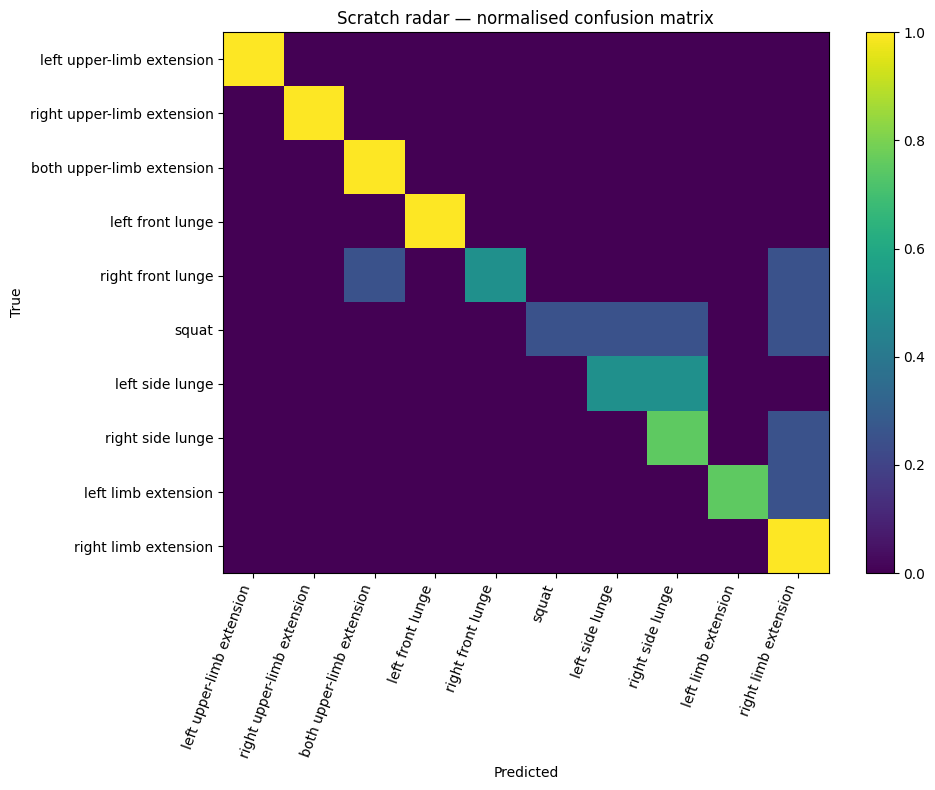


SSL radar
                            precision    recall  f1-score   support

 left upper-limb extension     1.0000    1.0000    1.0000         4
right upper-limb extension     1.0000    1.0000    1.0000         4
 both upper-limb extension     0.5714    1.0000    0.7273         4
          left front lunge     0.0000    0.0000    0.0000         4
         right front lunge     0.6667    0.5000    0.5714         4
                     squat     0.6667    0.5000    0.5714         4
           left side lunge     0.6667    0.5000    0.5714         4
          right side lunge     0.2000    0.2500    0.2222         4
       left limb extension     0.5714    1.0000    0.7273         4
      right limb extension     1.0000    1.0000    1.0000         4

                  accuracy                         0.6750        40
                 macro avg     0.6343    0.6750    0.6391        40
              weighted avg     0.6343    0.6750    0.6391        40



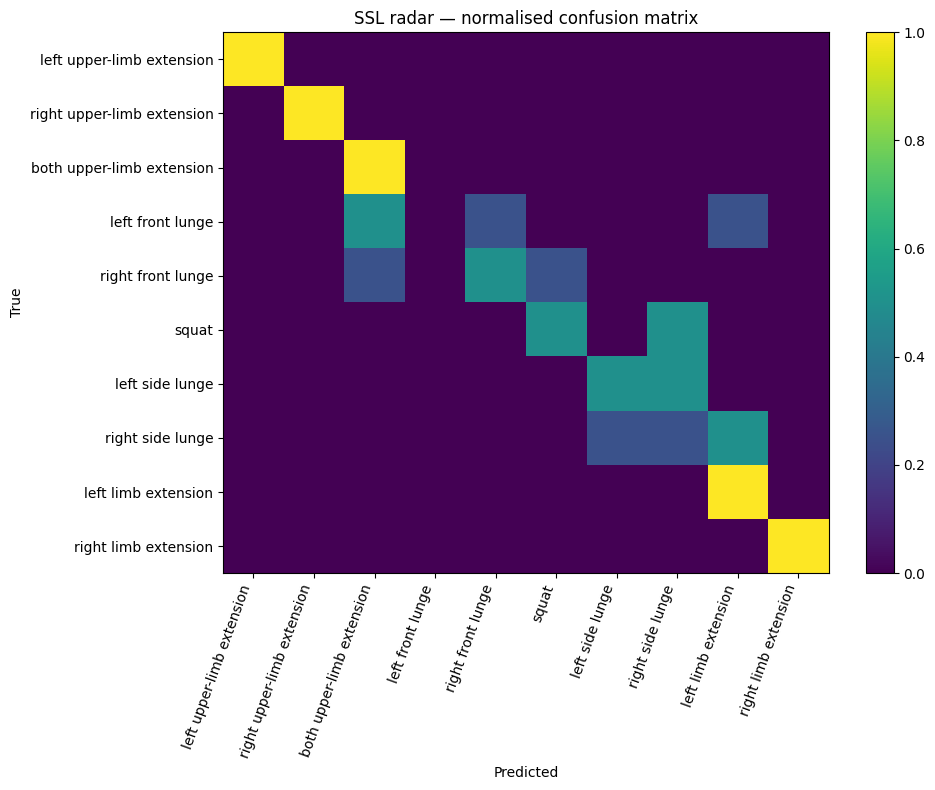


Reliability teacher
                            precision    recall  f1-score   support

 left upper-limb extension     1.0000    1.0000    1.0000         4
right upper-limb extension     1.0000    1.0000    1.0000         4
 both upper-limb extension     0.8000    1.0000    0.8889         4
          left front lunge     1.0000    0.7500    0.8571         4
         right front lunge     1.0000    0.7500    0.8571         4
                     squat     0.7500    0.7500    0.7500         4
           left side lunge     0.8000    1.0000    0.8889         4
          right side lunge     1.0000    1.0000    1.0000         4
       left limb extension     1.0000    1.0000    1.0000         4
      right limb extension     1.0000    1.0000    1.0000         4

                  accuracy                         0.9250        40
                 macro avg     0.9350    0.9250    0.9242        40
              weighted avg     0.9350    0.9250    0.9242        40



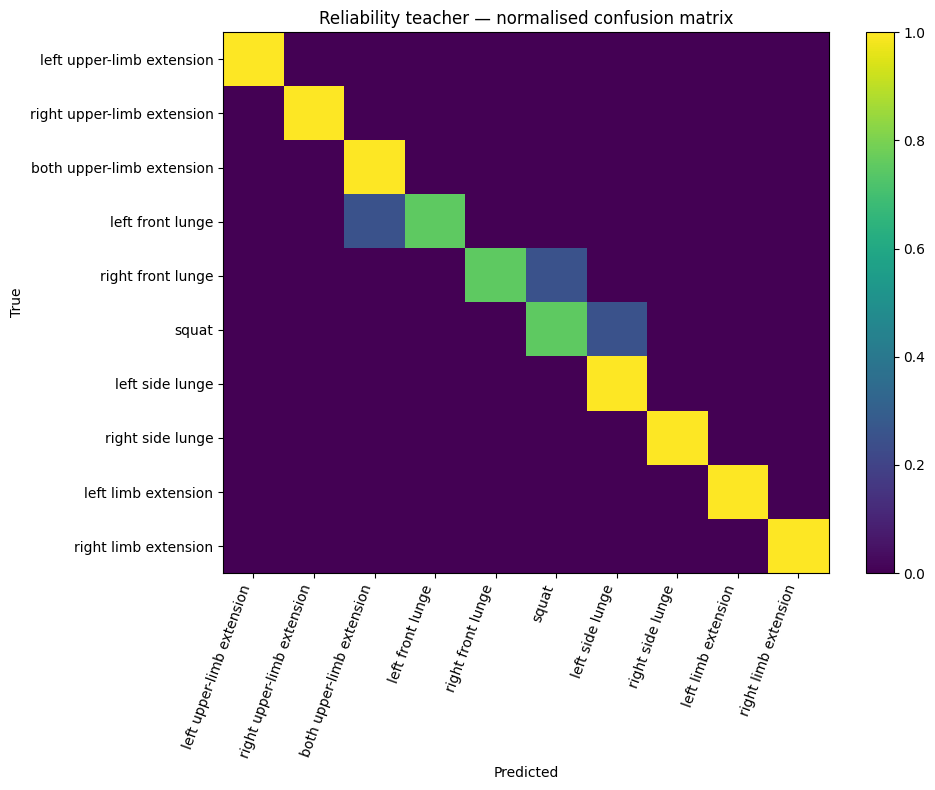


RTPD radar student
                            precision    recall  f1-score   support

 left upper-limb extension     1.0000    1.0000    1.0000         4
right upper-limb extension     1.0000    1.0000    1.0000         4
 both upper-limb extension     1.0000    1.0000    1.0000         4
          left front lunge     1.0000    0.7500    0.8571         4
         right front lunge     1.0000    0.5000    0.6667         4
                     squat     0.4286    0.7500    0.5455         4
           left side lunge     0.7500    0.7500    0.7500         4
          right side lunge     0.7500    0.7500    0.7500         4
       left limb extension     1.0000    1.0000    1.0000         4
      right limb extension     1.0000    1.0000    1.0000         4

                  accuracy                         0.8500        40
                 macro avg     0.8929    0.8500    0.8569        40
              weighted avg     0.8929    0.8500    0.8569        40



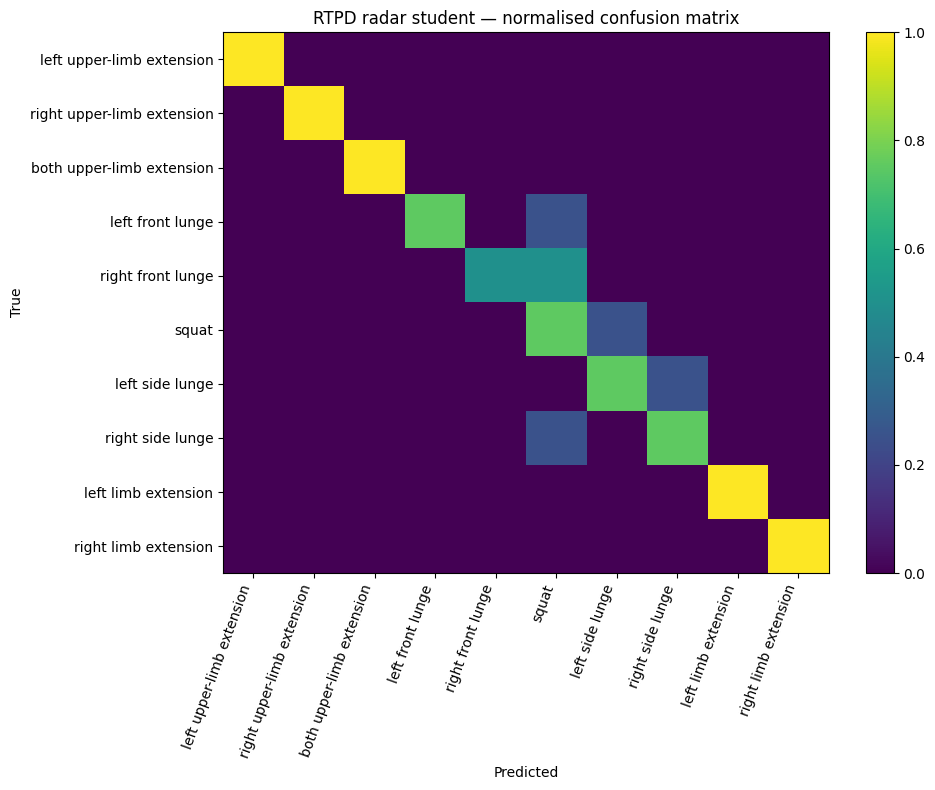


IMU only
                            precision    recall  f1-score   support

 left upper-limb extension     0.6667    1.0000    0.8000         4
right upper-limb extension     1.0000    1.0000    1.0000         4
 both upper-limb extension     1.0000    1.0000    1.0000         4
          left front lunge     0.8000    1.0000    0.8889         4
         right front lunge     0.8000    1.0000    0.8889         4
                     squat     1.0000    0.2500    0.4000         4
           left side lunge     0.7500    0.7500    0.7500         4
          right side lunge     1.0000    0.7500    0.8571         4
       left limb extension     1.0000    1.0000    1.0000         4
      right limb extension     1.0000    1.0000    1.0000         4

                  accuracy                         0.8750        40
                 macro avg     0.9017    0.8750    0.8585        40
              weighted avg     0.9017    0.8750    0.8585        40



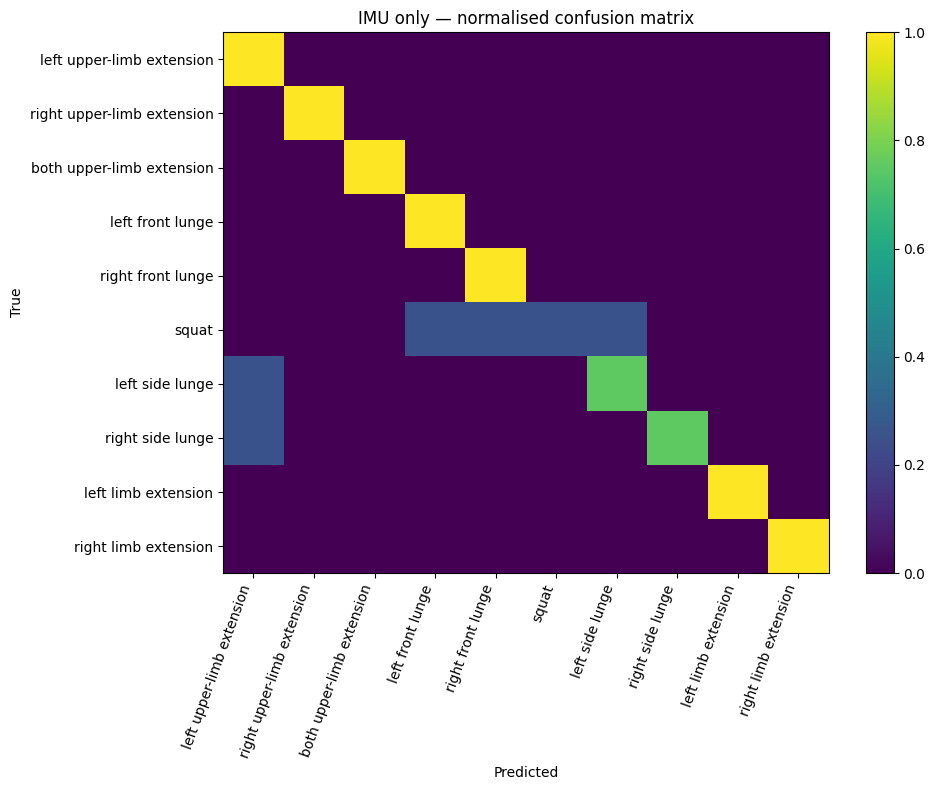


Late fusion
                            precision    recall  f1-score   support

 left upper-limb extension     0.8000    1.0000    0.8889         4
right upper-limb extension     1.0000    1.0000    1.0000         4
 both upper-limb extension     0.8000    1.0000    0.8889         4
          left front lunge     0.7500    0.7500    0.7500         4
         right front lunge     1.0000    1.0000    1.0000         4
                     squat     1.0000    0.2500    0.4000         4
           left side lunge     0.7500    0.7500    0.7500         4
          right side lunge     0.6000    0.7500    0.6667         4
       left limb extension     1.0000    1.0000    1.0000         4
      right limb extension     1.0000    1.0000    1.0000         4

                  accuracy                         0.8500        40
                 macro avg     0.8700    0.8500    0.8344        40
              weighted avg     0.8700    0.8500    0.8344        40



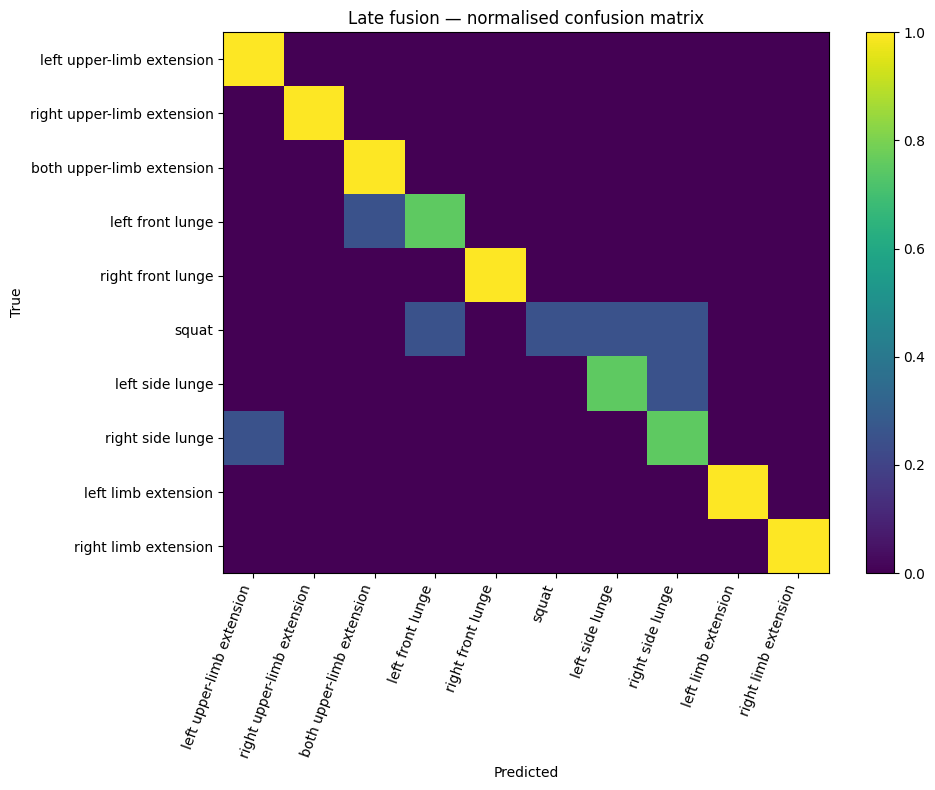

,radar_mean,radar_std,imu_mean,imu_std,count,class_name
class_id,,,,,,
0,0.419709,0.051784,0.580291,0.051784,4,left upper-limb extension
1,0.331293,0.016421,0.668707,0.016422,4,right upper-limb extension
2,0.322177,0.008153,0.677823,0.008153,4,both upper-limb extension
3,0.337514,0.010792,0.662486,0.010792,4,left front lunge
4,0.290278,0.016936,0.709722,0.016936,4,right front lunge
5,0.296351,0.006159,0.703649,0.006159,4,squat
6,0.293988,0.021046,0.706012,0.021046,4,left side lunge
7,0.295863,0.019850,0.704137,0.019850,4,right side lunge
8,0.281090,0.021481,0.718910,0.021481,4,left limb extension


In [31]:
# ============================================================
# Confusion matrices, class reports, and reliability diagnostics
# ============================================================

def safe_file_name(text):
    return re.sub(r"[^a-z0-9]+", "_", text.lower()).strip("_")


def prediction_frame(name, prediction, probability):
    output = pd.DataFrame({
        "sample_id": prediction["sample_ids"],
        "subject": prediction["subjects"],
        "true_id": prediction["y_true"],
        "pred_id": probability.argmax(axis=1),
        "true_label": [CLASS_NAMES[index] for index in prediction["y_true"]],
        "pred_label": [
            CLASS_NAMES[index] for index in probability.argmax(axis=1)
        ],
        "confidence": probability.max(axis=1),
    })
    for class_id, class_name in enumerate(CLASS_NAMES):
        output[
            f"prob_{class_id:02d}_{safe_file_name(class_name)}"
        ] = probability[:, class_id]
    output.to_csv(
        Path(cfg.WORK_DIR) / f"predictions_{safe_file_name(name)}.csv",
        index=False,
    )
    return output


def plot_confusion_matrix(name, prediction, probability):
    predicted = probability.argmax(axis=1)
    matrix = confusion_matrix(
        prediction["y_true"],
        predicted,
        labels=list(range(NUM_CLASSES)),
        normalize="true",
    )
    figure, axis = plt.subplots(figsize=(10, 8))
    image = axis.imshow(matrix, aspect="auto", vmin=0.0, vmax=1.0)
    axis.set_title(f"{name} — normalised confusion matrix")
    axis.set_xlabel("Predicted")
    axis.set_ylabel("True")
    axis.set_xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=70, ha="right")
    axis.set_yticks(range(NUM_CLASSES), CLASS_NAMES)
    figure.colorbar(image, ax=axis)
    figure.tight_layout()
    figure.savefig(
        Path(cfg.WORK_DIR) / f"confusion_{safe_file_name(name)}.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()


for model_name, prediction in test_predictions.items():
    probability = calibrated_test_probabilities[model_name]
    print("\n" + "=" * 90)
    print(model_name)
    print(
        classification_report(
            prediction["y_true"],
            probability.argmax(axis=1),
            labels=list(range(NUM_CLASSES)),
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0,
        )
    )
    prediction_frame(model_name, prediction, probability)
    plot_confusion_matrix(model_name, prediction, probability)


teacher_reliability = teacher_test_prediction["reliability"]
reliability_summary = pd.DataFrame({
    "sample_id": teacher_test_prediction["sample_ids"],
    "subject": teacher_test_prediction["subjects"],
    "class_id": teacher_test_prediction["y_true"],
    "radar_reliability": teacher_reliability[..., 0].mean(axis=1),
    "imu_reliability": teacher_reliability[..., 1].mean(axis=1),
    "radar_reliability_std": teacher_reliability[..., 0].std(axis=1),
})

reliability_by_class = (
    reliability_summary
    .groupby("class_id")
    .agg(
        radar_mean=("radar_reliability", "mean"),
        radar_std=("radar_reliability", "std"),
        imu_mean=("imu_reliability", "mean"),
        imu_std=("imu_reliability", "std"),
        count=("class_id", "size"),
    )
)
reliability_by_class["class_name"] = [
    CLASS_NAMES[index] for index in reliability_by_class.index
]
display(reliability_by_class)
reliability_by_class.to_csv(
    Path(cfg.WORK_DIR) / "teacher_reliability_by_class.csv"
)

## Robustness experiments

The teacher is evaluated under missing or noisy IMU, while the deployment student is evaluated under radar degradation. A reliable method should:

- reduce teacher dependence on damaged IMU through its reliability estimator;
- keep the radar-only student competitive under moderate radar corruption;
- show graceful degradation rather than abrupt failure.

,accuracy,balanced_accuracy,macro_f1,weighted_f1,radar_reliability,imu_reliability
condition,,,,,,
clean,0.9250,0.9250,0.9242,0.9242,0.3158,0.6842
imu_frame_mask,0.9250,0.9250,0.9242,0.9242,0.3219,0.6781
imu_sensor_mask,0.8000,0.8000,0.7973,0.7973,0.3126,0.6874
imu_noise,0.9250,0.9250,0.9242,0.9242,0.3143,0.6857
radar_frame_mask,0.8750,0.8750,0.8699,0.8699,0.3161,0.6839
radar_spatial_mask,0.9250,0.9250,0.9242,0.9242,0.3156,0.6844
radar_channel_drop,0.9000,0.9000,0.9010,0.9010,0.3166,0.6834
radar_noise,0.9000,0.9000,0.8988,0.8988,0.3192,0.6808
both_mild,0.9250,0.9250,0.9242,0.9242,0.3149,0.6851


,accuracy,balanced_accuracy,macro_f1,weighted_f1
condition,,,,
clean,0.8500,0.8500,0.8569,0.8569
frame_mask_10,0.7750,0.7750,0.7825,0.7825
frame_mask_30,0.5500,0.5500,0.5228,0.5228
frame_mask_50,0.2500,0.2500,0.1702,0.1702
channel_drop,0.5750,0.5750,0.5089,0.5089
gaussian_025,0.6000,0.6000,0.6038,0.6038
gaussian_050,0.4250,0.4250,0.4021,0.4021
spatial_mask,0.6250,0.6250,0.5371,0.5371


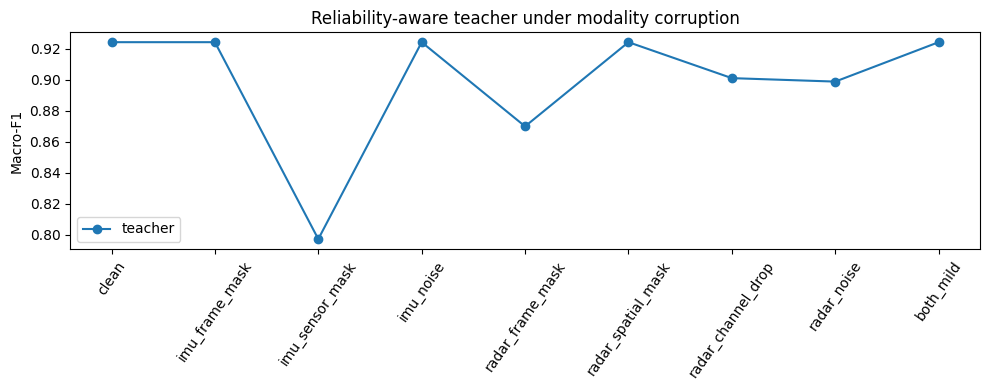

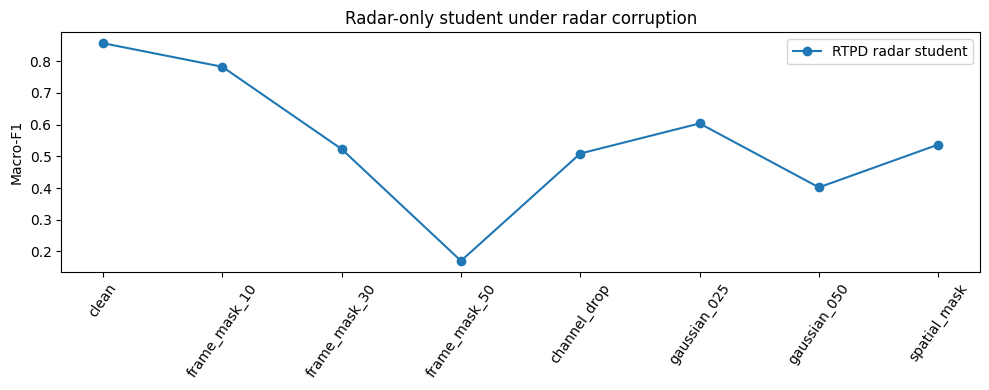

In [32]:
# ============================================================
# Teacher and student robustness
# ============================================================

teacher_robustness_df = pd.DataFrame()
student_robustness_df = pd.DataFrame()

if cfg.RUN_ROBUSTNESS:
    teacher_conditions = [
        "clean",
        "imu_frame_mask",
        "imu_sensor_mask",
        "imu_noise",
        "radar_frame_mask",
        "radar_spatial_mask",
        "radar_channel_drop",
        "radar_noise",
        "both_mild",
    ]

    teacher_rows = []
    for condition in teacher_conditions:
        prediction = predict_teacher_model(
            teacher_model,
            test_loader,
            corruption=condition,
        )
        row = {
            "condition": condition,
            **metric_dictionary(prediction["y_true"], prediction["y_pred"]),
            "radar_reliability": float(
                prediction["reliability"][..., 0].mean()
            ),
            "imu_reliability": float(
                prediction["reliability"][..., 1].mean()
            ),
        }
        teacher_rows.append(row)

    teacher_robustness_df = pd.DataFrame(teacher_rows).set_index("condition")
    display(teacher_robustness_df.style.format("{:.4f}"))
    teacher_robustness_df.to_csv(
        Path(cfg.WORK_DIR) / "teacher_modality_robustness.csv"
    )

    student_conditions = [
        "clean",
        "frame_mask_10",
        "frame_mask_30",
        "frame_mask_50",
        "channel_drop",
        "gaussian_025",
        "gaussian_050",
        "spatial_mask",
    ]

    student_rows = []
    for condition in student_conditions:
        prediction = predict_radar_model(
            student_model,
            test_loader,
            radar_corruption=condition,
        )
        student_rows.append({
            "condition": condition,
            **metric_dictionary(prediction["y_true"], prediction["y_pred"]),
        })

    student_robustness_df = pd.DataFrame(student_rows).set_index("condition")
    display(student_robustness_df.style.format("{:.4f}"))
    student_robustness_df.to_csv(
        Path(cfg.WORK_DIR) / "student_radar_robustness.csv"
    )

    figure, axis = plt.subplots(figsize=(10, 4))
    axis.plot(
        teacher_robustness_df.index,
        teacher_robustness_df["macro_f1"],
        marker="o",
        label="teacher",
    )
    axis.set_ylabel("Macro-F1")
    axis.set_title("Reliability-aware teacher under modality corruption")
    axis.tick_params(axis="x", rotation=55)
    axis.legend()
    figure.tight_layout()
    figure.savefig(
        Path(cfg.WORK_DIR) / "teacher_robustness.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

    figure, axis = plt.subplots(figsize=(10, 4))
    axis.plot(
        student_robustness_df.index,
        student_robustness_df["macro_f1"],
        marker="o",
        label="RTPD radar student",
    )
    axis.set_ylabel("Macro-F1")
    axis.set_title("Radar-only student under radar corruption")
    axis.tick_params(axis="x", rotation=55)
    axis.legend()
    figure.tight_layout()
    figure.savefig(
        Path(cfg.WORK_DIR) / "student_robustness.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("Robustness experiments skipped.")

## Optional ablation study

The ablation runner isolates the contribution of each student loss. It starts every variant from the same trained teacher radar encoder.

Recommended paper table:

1. hard labels only;
2. standard logit KD;
3. logit + temporal alignment;
4. logit + temporal + prototype;
5. logit + temporal + prototype + relation;
6. full method with subject-adversarial invariance.

In [35]:
# ============================================================
# Optional student ablations
# ============================================================

ablation_results_df = pd.DataFrame()

if cfg.RUN_ABLATIONS:
    ablation_configurations = [
        StudentLossConfiguration(
            False, False, False, False, False, "hard_labels_only"
        ),
        StudentLossConfiguration(
            True, False, False, False, False, "standard_logit_kd"
        ),
        StudentLossConfiguration(
            True, True, False, False, False, "logit_plus_temporal"
        ),
        StudentLossConfiguration(
            True, True, False, True, False, "plus_prototype"
        ),
        StudentLossConfiguration(
            True, True, True, True, False, "plus_relation"
        ),
        StudentLossConfiguration(
            True, True, True, True, True, "full_rt_pd"
        ),
    ]

    ablation_rows = []

    for configuration in ablation_configurations:
        print("\n" + "=" * 90)
        print("Ablation:", configuration.name)

        ablation_student = RadarOnlyModel(
            NUM_CLASSES,
            num_train_subjects=len(SUBJECT_TO_TRAIN_ID),
        ).to(DEVICE)
        ablation_student.encoder.load_state_dict(
            teacher_model.radar_encoder.state_dict(),
            strict=True,
        )

        history = train_distilled_student(
            ablation_student,
            teacher_model,
            teacher_prototypes,
            train_loader,
            val_loader,
            train_df,
            cfg.ABLATION_EPOCHS,
            configuration,
        )
        history.to_csv(
            Path(cfg.WORK_DIR)
            / f"ablation_history_{configuration.name}.csv",
            index=False,
        )

        prediction = predict_radar_model(ablation_student, test_loader)
        row = {
            "variant": configuration.name,
            **metric_dictionary(prediction["y_true"], prediction["y_pred"]),
        }
        ablation_rows.append(row)

        torch.save(
            ablation_student.state_dict(),
            Path(cfg.WORK_DIR) / f"ablation_{configuration.name}.pt",
        )

        del ablation_student
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    ablation_results_df = (
        pd.DataFrame(ablation_rows)
        .set_index("variant")
        .sort_values("macro_f1", ascending=False)
    )
    display(ablation_results_df.style.format("{:.4f}"))
    ablation_results_df.to_csv(
        Path(cfg.WORK_DIR) / "ablation_results.csv"
    )
else:
    print("Ablations disabled. Set cfg.RUN_ABLATIONS=True to run them.")


Ablation: hard_labels_only
hard_labels_only 01/12 | loss=2.1663 | hard=2.1663 | kd=0.0000 | temporal=0.0000 | prototype=0.0000 | confidence=0.840 | val_macro_f1=0.3341
hard_labels_only 02/12 | loss=1.5434 | hard=1.5434 | kd=0.0000 | temporal=0.0000 | prototype=0.0000 | confidence=0.840 | val_macro_f1=0.5877
hard_labels_only 03/12 | loss=1.2902 | hard=1.2902 | kd=0.0000 | temporal=0.0000 | prototype=0.0000 | confidence=0.840 | val_macro_f1=0.5442
hard_labels_only 04/12 | loss=1.1782 | hard=1.1782 | kd=0.0000 | temporal=0.0000 | prototype=0.0000 | confidence=0.840 | val_macro_f1=0.5438
hard_labels_only 05/12 | loss=1.0462 | hard=1.0462 | kd=0.0000 | temporal=0.0000 | prototype=0.0000 | confidence=0.840 | val_macro_f1=0.5704
hard_labels_only 06/12 | loss=0.9767 | hard=0.9767 | kd=0.0000 | temporal=0.0000 | prototype=0.0000 | confidence=0.840 | val_macro_f1=0.5621
hard_labels_only 07/12 | loss=0.9416 | hard=0.9416 | kd=0.0000 | temporal=0.0000 | prototype=0.0000 | confidence=0.840 | val_m

,accuracy,balanced_accuracy,macro_f1,weighted_f1
variant,,,,
standard_logit_kd,0.7750,0.7750,0.7825,0.7825
full_rt_pd,0.7500,0.7500,0.7394,0.7394
logit_plus_temporal,0.7000,0.7000,0.6921,0.6921
plus_relation,0.7000,0.7000,0.6749,0.6749
plus_prototype,0.6750,0.6750,0.6535,0.6535
hard_labels_only,0.6250,0.6250,0.5783,0.5783


## Optional five-fold subject evaluation

For 20 subjects, the notebook forms five groups of four subjects. In each fold:

- one group is held out for testing;
- the next group is used for validation;
- the remaining three groups are used for training.

Normalisation statistics are recomputed using only the training subjects. This section is intentionally optional because it retrains all models several times.

In [38]:
# ============================================================
# Loader builder and optional five-fold grouped evaluation
# ============================================================

def build_loaders_for_subject_split(
    train_subject_list,
    validation_subject_list,
    test_subject_list,
):
    split_stats = compute_training_stats(train_subject_list)

    local_train = manifest[
        manifest["subject"].isin(train_subject_list)
    ].reset_index(drop=True)
    local_validation = manifest[
        manifest["subject"].isin(validation_subject_list)
    ].reset_index(drop=True)
    local_test = manifest[
        manifest["subject"].isin(test_subject_list)
    ].reset_index(drop=True)

    datasets = {
        "train": MRISegmentDataset(
            local_train,
            split_stats,
            cfg.SEQ_LEN,
            cfg.CACHE_SUBJECTS_PER_WORKER,
        ),
        "validation": MRISegmentDataset(
            local_validation,
            split_stats,
            cfg.SEQ_LEN,
            cfg.CACHE_SUBJECTS_PER_WORKER,
        ),
        "test": MRISegmentDataset(
            local_test,
            split_stats,
            cfg.SEQ_LEN,
            cfg.CACHE_SUBJECTS_PER_WORKER,
        ),
    }

    loader_arguments = dict(
        batch_size=cfg.BATCH_SIZE,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        persistent_workers=cfg.NUM_WORKERS > 0,
    )

    loaders = {
        "train": DataLoader(
            datasets["train"],
            shuffle=True,
            drop_last=False,
            **loader_arguments,
        ),
        "validation": DataLoader(
            datasets["validation"],
            shuffle=False,
            **loader_arguments,
        ),
        "test": DataLoader(
            datasets["test"],
            shuffle=False,
            **loader_arguments,
        ),
    }

    return (
        local_train,
        local_validation,
        local_test,
        loaders,
        split_stats,
    )


def grouped_subject_partitions(subjects, folds, seed):
    subjects = np.asarray(sorted(subjects))
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(subjects)
    return [np.asarray(group) for group in np.array_split(shuffled, folds)]


grouped_cv_results_df = pd.DataFrame()

if cfg.RUN_GROUPED_CV:
    groups = grouped_subject_partitions(
        manifest["subject"].unique(),
        cfg.CV_FOLDS,
        cfg.SEED,
    )
    cv_rows = []

    for fold_index in range(cfg.CV_FOLDS):
        print("\n" + "#" * 100)
        print(f"GROUPED FOLD {fold_index + 1}/{cfg.CV_FOLDS}")

        fold_test_subjects = groups[fold_index]
        fold_validation_subjects = groups[(fold_index + 1) % cfg.CV_FOLDS]
        fold_train_subjects = np.concatenate(
            [
                groups[index]
                for index in range(cfg.CV_FOLDS)
                if index not in {
                    fold_index,
                    (fold_index + 1) % cfg.CV_FOLDS,
                }
            ]
        )

        (
            fold_train_df,
            fold_validation_df,
            fold_test_df,
            fold_loaders,
            fold_stats,
        ) = build_loaders_for_subject_split(
            fold_train_subjects,
            fold_validation_subjects,
            fold_test_subjects,
        )

        # Fold-specific subject mapping used by the adversarial head.
        original_subject_mapping = dict(SUBJECT_TO_TRAIN_ID)
        SUBJECT_TO_TRAIN_ID.clear()
        SUBJECT_TO_TRAIN_ID.update({
            subject: index
            for index, subject in enumerate(sorted(fold_train_subjects.tolist()))
        })

        fold_ssl_model = None
        if cfg.CV_USE_SSL:
            fold_ssl_model = RadarSSLModel().to(DEVICE)
            pretrain_radar_ssl(
                fold_ssl_model,
                fold_loaders["train"],
                cfg.CV_SSL_EPOCHS,
            )

        fold_baseline = RadarOnlyModel(NUM_CLASSES).to(DEVICE)
        if fold_ssl_model is not None:
            fold_baseline.encoder.load_state_dict(
                fold_ssl_model.encoder.state_dict(),
                strict=True,
            )
        train_radar_supervised(
            fold_baseline,
            fold_loaders["train"],
            fold_loaders["validation"],
            fold_train_df,
            cfg.CV_EPOCHS,
            f"fold_{fold_index + 1}_baseline",
        )

        fold_teacher = ReliabilityAwareTeacher(NUM_CLASSES).to(DEVICE)
        if fold_ssl_model is not None:
            fold_teacher.radar_encoder.load_state_dict(
                fold_ssl_model.encoder.state_dict(),
                strict=True,
            )
        train_reliability_teacher(
            fold_teacher,
            fold_loaders["train"],
            fold_loaders["validation"],
            fold_train_df,
            cfg.CV_EPOCHS,
        )

        fold_prototypes = compute_teacher_prototypes(
            fold_teacher,
            fold_loaders["train"],
            NUM_CLASSES,
        )

        fold_student = RadarOnlyModel(
            NUM_CLASSES,
            num_train_subjects=len(SUBJECT_TO_TRAIN_ID),
        ).to(DEVICE)
        fold_student.encoder.load_state_dict(
            fold_teacher.radar_encoder.state_dict(),
            strict=True,
        )
        train_distilled_student(
            fold_student,
            fold_teacher,
            fold_prototypes,
            fold_loaders["train"],
            fold_loaders["validation"],
            fold_train_df,
            cfg.CV_EPOCHS,
            full_loss_configuration,
        )

        for model_name, model_object, prediction_function in [
            ("baseline", fold_baseline, predict_radar_model),
            ("teacher", fold_teacher, predict_teacher_model),
            ("student", fold_student, predict_radar_model),
        ]:
            prediction = prediction_function(
                model_object,
                fold_loaders["test"],
            )
            cv_rows.append({
                "fold": fold_index + 1,
                "model": model_name,
                **metric_dictionary(
                    prediction["y_true"],
                    prediction["y_pred"],
                ),
                "train_subjects": "|".join(sorted(fold_train_subjects.tolist())),
                "validation_subjects": "|".join(
                    sorted(fold_validation_subjects.tolist())
                ),
                "test_subjects": "|".join(sorted(fold_test_subjects.tolist())),
            })

        SUBJECT_TO_TRAIN_ID.clear()
        SUBJECT_TO_TRAIN_ID.update(original_subject_mapping)

        del fold_baseline, fold_teacher, fold_student, fold_prototypes
        if fold_ssl_model is not None:
            del fold_ssl_model
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    grouped_cv_results_df = pd.DataFrame(cv_rows)
    display(grouped_cv_results_df)

    grouped_cv_summary = (
        grouped_cv_results_df
        .groupby("model")[["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]]
        .agg(["mean", "std"])
    )
    display(grouped_cv_summary)

    grouped_cv_results_df.to_csv(
        Path(cfg.WORK_DIR) / "grouped_cv_fold_results.csv",
        index=False,
    )
    grouped_cv_summary.to_csv(
        Path(cfg.WORK_DIR) / "grouped_cv_summary.csv"
    )
else:
    print("Grouped CV disabled. Set cfg.RUN_GROUPED_CV=True for paper-grade repetition.")


####################################################################################################
GROUPED FOLD 1/5
SSL 01/4 | loss=1.2400 | recon=0.1503 | contrast=3.1135
SSL 02/4 | loss=0.9795 | recon=0.1186 | contrast=2.4598
SSL 03/4 | loss=0.7282 | recon=0.1006 | contrast=1.7931
SSL 04/4 | loss=0.6477 | recon=0.0929 | contrast=1.5849
fold_1_baseline 01/8 | loss=2.1572 | val_macro_f1=0.3271
fold_1_baseline 02/8 | loss=1.5963 | val_macro_f1=0.3512
fold_1_baseline 03/8 | loss=1.4232 | val_macro_f1=0.4548
fold_1_baseline 04/8 | loss=1.3291 | val_macro_f1=0.5653
fold_1_baseline 05/8 | loss=1.1812 | val_macro_f1=0.5489
fold_1_baseline 06/8 | loss=1.0538 | val_macro_f1=0.4943
fold_1_baseline 07/8 | loss=0.9301 | val_macro_f1=0.5646
fold_1_baseline 08/8 | loss=0.8280 | val_macro_f1=0.5939
teacher 01/8 | loss=2.6333 | rel=0.0176 | val_macro_f1=0.1229
teacher 02/8 | loss=2.0062 | rel=0.0178 | val_macro_f1=0.0500
teacher 03/8 | loss=1.2887 | rel=0.0536 | val_macro_f1=0.2148
teacher 04/8 | 

,fold,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,train_subjects,validation_subjects,test_subjects
0,1,baseline,0.675,0.675,0.665281,0.665281,subject03|subject04|subject05|subject06|subjec...,subject02|subject07|subject14|subject16,subject01|subject10|subject15|subject19
1,1,teacher,0.950,0.950,0.946667,0.946667,subject03|subject04|subject05|subject06|subjec...,subject02|subject07|subject14|subject16,subject01|subject10|subject15|subject19
2,1,student,0.550,0.550,0.507582,0.507582,subject03|subject04|subject05|subject06|subjec...,subject02|subject07|subject14|subject16,subject01|subject10|subject15|subject19
3,2,baseline,0.675,0.675,0.620794,0.620794,subject01|subject04|subject05|subject06|subjec...,subject03|subject09|subject12|subject13,subject02|subject07|subject14|subject16
4,2,teacher,0.875,0.875,0.870476,0.870476,subject01|subject04|subject05|subject06|subjec...,subject03|subject09|subject12|subject13,subject02|subject07|subject14|subject16
5,2,student,0.650,0.650,0.627294,0.627294,subject01|subject04|subject05|subject06|subjec...,subject03|subject09|subject12|subject13,subject02|subject07|subject14|subject16
6,3,baseline,0.475,0.475,0.410850,0.410850,subject01|subject02|subject05|subject07|subjec...,subject04|subject06|subject17|subject18,subject03|subject09|subject12|subject13
7,3,teacher,0.950,0.950,0.946667,0.946667,subject01|subject02|subject05|subject07|subjec...,subject04|subject06|subject17|subject18,subject03|subject09|subject12|subject13
8,3,student,0.625,0.625,0.583492,0.583492,subject01|subject02|subject05|subject07|subjec...,subject04|subject06|subject17|subject18,subject03|subject09|subject12|subject13
9,4,baseline,0.500,0.500,0.460173,0.460173,subject01|subject02|subject03|subject07|subjec...,subject05|subject08|subject11|subject20,subject04|subject06|subject17|subject18


accuracy           balanced_accuracy            macro_f1            \
             mean       std              mean       std      mean       std   
model                                                                         
baseline    0.605  0.108109             0.605  0.108109  0.564076  0.119975   
student     0.625  0.043301             0.625  0.043301  0.595473  0.053425   
teacher     0.890  0.057554             0.890  0.057554  0.885276  0.058400   

         weighted_f1            
                mean       std  
model                           
baseline    0.564076  0.119975  
student     0.595473  0.053425  
teacher     0.885276  0.058400

In [39]:
# ============================================================
# Save experiment summary and archive
# ============================================================

summary = {
    "method": "Reliability-Aware Temporal Prototype Distillation (RTPD-Net)",
    "configuration": asdict(cfg),
    "data_root": str(DATA_ROOT),
    "num_subjects": int(manifest["subject"].nunique()),
    "num_segments": int(len(manifest)),
    "train_subjects": sorted(train_subjects.tolist()),
    "validation_subjects": sorted(val_subjects.tolist()),
    "test_subjects": sorted(test_subjects.tolist()),
    "class_names": CLASS_NAMES,
    "temperatures": temperatures,
    "main_results": results_df.reset_index().to_dict("records"),
    "bootstrap": bootstrap_df.to_dict("records"),
    "ablation_enabled": cfg.RUN_ABLATIONS,
    "strong_baselines_enabled": cfg.RUN_STRONG_BASELINES,
    "grouped_cv_enabled": cfg.RUN_GROUPED_CV,
}

with open(
    Path(cfg.WORK_DIR) / "experiment_summary.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(summary, handle, indent=2)

archive_path = shutil.make_archive(
    str(Path("/kaggle/working") / "rtpdnet_mri_outputs"),
    "zip",
    cfg.WORK_DIR,
)

print("Output directory:", cfg.WORK_DIR)
print("Output archive:", archive_path)
display(results_df.style.format("{:.4f}"))

Output directory: /kaggle/working/rtpdnet_mri
Output archive: /kaggle/working/rtpdnet_mri_outputs.zip


,accuracy,balanced_accuracy,macro_f1,weighted_f1,nll,brier,ece,temperature
model,,,,,,,,
Reliability teacher,0.9250,0.9250,0.9242,0.9242,0.2585,0.1168,0.0612,0.7979
IMU only,0.8750,0.8750,0.8585,0.8585,0.3212,0.1728,0.0843,0.4956
RTPD radar student,0.8500,0.8500,0.8569,0.8569,0.7041,0.2905,0.1489,0.8351
Late fusion,0.8500,0.8500,0.8344,0.8344,0.3082,0.1614,0.0953,0.2167
Scratch radar,0.7750,0.7750,0.7651,0.7651,0.9522,0.4111,0.1336,1.1053
SSL radar,0.6750,0.6750,0.6391,0.6391,0.9579,0.4278,0.1357,0.9333


# Interpretation guide

The proposed methodology is supported when:

1. the reliability teacher outperforms the scratch and SSL radar baselines;
2. the RTPD radar student outperforms both radar baselines;
3. the bootstrap interval for the student’s macro-F1 improvement is mainly above zero;
4. teacher modality weights change in the correct direction under synthetic corruption;
5. the student degrades gradually under radar corruption;
6. calibration improves after validation-based temperature scaling;
7. ablations show that temporal, prototype, relation, and subject-invariant losses provide complementary gains;
8. grouped subject folds show consistent mean improvement rather than a result driven by one split.

Because the dataset contains only 20 subjects, report the method as an exercise-recognition feasibility study rather than a clinical diagnostic system. Exact timestamp alignment, external validation, and more rehabilitation participants remain necessary for a clinical claim.